# AAVE V3 Carry Trade Sustainability Analysis

## Strategy description
- **Deposit**: USDC (earn supply APR)
- **Borrow**: WETH (pay borrow APR)
- **Goal**: Analyze liquidation probability and PnL 

## Modeling Approach
1. **CIR Model**: Cox-Ingersoll-Ross for interest rate dynamics
2. **CIR + Jumps**: CIR with Poisson-Exponential jumps for rate spikes,
     Exp cut off at 65% (based on historical max)
3. **Price Dynamics**: Historical WETH/USDC from provided data (not available in this repo)
4. **Monte Carlo**: 10,000 simulation paths for forward projections

## Quick note on the way APR is determined

For $U <= U \sf optimal$ (Gental Slope):
$$ BorrowRate = BaseRate + (\frac{Utilization} {U \sf optimal})* Slope 1 $$
For $U > U {\sf optimal}$ (Steep Slope)
$$ BorrowRate = BaseRate + Slope 1 + (\frac{(Utilization — U{\sf optimal}}{1- U \sf{optimal}} ) * Slope 2 $$

The supply rate is derived from the borrow rate using this formula:
$$ SupplyRate = {BorrowRate} * {Utilization} * (1 — ReserveFactor) $$
Reserve Factor: % of interest that goes to the protocol treasury

#### Idei - selectie monede - vezi cum se pot cu Francis
#### Momentum, trend following - vezi Sepp
#### WF Validation
####  vezi cum sa modelezi APR
#### benchmark pure supply
#### date 

---
## 1. Setup and Configuration

In [249]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.optimize import minimize, differential_evolution
from scipy.special import iv  # Modified Bessel function for CIR MLE
from dataclasses import dataclass
from typing import Tuple, Optional, Dict, List
import warnings
warnings.filterwarnings('ignore')

# Plotting configuration - clean style transparent background
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.facecolor'] = 'none'
plt.rcParams['figure.facecolor'] = 'none'
plt.rcParams['savefig.facecolor'] = 'none'
plt.rcParams['axes.grid'] = False

np.random.seed(42)

In [250]:
@dataclass
class StrategyConfig:
    """Configuration for the AAVE V3 carry trade strategy."""
    initial_collateral_usdc: float = 100_000  # Initial USDC deposit
    ltv_ratio: float = 0.50  # Conservative LTV
    liquidation_threshold: float = 0.825  # AAVE V3 USDC liquidation threshold
    liquidation_penalty: float = 0.05  
    n_simulations: int = 10_000  # MC paths
    dt: float = 1/365  # Daily time steps (yrs)
    
config = StrategyConfig()
print(f"Strategy Configuration:")
print(f"  Initial Collateral: ${config.initial_collateral_usdc:,.0f} USDC")
print(f"  LTV Ratio: {config.ltv_ratio:.0%}")
print(f"  Liquidation Threshold: {config.liquidation_threshold:.1%}")
print(f"  Simulations: {config.n_simulations:,}")

Strategy Configuration:
  Initial Collateral: $100,000 USDC
  LTV Ratio: 50%
  Liquidation Threshold: 82.5%
  Simulations: 10,000


---
## 2. Data Loading

**Expected CSV format:**
- `timestamp`: Unix timestamp or datetime
- `usdc_supply_rate`: USDC supply APY (as decimal, e.g., 0.05 for 5%)
- `weth_borrow_rate`: WETH borrow APY (as decimal)
- `weth_price`: WETH/USDC price

In [251]:
# ===== LOAD AAVE V3 DATA =====
# Load USDC (supply) and WETH (borrow) data from AAVE V3
# Keep original AAVE timestamps unchanged; add WETH/USDC price from raw ETH/USD and USDC/USD CSVs

DATA_DIR = "../data/OLD_AAVE/"
RAW_DIR = "../data/raw/"
USDC_FILE = DATA_DIR + "aave_v3_usdc_eth.parquet"
WETH_FILE = DATA_DIR + "aave_v3_weth_eth.parquet"
ETH_USD_FILE = RAW_DIR + "eth-usd-max.csv"
USDC_USD_FILE = RAW_DIR + "usdc-usd-max.csv"

try:
    # Load AAVE rate datasets
    df_usdc = pd.read_parquet(USDC_FILE)
    df_weth = pd.read_parquet(WETH_FILE)
    print(f"Loaded USDC data: {len(df_usdc):,} rows from {USDC_FILE}")
    print(f"Loaded WETH data: {len(df_weth):,} rows from {WETH_FILE}")
    print(f"\nUSDC columns: {list(df_usdc.columns)}")
    print(f"WETH columns: {list(df_weth.columns)}")

    # Use native parquet timestamp column when available (do NOT rewrite timestamp values)
    if 'timestamp' in df_usdc.columns:
        usdc_timestamp = df_usdc['timestamp']
    else:
        usdc_timestamp = df_usdc.iloc[:, 0]

    if 'timestamp' in df_weth.columns:
        weth_timestamp = df_weth['timestamp']
    else:
        weth_timestamp = df_weth.iloc[:, 0]

    # Merge rates on original timestamp
    df_raw = pd.merge(
        pd.DataFrame({
            'timestamp': usdc_timestamp,
            'usdc_supply_rate': df_usdc['lender_variable_apr']
        }),
        pd.DataFrame({
            'timestamp': weth_timestamp,
            'weth_borrow_rate': df_weth['borrower_variable_apr']
        }),
        on='timestamp',
        how='inner'
    )

    # Read only time+price columns from raw CSVs, then build WETH/USDC price
    df_eth_usd = pd.read_csv(ETH_USD_FILE, usecols=['snapped_at', 'price']).rename(columns={'price': 'eth_usd'})
    df_usdc_usd = pd.read_csv(USDC_USD_FILE, usecols=['snapped_at', 'price']).rename(columns={'price': 'usdc_usd'})

    df_eth_usd['date'] = pd.to_datetime(df_eth_usd['snapped_at'], utc=True, errors='coerce').dt.tz_localize(None).dt.floor('D')
    df_usdc_usd['date'] = pd.to_datetime(df_usdc_usd['snapped_at'], utc=True, errors='coerce').dt.tz_localize(None).dt.floor('D')

    price_daily = pd.merge(
        df_eth_usd[['date', 'eth_usd']],
        df_usdc_usd[['date', 'usdc_usd']],
        on='date',
        how='inner'
    ).dropna()

    price_daily = price_daily[price_daily['usdc_usd'] > 0].copy()
    price_daily['weth_price'] = price_daily['eth_usd'] / price_daily['usdc_usd']

    # Build a date key from timestamp for joining prices, without changing timestamp itself
    ts = df_raw['timestamp']
    if pd.api.types.is_numeric_dtype(ts):
        tmax = ts.dropna().max()
        if tmax > 1e14:
            ts_date = pd.to_datetime(ts, unit='ns', errors='coerce')
        elif tmax > 1e11:
            ts_date = pd.to_datetime(ts, unit='ms', errors='coerce')
        else:
            ts_date = pd.to_datetime(ts, unit='s', errors='coerce')
    else:
        ts_date = pd.to_datetime(ts, errors='coerce')

    df_raw['date'] = ts_date.dt.tz_localize(None).dt.floor('D')
    df_raw = df_raw.merge(
        price_daily[['date', 'weth_price']],
        on='date',
        how='left'
    ).drop(columns=['date'])

    missing_prices = df_raw['weth_price'].isna().sum()
    if missing_prices > 0:
        print(f"WARNING: {missing_prices:,} rows missing weth_price after merge")

    # Column mapping for downstream processing
    COLUMN_MAP = {
        'timestamp': 'timestamp',
        'usdc_supply_rate': 'usdc_supply_rate',
        'weth_borrow_rate': 'weth_borrow_rate',
        'weth_price': 'weth_price',
    }

    print(f"\nMerged dataset: {len(df_raw):,} rows")
    print(f"Date range: {df_raw['timestamp'].min()} to {df_raw['timestamp'].max()}")
    print(f"\nSample data:")
    print(df_raw.head())

except FileNotFoundError as e:
    print(f"ERROR: File not found - {e}")
    print("Please ensure the parquet files in data/OLD_AAVE and raw CSV files in data/raw exist.")
    df_raw = None

Loaded USDC data: 29,327 rows from ../data/OLD_AAVE/aave_v3_usdc_eth.parquet
Loaded WETH data: 29,327 rows from ../data/OLD_AAVE/aave_v3_weth_eth.parquet

USDC columns: ['timestamp', 'block', 'TVL_USD', 'supplied_USD', 'borrowed_USD', 'liquidations', 'token_balance', 'lender_variable_apr', 'lender_stable_apr', 'borrower_variable_apr', 'borrower_stable_apr']
WETH columns: ['timestamp', 'block', 'TVL_USD', 'supplied_USD', 'borrowed_USD', 'liquidations', 'token_balance', 'lender_variable_apr', 'lender_stable_apr', 'borrower_variable_apr', 'borrower_stable_apr']

Merged dataset: 3,036 rows
Date range: 1674812903.0 to 1780246775.0

Sample data:
      timestamp  usdc_supply_rate  weth_borrow_rate  weth_price
0  1.674813e+09          0.008496          1.672405  1601.46933
1  1.674817e+09          0.000796          1.079035  1601.46933
2  1.674867e+09          2.691088          3.267189  1596.85563
3  1.674892e+09          2.522239          3.282319  1596.85563
4  1.674907e+09          2.77118

In [252]:
def preprocess_data(df: pd.DataFrame, col_map: dict) -> pd.DataFrame:
    """Preprocess raw data into standardized format."""
    df = df.copy()
    
    # Rename columns to standard names
    rename_map = {v: k for k, v in col_map.items() if v in df.columns}
    df = df.rename(columns=rename_map)
    
    # Parse timestamp
    if 'timestamp' in df.columns:
        # Try multiple timestamp formats
        if df['timestamp'].dtype in ['int64', 'float64']:
            # Unix timestamp (seconds or milliseconds)
            if df['timestamp'].iloc[0] > 1e12:
                df['timestamp'] = pd.to_datetime(df['timestamp'], unit='ms')
            else:
                df['timestamp'] = pd.to_datetime(df['timestamp'], unit='s')
        else:
            df['timestamp'] = pd.to_datetime(df['timestamp'])
    
    df = df.set_index('timestamp').sort_index()

    # If data is intraday (e.g., hourly), aggregate to daily frequency
    if isinstance(df.index, pd.DatetimeIndex) and len(df.index) > 1:
        median_step = df.index.to_series().diff().dropna().median()
        if pd.notna(median_step) and median_step < pd.Timedelta(days=1):
            print(f"Detected intraday rate data (median step: {median_step}). Resampling to daily.")
            df = df.resample('D').mean()
    
    # Ensure rates are in decimal form (not percentage)
    for col in ['usdc_supply_rate', 'weth_borrow_rate']:
        if col in df.columns and df[col].mean() > 1:
            print(f"Converting {col} from percentage to decimal")
            df[col] = df[col] / 100
    
    # Calculate spread
    df['rate_spread'] = df['usdc_supply_rate'] - df['weth_borrow_rate']
    
    # Calculate daily returns for WETH price
    df['weth_return'] = df['weth_price'].pct_change()
    
    return df.dropna()

# Process data if loaded
if df_raw is not None:
    df = preprocess_data(df_raw, COLUMN_MAP)
    print(f"\nProcessed data shape: {df.shape}")
    print(f"Date range: {df.index.min()} to {df.index.max()}")
    print(f"Duration: {(df.index.max() - df.index.min()).days} days")
else:
    df = None

Detected intraday rate data (median step: 0 days 05:43:36). Resampling to daily.
Converting usdc_supply_rate from percentage to decimal
Converting weth_borrow_rate from percentage to decimal

Processed data shape: (1023, 5)
Date range: 2023-01-28 00:00:00 to 2026-05-31 00:00:00
Duration: 1219 days


In [253]:
# summary statistics
if df is not None:
    print("=" * 60)
    print("SUMMARY STATISTICS")
    print("=" * 60)
    
    stats_df = df[['usdc_supply_rate', 'weth_borrow_rate', 'rate_spread', 'weth_price']].describe()
    stats_df.loc['annualized_vol'] = df[['usdc_supply_rate', 'weth_borrow_rate', 'rate_spread']].std() * np.sqrt(365)
    
    print(stats_df.round(4))
    
    print(f"\n--- Key Insights ---")
    print(f"Average USDC Supply Rate: {df['usdc_supply_rate'].mean()*100:.2f}%")
    print(f"Average WETH Borrow Rate: {df['weth_borrow_rate'].mean()*100:.2f}%")
    print(f"Average Rate Spread: {df['rate_spread'].mean()*100:.2f}%")
    print(f"Spread > 0 (profitable): {(df['rate_spread'] > 0).mean()*100:.1f}% of time")
    print(f"WETH Price Range: ${df['weth_price'].min():,.0f} - ${df['weth_price'].max():,.0f}")

SUMMARY STATISTICS
                usdc_supply_rate  weth_borrow_rate  rate_spread  weth_price
count                  1023.0000         1023.0000    1023.0000   1023.0000
mean                      0.0485            0.0280       0.0204   2706.9030
std                       0.0312            0.0075       0.0327    798.8717
min                       0.0033            0.0183      -0.0678   1437.9944
25%                       0.0305            0.0243       0.0019   2019.4749
50%                       0.0398            0.0259       0.0147   2559.5251
75%                       0.0571            0.0284       0.0303   3296.9400
max                       0.4724            0.1039       0.4457   4830.6535
annualized_vol            0.5953            0.1442       0.6244         NaN

--- Key Insights ---
Average USDC Supply Rate: 4.85%
Average WETH Borrow Rate: 2.80%
Average Rate Spread: 2.04%
Spread > 0 (profitable): 76.7% of time
WETH Price Range: $1,438 - $4,831


In [254]:
df.tail()

,usdc_supply_rate,weth_borrow_rate,weth_price,rate_spread,weth_return
timestamp,,,,,
2026-05-27,0.037491,0.021384,2070.433324,0.016107,-0.019508
2026-05-28,0.047930,0.021289,2023.029210,0.026640,-0.022896
2026-05-29,0.032711,0.021348,2008.195418,0.011364,-0.007332
2026-05-30,0.032377,0.021196,2012.717823,0.011181,0.002252
2026-05-31,0.032769,0.021130,2019.913315,0.011639,0.003575


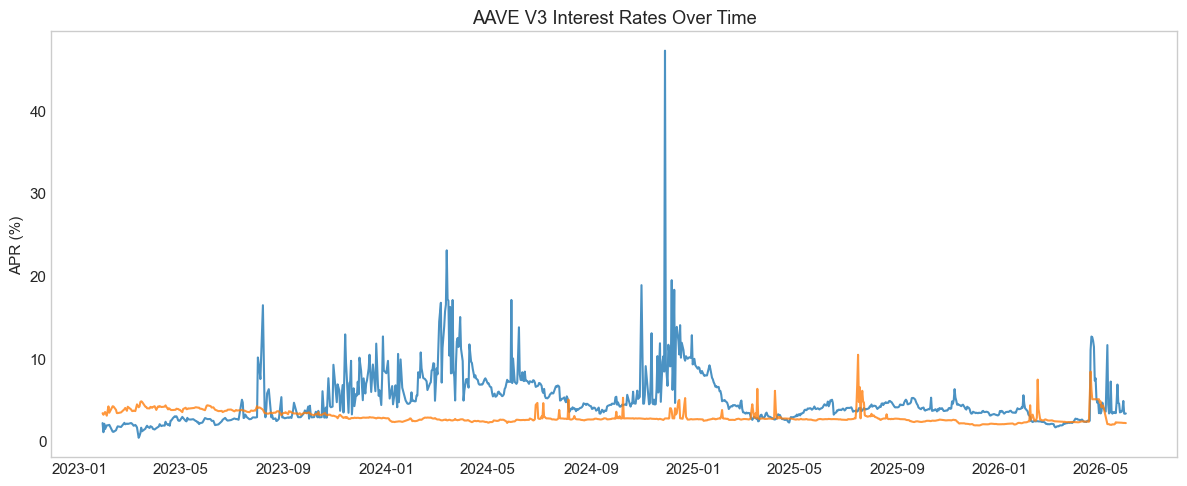

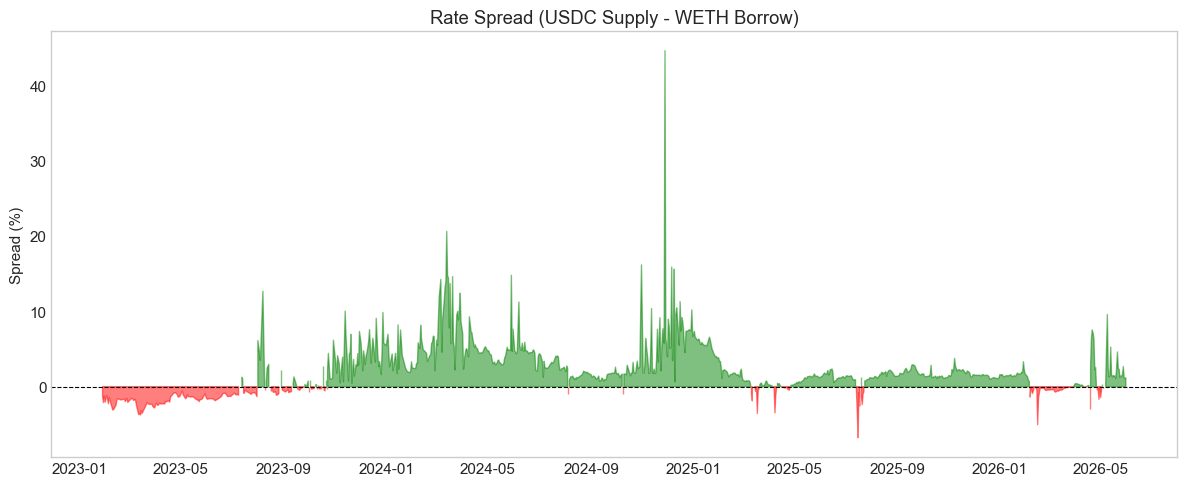

In [255]:
# Visualize historical data
if df is not None:
    # Plot 1: Interest Rates
    fig, ax = plt.subplots(figsize=(12, 5))
    fig.patch.set_alpha(0)
    ax.plot(df.index, df['usdc_supply_rate']*100, alpha=0.8)
    ax.plot(df.index, df['weth_borrow_rate']*100, alpha=0.8)
    ax.set_ylabel('APR (%)')
    ax.set_title('AAVE V3 Interest Rates Over Time')
    ax.legend()
    ax.set_facecolor('none')
    plt.tight_layout()
    plt.show()
    
    # Plot 2: Rate Spread
    fig, ax = plt.subplots(figsize=(12, 5))
    fig.patch.set_alpha(0)
    ax.fill_between(df.index, df['rate_spread']*100, 0, 
                     where=df['rate_spread'] >= 0, alpha=0.5, color='green')
    ax.fill_between(df.index, df['rate_spread']*100, 0,
                     where=df['rate_spread'] < 0, alpha=0.5, color='red')
    ax.axhline(0, color='black', linestyle='--', linewidth=0.8)
    ax.set_ylabel('Spread (%)')
    ax.set_title('Rate Spread (USDC Supply - WETH Borrow)')
    ax.legend()
    ax.set_facecolor('none')
    plt.tight_layout()
    plt.show()

### Closer look into USDC supply rate - custom period

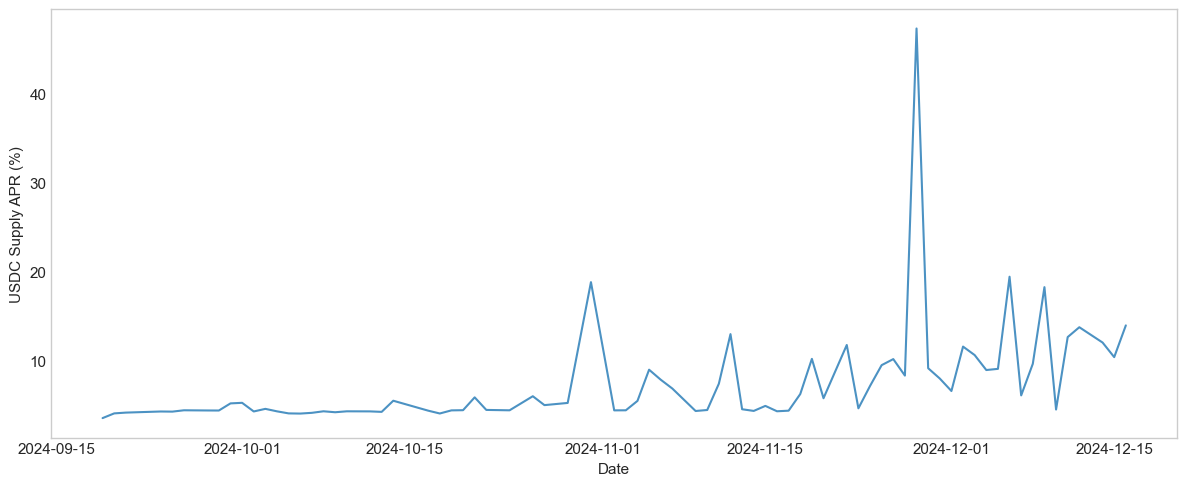

In [256]:
if df is not None:
    subset = df.loc['2024-09-19':'2024-12-16']
    fig, ax = plt.subplots(figsize=(12, 5))
    fig.patch.set_facecolor('white')
    ax.plot(subset.index, subset['usdc_supply_rate'] * 100, color='tab:blue', alpha=0.8)
    ax.set_ylabel('USDC Supply APR (%)')
    ax.set_xlabel('Date')
    # ax.set_title('USDC Supply Rate (Sep 2024 – Mar 2025)')
    ax.set_facecolor('white')
    plt.tight_layout()
    plt.show()
else:
    print("No data available. Run the data loading cells first.")

---
## 3. CIR Model Implementation and Calibration

The Cox-Ingersoll-Ross (CIR) model describes interest rate dynamics as:

$$dr_t = \kappa(\theta - r_t)dt + \sigma\sqrt{r_t}dW_t$$

Where:
- $\kappa$: Speed of mean reversion
- $\theta$: Long-term mean rate
- $\sigma$: Volatility
- $W_t$: Wiener process

**Feller Condition**: $2\kappa\theta > \sigma^2$ ensures rates stay positive.

In [257]:
@dataclass
class CIRParams:
    """Parameters for the CIR model."""
    kappa: float  # Mean reversion speed
    theta: float  # Long-term mean
    sigma: float  # Volatility
    
    def __post_init__(self):
        self.feller_ratio = 2 * self.kappa * self.theta / (self.sigma ** 2)
        
    @property
    def feller_satisfied(self) -> bool:
        return self.feller_ratio > 1
    
    def __repr__(self):
        return (f"CIRParams(kappa={self.kappa:.4f}, theta={self.theta:.4f}, "
                f"sigma={self.sigma:.4f}, feller={self.feller_ratio:.2f})")

In [258]:
def cir_log_likelihood(params: Tuple[float, float, float], 
                       rates: np.ndarray, 
                       dt: float) -> float:
    """
    Compute negative log-likelihood for CIR model using exact transition density.
    
    The CIR transition density is a non-central chi-squared distribution.
    """
    kappa, theta, sigma = params
    
    # Parameter constraints
    if kappa <= 0 or theta <= 0 or sigma <= 0:
        return 1e10
    
    # --- CHANGED: Feller condition from hard wall to soft quadratic penalty ---
    # Previously: `if 2*kappa*theta <= sigma**2: return 1e10`
    # Problem: the hard wall created a cliff in the objective landscape. When the
    # data has jumps (like WETH), the MLE wants sigma large enough that the Feller
    # boundary excludes it. The optimizer then gets trapped at extreme kappa/theta
    # values that satisfy Feller but don't fit the data (theta=1, sigma=0).
    # Fix: a soft penalty that smoothly discourages Feller violations without
    # making them impossible. penalty = 1000 * max(0, 1 - 2κθ/σ²)²
    # When Feller is satisfied (ratio > 1), penalty = 0. When violated, penalty
    # grows quadratically, guiding the optimizer back without hard infeasibility.
    feller_ratio = 2 * kappa * theta / (sigma ** 2)
    feller_penalty = 1000.0 * max(0, 1.0 - feller_ratio) ** 2
    # --- END CHANGE ---
    
    n = len(rates)
    r_t = rates[:-1]
    r_t1 = rates[1:]
    
    # CIR transition density parameters
    c = 2 * kappa / (sigma**2 * (1 - np.exp(-kappa * dt)))
    q = 2 * kappa * theta / sigma**2 - 1
    u = c * r_t * np.exp(-kappa * dt)
    v = c * r_t1
    
    # Non-central chi-squared log density
    # Using the relationship with modified Bessel function
    try:
        # Log likelihood calculation
        log_lik = np.sum(
            np.log(c) + 
            (q/2) * np.log(v/u) - 
            u - v + 
            np.log(iv(q, 2 * np.sqrt(u * v)) + 1e-300)
        )
        
        if np.isnan(log_lik) or np.isinf(log_lik):
            return 1e10
        
        # --- CHANGED: return now includes the soft Feller penalty ---
        # Previously: `return -log_lik`
        # The penalty term is 0 when Feller is satisfied, so it doesn't
        # affect well-behaved parameter regions.
        return -log_lik + feller_penalty
        # --- END CHANGE ---
        
    except (RuntimeWarning, FloatingPointError):
        return 1e10


def calibrate_cir_mle(rates: np.ndarray, dt: float = 1/365) -> CIRParams:
    """
    Calibrate CIR model using Maximum Likelihood Estimation.
    """
    # Initial guess using method of moments
    theta_init = np.mean(rates)
    sigma_init = np.std(np.diff(rates)) * np.sqrt(1/dt) / np.sqrt(theta_init)
    kappa_init = 1.0  # Starting guess for mean reversion
    
    # Ensure Feller condition in initial guess
    if 2 * kappa_init * theta_init <= sigma_init**2:
        sigma_init = np.sqrt(kappa_init * theta_init * 0.9)
    
    x0 = [kappa_init, theta_init, sigma_init]
    
    # Bounds
    bounds = [(0.01, 50), (1e-6, 1.0), (1e-6, 2.0)]
    
    # Optimize using differential evolution (more robust)
    result = differential_evolution(
        cir_log_likelihood,
        bounds=bounds,
        args=(rates, dt),
        seed=42,
        maxiter=1000,
        tol=1e-8,
        polish=True
    )
    
    return CIRParams(*result.x)

In [259]:
# Calibrate CIR models for both rates
if df is not None:
    # Resample to daily if needed (for consistent dt)
    df_daily = df.resample('D').mean().dropna()
    
    print("Calibrating CIR model for USDC Supply Rate...")
    usdc_rates = df_daily['usdc_supply_rate'].values
    usdc_rates = np.maximum(usdc_rates, 1e-6)  # Ensure positive
    cir_usdc = calibrate_cir_mle(usdc_rates)
    print(f"  {cir_usdc}")
    print(f"  Feller condition satisfied: {cir_usdc.feller_satisfied}")
    
    print("\nCalibrating CIR model for WETH Borrow Rate...")
    weth_rates = df_daily['weth_borrow_rate'].values
    weth_rates = np.maximum(weth_rates, 1e-6)  # Ensure positive
    cir_weth = calibrate_cir_mle(weth_rates)
    print(f"  {cir_weth}")
    print(f"  Feller condition satisfied: {cir_weth.feller_satisfied}")
else:
    cir_usdc, cir_weth = None, None

Calibrating CIR model for USDC Supply Rate...
  CIRParams(kappa=50.0000, theta=0.0573, sigma=1.4522, feller=2.72)
  Feller condition satisfied: True

Calibrating CIR model for WETH Borrow Rate...
  CIRParams(kappa=50.0000, theta=0.0288, sigma=0.4753, feller=12.75)
  Feller condition satisfied: True


In [260]:
def simulate_cir(params: CIRParams, 
                 r0: float, 
                 T: float, 
                 dt: float, 
                 n_paths: int) -> np.ndarray:
    """
    Simulate CIR paths using the Euler-Maruyama scheme with reflection.
    
    Args:
        params: CIR model parameters
        r0: Initial rate
        T: Time horizon (in years)
        dt: Time step (in years)
        n_paths: Number of simulation paths
    
    Returns:
        Array of shape (n_steps+1, n_paths) with simulated rates
    """
    n_steps = int(T / dt)
    rates = np.zeros((n_steps + 1, n_paths))
    rates[0] = r0
    
    sqrt_dt = np.sqrt(dt)
    
    for t in range(n_steps):
        r_t = rates[t]
        dW = np.random.randn(n_paths) * sqrt_dt
        
        # Euler-Maruyama step
        dr = params.kappa * (params.theta - r_t) * dt + params.sigma * np.sqrt(np.maximum(r_t, 0)) * dW
        rates[t + 1] = np.maximum(r_t + dr, 1e-8)  # Reflection at zero
    
    return rates


# Test CIR simulation
if cir_usdc is not None:
    print("Testing CIR simulation...")
    test_paths = simulate_cir(cir_usdc, usdc_rates[-1], T=1.0, dt=1/365, n_paths=100)
    print(f"Simulated {test_paths.shape[1]} paths over {test_paths.shape[0]-1} days")
    print(f"Final rate range: {test_paths[-1].min()*100:.2f}% - {test_paths[-1].max()*100:.2f}%")

Testing CIR simulation...
Simulated 100 paths over 365 days
Final rate range: 0.00% - 20.69%


---
## 4. CIR + Jumps Model (Poisson-Exponential), jump size capped at 65% APR 
We extend the CIR model with jumps:

$$dr_t = \kappa(\theta - r_t)dt + \sigma\sqrt{r_t}dW_t + J_t dN_t$$

Where:
- $N_t$: Poisson process with intensity $\lambda$ (jump frequency)
- $J_t$: Jump size drawn from Exponential($\mu$) distribution (asymmetric upward jumps)

This captures sudden rate spikes common in DeFi lending protocols.

The decision to clip jump sizes at 65% is based on the historical maximum (a little higher than that actually).

In [261]:
@dataclass
class CIRJumpParams:
    """Parameters for CIR model with Poisson-Exponential jumps."""
    # CIR parameters
    kappa: float
    theta: float
    sigma: float
    # Jump parameters
    jump_intensity: float  # lambda: average jumps per year
    jump_mean: float  # mu: mean jump size (exponential distribution)

    def __post_init__(self):
        self.feller_ratio = 2 * self.kappa * self.theta / (self.sigma ** 2)
    
    @property
    def expected_jump_contribution(self) -> float:
        """Expected contribution from jumps per year."""
        return self.jump_intensity * self.jump_mean
    
    def __repr__(self):
        return (f"CIRJumpParams(kappa={self.kappa:.4f}, theta={self.theta:.4f}, "
                f"sigma={self.sigma:.4f}, lambda={self.jump_intensity:.2f}, "
                f"mu={self.jump_mean:.4f}), feller={self.feller_ratio:.2f})")
            

In [262]:
def detect_jumps(rates: np.ndarray, threshold_std: float = 3.0) -> Tuple[np.ndarray, np.ndarray]:
    """
    Detect jumps in rate series using threshold method.
    
    Returns:
        jump_indices: Indices where jumps occurred
        jump_sizes: Size of each jump
    """
    rate_changes = np.diff(rates)
    
    # Use robust statistics (MAD) to identify outliers 
    median = np.median(rate_changes)
    mad = np.median(np.abs(rate_changes - median))
    threshold = median + threshold_std * 1.4826 * mad  # 1.4826 scales MAD to std for normal distribution
    
    # Only count positive jumps (rate spikes)
    jump_mask = rate_changes > threshold
    jump_indices = np.where(jump_mask)[0]
    jump_sizes = rate_changes[jump_mask]
    
    return jump_indices, jump_sizes

# This is a variant of cir_log_likelihood that accepts pre-selected (r_t, r_{t+1})
# pairs instead of a contiguous rate series. This is necessary because when we
# exclude jump transitions, the remaining observations are non-contiguous —
# we can't just pass a "filtered series" to the original function, since it
# assumes consecutive time steps. By accepting arbitrary pairs, we can feed
# only the diffusion-driven transitions to the MLE.
def cir_log_likelihood_pairs(params: Tuple[float, float, float],
                             r_t: np.ndarray,   # rate at time t (array of starting values)
                             r_t1: np.ndarray,   # rate at time t+1 (array of ending values)
                             dt: float) -> float:
    """
    CIR negative log-likelihood on arbitrary (r_t, r_{t+1}) pairs.
    This allows us to exclude jump transitions without reconstructing a series.
    """
    kappa, theta, sigma = params

    # Same positivity constraints as the original likelihood
    if kappa <= 0 or theta <= 0 or sigma <= 0:
        return 1e10

    # Same soft Feller penalty as in cir_log_likelihood (see comments there)
    feller_ratio = 2 * kappa * theta / (sigma ** 2)
    feller_penalty = 1000.0 * max(0, 1.0 - feller_ratio) ** 2

    # CIR transition density parameters — identical math to cir_log_likelihood,
    # but using the passed-in r_t/r_t1 arrays instead of rates[:-1]/rates[1:]
    c = 2 * kappa / (sigma**2 * (1 - np.exp(-kappa * dt)))
    q = 2 * kappa * theta / sigma**2 - 1
    u = c * r_t * np.exp(-kappa * dt)    # non-centrality parameter
    v = c * r_t1                          # scaled next-period rate

    try:
        # Exact same non-central chi-squared log-density formula
        log_lik = np.sum(
            np.log(c) +
            (q / 2) * np.log(v / u) -
            u - v +
            np.log(iv(q, 2 * np.sqrt(u * v)) + 1e-300)  # +1e-300 to avoid log(0)
        )
        if np.isnan(log_lik) or np.isinf(log_lik):
            return 1e10
        return -log_lik + feller_penalty  # negative LL + soft Feller penalty
    except (RuntimeWarning, FloatingPointError):
        return 1e10


# Previously this function:
#   1. Detected jumps
#   2. Subtracted each jump size from ALL subsequent rates: rates_filtered[idx+1:] -= size
#   3. Calibrated CIR on the reconstructed filtered series
#
# Problem: with many jumps (87 for WETH, all positive), the cumulative subtraction
# drove the filtered series to nearly zero (1058/1093 points clamped at 1e-6).
# The CIR optimizer then saw a flat line and returned theta=1 (upper bound), sigma=0.
#
# New approach: instead of reconstructing a filtered series, we directly select
# non-jump transition pairs (r_t, r_{t+1}) and pass them to cir_log_likelihood_pairs.
# This avoids any drift artifacts from series manipulation.
def calibrate_cir_jump(rates: np.ndarray, dt: float = 1/365) -> CIRJumpParams:
    """
    Calibrate CIR + Jump model using a two-step approach:
    1. Detect jumps
    2. Calibrate CIR on non-jump transition pairs only
    3. Calibrate jump parameters from detected jumps
    
    Key insight: instead of reconstructing a filtered series (which introduces
    drift artifacts when jumps are frequent), we directly exclude jump-day
    transitions from the MLE. We also exclude the day *after* each jump,
    since that transition starts from a post-jump level and the snap-back
    would bias the CIR diffusion fit.
    """
    # Step 1: Detect jumps (unchanged)
    jump_indices, jump_sizes = detect_jumps(rates)

    # Step 2: Build a boolean mask of transitions to EXCLUDE from CIR calibration.
    # A "transition" at index i is the pair (rates[i], rates[i+1]).
    n_transitions = len(rates) - 1
    exclude_mask = np.zeros(n_transitions, dtype=bool)

    # Mark jump transitions for exclusion. If index i is a jump, that means
    # rates[i+1] - rates[i] was an outlier spike — this transition was driven
    # by the jump process, not CIR diffusion, so it shouldn't enter the CIR MLE.
    exclude_mask[jump_indices] = True

    # Also exclude the transition AFTER each jump (index i+1).
    # Reason: the transition (rates[i+1], rates[i+2]) starts from a post-jump
    # elevated level. The rate typically snaps back via mean-reversion, producing
    # an unusually large negative change. This is a jump recovery artifact, not
    # representative of normal CIR diffusion dynamics. Including it would bias
    # kappa (mean reversion speed) upward and sigma downward.
    after_jump = jump_indices + 1                       # indices of post-jump transitions
    after_jump = after_jump[after_jump < n_transitions]  # clip to valid range
    exclude_mask[after_jump] = True

    # Extract the non-jump transition pairs: these are the "clean" diffusion
    # observations that the CIR model should explain.
    keep = ~exclude_mask
    r_t = rates[:-1][keep]   # starting rates of kept transitions
    r_t1 = rates[1:][keep]   # ending rates of kept transitions

    # Floor at 1e-6 to avoid numerical issues with sqrt(r) in CIR density
    r_t = np.maximum(r_t, 1e-6)
    r_t1 = np.maximum(r_t1, 1e-6)

    # Diagnostic print: shows how many transitions were kept vs excluded
    print(f"    CIR calibration: using {keep.sum()} of {n_transitions} transitions "
          f"(excluded {exclude_mask.sum()} jump-related)")

    # Method-of-moments initial guesses, computed from the KEPT pairs only
    # (not the full series, which would be contaminated by jump observations)
    theta_init = np.mean(r_t1)
    sigma_init = np.std(r_t1 - r_t) * np.sqrt(1/dt) / np.sqrt(max(theta_init, 1e-6))
    kappa_init = 1.0

    # Adjust sigma_init if it would violate Feller with the initial kappa
    if 2 * kappa_init * theta_init <= sigma_init**2:
        sigma_init = np.sqrt(kappa_init * theta_init * 0.9)

    # Same bounds as calibrate_cir_mle
    bounds = [(0.01, 50), (1e-6, 1.0), (1e-6, 2.0)]

    # Run differential evolution on cir_log_likelihood_pairs instead of
    # cir_log_likelihood. The key difference: we pass (r_t, r_t1) as separate
    # arrays via args, rather than a single contiguous rates array.
    result = differential_evolution(
        cir_log_likelihood_pairs,
        bounds=bounds,
        args=(r_t, r_t1, dt),  # non-jump pairs + time step
        seed=42,
        maxiter=1000,
        tol=1e-8,
        polish=True
    )

    cir_params = CIRParams(*result.x)

    # Step 3: Calibrate jump parameters (unchanged from original)
    # Total observation window in years for computing jump intensity
    n_years = n_transitions * dt

    if len(jump_sizes) > 0:
        # jump_intensity (λ): number of detected jumps / observation years
        jump_intensity = len(jump_sizes) / n_years
        # jump_mean (μ): MLE for exponential distribution = sample mean of jump sizes
        jump_mean = np.mean(jump_sizes)
    else:
        jump_intensity = 1.0
        jump_mean = 0.01

    return CIRJumpParams(
        kappa=cir_params.kappa,
        theta=cir_params.theta,
        sigma=cir_params.sigma,
        jump_intensity=jump_intensity,
        jump_mean=jump_mean
    )

In [263]:
# Calibrate CIR + Jump models
if df is not None:
    print("Calibrating CIR + Jump model for USDC Supply Rate...")
    jump_idx_usdc, jump_sizes_usdc = detect_jumps(usdc_rates)
    print(f"  Detected {len(jump_idx_usdc)} jumps in USDC rate")
    cir_jump_usdc = calibrate_cir_jump(usdc_rates)
    print(f"  {cir_jump_usdc}")
    
    print("\nCalibrating CIR + Jump model for WETH Borrow Rate...")
    jump_idx_weth, jump_sizes_weth = detect_jumps(weth_rates)
    print(f"  Detected {len(jump_idx_weth)} jumps in WETH rate")
    cir_jump_weth = calibrate_cir_jump(weth_rates)
    print(f"  {cir_jump_weth}")
else:
    cir_jump_usdc, cir_jump_weth = None, None

Calibrating CIR + Jump model for USDC Supply Rate...
  Detected 112 jumps in USDC rate
    CIR calibration: using 821 of 1022 transitions (excluded 201 jump-related)
  CIRJumpParams(kappa=47.0820, theta=0.0328, sigma=0.5900, lambda=40.00, mu=0.0340), feller=8.87)

Calibrating CIR + Jump model for WETH Borrow Rate...
  Detected 89 jumps in WETH rate
    CIR calibration: using 864 of 1022 transitions (excluded 158 jump-related)
  CIRJumpParams(kappa=50.0000, theta=0.0255, sigma=0.3375, lambda=31.79, mu=0.0076), feller=22.40)


## Simulation

In [264]:
def simulate_cir_jump(params: CIRJumpParams,
                      r0: float,
                      T: float,
                      dt: float,
                      n_paths: int,
                      max_rate: float = 0.65) -> np.ndarray:
    """
    Simulate CIR + Jump paths.
    
    Jumps follow Poisson process with Exponential jump sizes (always positive).
    Rates are capped at max_rate (65% APR) to reflect historical behavior.
    """
    n_steps = int(T / dt)
    rates = np.zeros((n_steps + 1, n_paths))
    rates[0] = min(r0, max_rate)
    
    sqrt_dt = np.sqrt(dt)
    jump_prob = params.jump_intensity * dt  # Probability of jump in each period
    
    # Cap jump sizes to ensure rates stay reasonable
    max_jump_size = max_rate - params.theta  # Max jump that keeps rate near ceiling
    
    for t in range(n_steps):
        r_t = rates[t]
        
        # Diffusion component (CIR)
        dW = np.random.randn(n_paths) * sqrt_dt
        dr_diffusion = (params.kappa * (params.theta - r_t) * dt + 
                       params.sigma * np.sqrt(np.maximum(r_t, 0)) * dW)
        
        # Jump component (Poisson-Exponential) with capped jump sizes
        jump_occurs = np.random.random(n_paths) < jump_prob
        jump_sizes = np.minimum(
            np.random.exponential(params.jump_mean, n_paths),
            max_jump_size  # Cap individual jump sizes
        )
        dr_jump = jump_occurs * jump_sizes
        
        # Apply changes and cap at max_rate
        rates[t + 1] = np.clip(r_t + dr_diffusion + dr_jump, 1e-8, max_rate)
    
    return rates


# Test CIR + Jump simulation
if cir_jump_weth is not None:
    print("Testing CIR + Jump simulation (with 65% APR cap)...")
    test_jump_paths = simulate_cir_jump(cir_jump_weth, weth_rates[-1], T=1.0, dt=1/365, n_paths=100)
    print(f"Final rate range: {test_jump_paths[-1].min()*100:.2f}% - {test_jump_paths[-1].max()*100:.2f}%")
    print(f"Max rate across all paths: {test_jump_paths.max()*100:.2f}%")

Testing CIR + Jump simulation (with 65% APR cap)...
Final rate range: 1.52% - 5.68%
Max rate across all paths: 10.27%


---
## 5. Monte Carlo Simulation Engine

Now we simulate the full carry trade strategy, including:
- Interest rate dynamics (CIR vs CIR+Jump)
- WETH price dynamics (from historical data or bootstrap)
- Portfolio P&L calculation
- Liquidation tracking

In [265]:
@dataclass
class SimulationResult:
    """Container for Monte Carlo simulation results."""
    # Time series (n_steps+1, n_paths)
    usdc_rates: np.ndarray
    weth_rates: np.ndarray
    weth_prices: np.ndarray
    collateral_values: np.ndarray  # USDC collateral value over time
    debt_values: np.ndarray  # WETH debt value in USDC over time
    ltv_ratios: np.ndarray  # Current LTV over time
    pnl: np.ndarray  # Cumulative P&L over time
    
    # Terminal values (n_paths,)
    final_pnl: np.ndarray
    liquidated: np.ndarray  # Boolean mask of liquidated paths
    liquidation_times: np.ndarray  # Time of liquidation (NaN if not liquidated)
    
    # Config
    dt: float
    T: float
    model_type: str  # 'CIR' or 'CIR_Jump'

In [266]:
def bootstrap_price_returns(historical_returns: np.ndarray, 
                            n_steps: int, 
                            n_paths: int) -> np.ndarray:
    """
    Bootstrap future price returns from historical data.
    Uses block bootstrap to preserve autocorrelation.
    """
    block_size = 5  # 5-day blocks to preserve short-term momentum
    n_blocks = int(np.ceil(n_steps / block_size))
    
    # Sample blocks with replacement
    n_available = len(historical_returns) - block_size
    block_starts = np.random.randint(0, n_available, size=(n_blocks, n_paths))
    
    # Build return paths
    returns = np.zeros((n_steps, n_paths))
    for i in range(n_blocks):
        for j in range(n_paths):
            start_idx = block_starts[i, j]
            end_idx = min(i * block_size + block_size, n_steps)
            start_pos = i * block_size
            length = min(block_size, n_steps - start_pos)
            returns[start_pos:start_pos + length, j] = historical_returns[start_idx:start_idx + length]
    
    return returns

In [267]:
def run_carry_trade_simulation(
    config: StrategyConfig,
    usdc_cir_params,  # CIRParams or CIRJumpParams
    weth_cir_params,  # CIRParams or CIRJumpParams
    initial_usdc_rate: float,
    initial_weth_rate: float,
    initial_weth_price: float,
    historical_returns: np.ndarray,
    T: float,  # Simulation horizon in years
    use_jumps: bool = False
) -> SimulationResult:
    """
    Run full Monte Carlo simulation of the carry trade strategy.
    """
    n_steps = int(T / config.dt)
    n_paths = config.n_simulations
    
    # Select simulation function based on model type
    sim_func = simulate_cir_jump if use_jumps else simulate_cir
    model_type = 'CIR_Jump' if use_jumps else 'CIR'
    
    # Simulate interest rates
    usdc_rates = sim_func(usdc_cir_params, initial_usdc_rate, T, config.dt, n_paths)
    weth_rates = sim_func(weth_cir_params, initial_weth_rate, T, config.dt, n_paths)
    
    # Simulate WETH prices using bootstrap
    price_returns = bootstrap_price_returns(historical_returns, n_steps, n_paths)
    weth_prices = np.zeros((n_steps + 1, n_paths))
    weth_prices[0] = initial_weth_price
    for t in range(n_steps):
        weth_prices[t + 1] = weth_prices[t] * (1 + price_returns[t])
    
    # Initialize position tracking
    # Collateral: USDC deposited (earns supply rate)
    # Debt: WETH borrowed (pays borrow rate, valued in USDC)
    
    collateral = np.zeros((n_steps + 1, n_paths))
    debt_weth = np.zeros((n_steps + 1, n_paths))  # Debt in WETH units
    debt_usdc = np.zeros((n_steps + 1, n_paths))  # Debt value in USDC
    ltv_ratios = np.zeros((n_steps + 1, n_paths))
    pnl = np.zeros((n_steps + 1, n_paths))
    
    # Initial position
    collateral[0] = config.initial_collateral_usdc
    initial_borrow_usdc = config.initial_collateral_usdc * config.ltv_ratio
    debt_weth[0] = initial_borrow_usdc / initial_weth_price
    debt_usdc[0] = initial_borrow_usdc
    ltv_ratios[0] = config.ltv_ratio
    
    # Track liquidations
    liquidated = np.zeros(n_paths, dtype=bool)
    liquidation_times = np.full(n_paths, np.nan)
    
    # Simulate forward
    for t in range(n_steps):
        # Active paths (not yet liquidated)
        active = ~liquidated
        
        # Accrue interest on collateral (daily compounding)
        daily_supply_rate = usdc_rates[t] * config.dt
        collateral[t + 1, active] = collateral[t, active] * (1 + daily_supply_rate[active])
        
        # Accrue interest on debt (daily compounding)
        daily_borrow_rate = weth_rates[t] * config.dt
        debt_weth[t + 1, active] = debt_weth[t, active] * (1 + daily_borrow_rate[active])
        
        # Update debt value in USDC
        debt_usdc[t + 1, active] = debt_weth[t + 1, active] * weth_prices[t + 1, active]
        
        # Calculate current LTV
        ltv_ratios[t + 1, active] = debt_usdc[t + 1, active] / collateral[t + 1, active]
        
        # Check for liquidations
        newly_liquidated = active & (ltv_ratios[t + 1] >= config.liquidation_threshold)
        liquidated |= newly_liquidated
        liquidation_times[newly_liquidated] = (t + 1) * config.dt
        
        # For liquidated positions, apply penalty and close
        liquidation_value = (collateral[t + 1, newly_liquidated] * 
                            (1 - config.liquidation_penalty) - 
                            debt_usdc[t + 1, newly_liquidated])
        
        # Carry forward liquidation state
        collateral[t + 1, liquidated] = 0
        debt_weth[t + 1, liquidated] = 0
        debt_usdc[t + 1, liquidated] = 0
        ltv_ratios[t + 1, liquidated] = 0
        
        # Calculate P&L: equity value = collateral - debt
        pnl[t + 1] = collateral[t + 1] - debt_usdc[t + 1] - config.initial_collateral_usdc * (1 - config.ltv_ratio)
    
    # Adjust P&L for liquidated paths
    for i in np.where(liquidated)[0]:
        liq_step = int(liquidation_times[i] / config.dt)
        liq_value = (collateral[liq_step, i] * (1 - config.liquidation_penalty) - 
                    debt_usdc[liq_step, i] - config.initial_collateral_usdc * (1 - config.ltv_ratio))
        pnl[liq_step:, i] = liq_value
    
    return SimulationResult(
        usdc_rates=usdc_rates,
        weth_rates=weth_rates,
        weth_prices=weth_prices,
        collateral_values=collateral,
        debt_values=debt_usdc,
        ltv_ratios=ltv_ratios,
        pnl=pnl,
        final_pnl=pnl[-1],
        liquidated=liquidated,
        liquidation_times=liquidation_times,
        dt=config.dt,
        T=T,
        model_type=model_type
    )

In [268]:
# Run simulations for both models
if df is not None and cir_usdc is not None:
    T_horizon = 1.0  # 1 year forward simulation
    
    # Get initial values from latest data
    initial_usdc_rate = usdc_rates[-1]
    initial_weth_rate = weth_rates[-1]
    initial_weth_price = df_daily['weth_price'].iloc[-1]
    # Window to last 365 days to avoid stale crash-era volatility inflating liquidation risk
    historical_returns = df_daily['weth_return'].dropna().iloc[-365:].values
    
    print(f"Initial Conditions:")
    print(f"  USDC Supply Rate: {initial_usdc_rate*100:.2f}%")
    print(f"  WETH Borrow Rate: {initial_weth_rate*100:.2f}%")
    print(f"  WETH Price: ${initial_weth_price:,.2f}")
    print(f"  Historical return volatility (last 365d): {np.std(historical_returns)*np.sqrt(365)*100:.1f}% annualized")
    
    print(f"\nRunning CIR model simulation ({config.n_simulations:,} paths)...")
    results_cir = run_carry_trade_simulation(
        config, cir_usdc, cir_weth,
        initial_usdc_rate, initial_weth_rate, initial_weth_price,
        historical_returns, T_horizon, use_jumps=False
    )
    print(f"  Completed. Liquidation rate: {results_cir.liquidated.mean()*100:.2f}%")
    
    print(f"\nRunning CIR + Jump model simulation ({config.n_simulations:,} paths)...")
    results_jump = run_carry_trade_simulation(
        config, cir_jump_usdc, cir_jump_weth,
        initial_usdc_rate, initial_weth_rate, initial_weth_price,
        historical_returns, T_horizon, use_jumps=True
    )
    print(f"  Completed. Liquidation rate: {results_jump.liquidated.mean()*100:.2f}%")
else:
    results_cir, results_jump = None, None


Initial Conditions:
  USDC Supply Rate: 3.28%
  WETH Borrow Rate: 2.11%
  WETH Price: $2,019.91
  Historical return volatility (last 365d): 68.0% annualized

Running CIR model simulation (10,000 paths)...
  Completed. Liquidation rate: 29.40%

Running CIR + Jump model simulation (10,000 paths)...
  Completed. Liquidation rate: 28.52%


---
## 6. Liquidation Probability Analysis

In [269]:
def analyze_liquidation_risk(result: SimulationResult, config: StrategyConfig) -> Dict:
    """Compute detailed liquidation risk metrics."""
    n_paths = len(result.liquidated)
    n_liquidated = result.liquidated.sum()
    
    metrics = {
        'model': result.model_type,
        'n_simulations': n_paths,
        'liquidation_probability': n_liquidated / n_paths,
        'liquidation_count': n_liquidated,
        'survival_probability': 1 - n_liquidated / n_paths,
    }
    
    if n_liquidated > 0:
        liq_times = result.liquidation_times[result.liquidated]
        metrics['mean_time_to_liquidation'] = np.mean(liq_times)
        metrics['median_time_to_liquidation'] = np.median(liq_times)
        metrics['min_time_to_liquidation'] = np.min(liq_times)
        metrics['max_time_to_liquidation'] = np.max(liq_times)
        
        # Time-based liquidation probabilities
        metrics['prob_liq_30d'] = (liq_times <= 30/365).mean() * metrics['liquidation_probability']
        metrics['prob_liq_90d'] = (liq_times <= 90/365).mean() * metrics['liquidation_probability']
        metrics['prob_liq_180d'] = (liq_times <= 180/365).mean() * metrics['liquidation_probability']
    else:
        metrics['mean_time_to_liquidation'] = np.nan
        metrics['median_time_to_liquidation'] = np.nan
        metrics['prob_liq_30d'] = 0
        metrics['prob_liq_90d'] = 0
        metrics['prob_liq_180d'] = 0
    
    # LTV distribution at terminal time (non-liquidated paths)
    surviving_ltv = result.ltv_ratios[-1, ~result.liquidated]
    if len(surviving_ltv) > 0:
        metrics['surviving_ltv_mean'] = np.mean(surviving_ltv)
        metrics['surviving_ltv_std'] = np.std(surviving_ltv)
        metrics['surviving_ltv_95th'] = np.percentile(surviving_ltv, 95)
        metrics['prob_ltv_above_75'] = (surviving_ltv > 0.75).mean()
    
    return metrics

In [270]:
# Analyze liquidation risk for both models
if results_cir is not None:
    liq_metrics_cir = analyze_liquidation_risk(results_cir, config)
    liq_metrics_jump = analyze_liquidation_risk(results_jump, config)
    
    print("=" * 70)
    print("LIQUIDATION RISK ANALYSIS")
    print("=" * 70)
    
    print(f"\n{'Metric':<40} {'CIR':>12} {'CIR+Jump':>12}")
    print("-" * 70)
    
    for key in ['liquidation_probability', 'survival_probability', 
                'prob_liq_30d', 'prob_liq_90d', 'prob_liq_180d']:
        v1 = liq_metrics_cir.get(key, 0)
        v2 = liq_metrics_jump.get(key, 0)
        print(f"{key:<40} {v1*100:>11.2f}% {v2*100:>11.2f}%")
    
    for key in ['mean_time_to_liquidation', 'median_time_to_liquidation']:
        v1 = liq_metrics_cir.get(key, np.nan)
        v2 = liq_metrics_jump.get(key, np.nan)
        if not np.isnan(v1) or not np.isnan(v2):
            print(f"{key:<40} {v1*365:>10.0f}d {v2*365:>10.0f}d")
    
    print("-" * 70)
    
    for key in ['surviving_ltv_mean', 'surviving_ltv_95th', 'prob_ltv_above_75']:
        v1 = liq_metrics_cir.get(key, 0)
        v2 = liq_metrics_jump.get(key, 0)
        if 'prob' in key:
            print(f"{key:<40} {v1*100:>11.2f}% {v2*100:>11.2f}%")
        else:
            print(f"{key:<40} {v1*100:>11.2f}% {v2*100:>11.2f}%")

LIQUIDATION RISK ANALYSIS

Metric                                            CIR     CIR+Jump
----------------------------------------------------------------------
liquidation_probability                        29.40%       28.52%
survival_probability                           70.60%       71.48%
prob_liq_30d                                    0.27%        0.28%
prob_liq_90d                                    6.22%        6.65%
prob_liq_180d                                  17.30%       16.77%
mean_time_to_liquidation                        169d        169d
median_time_to_liquidation                      154d        154d
----------------------------------------------------------------------
surviving_ltv_mean                             33.61%       33.55%
surviving_ltv_95th                             63.19%       62.58%
prob_ltv_above_75                               0.84%        0.81%


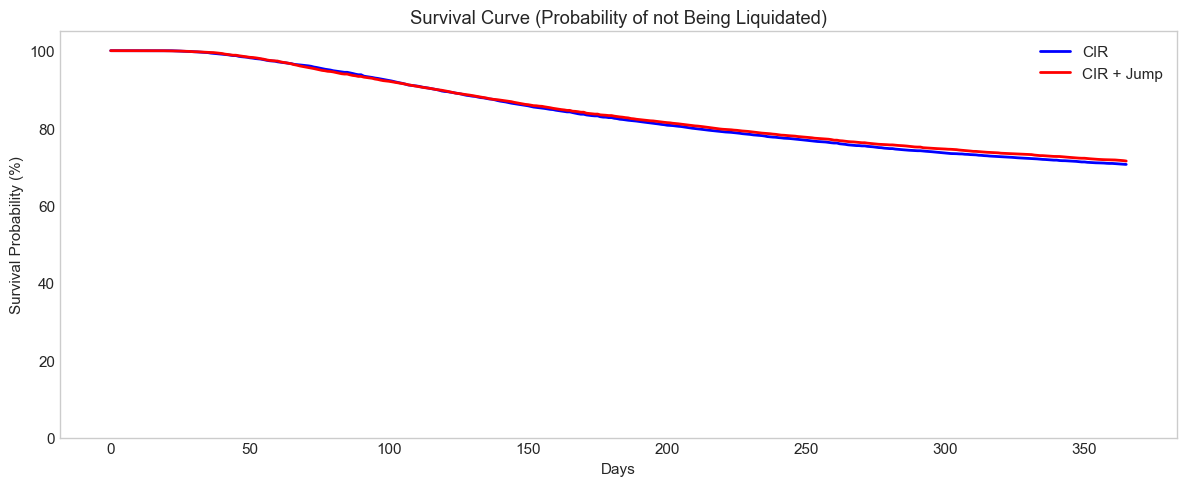

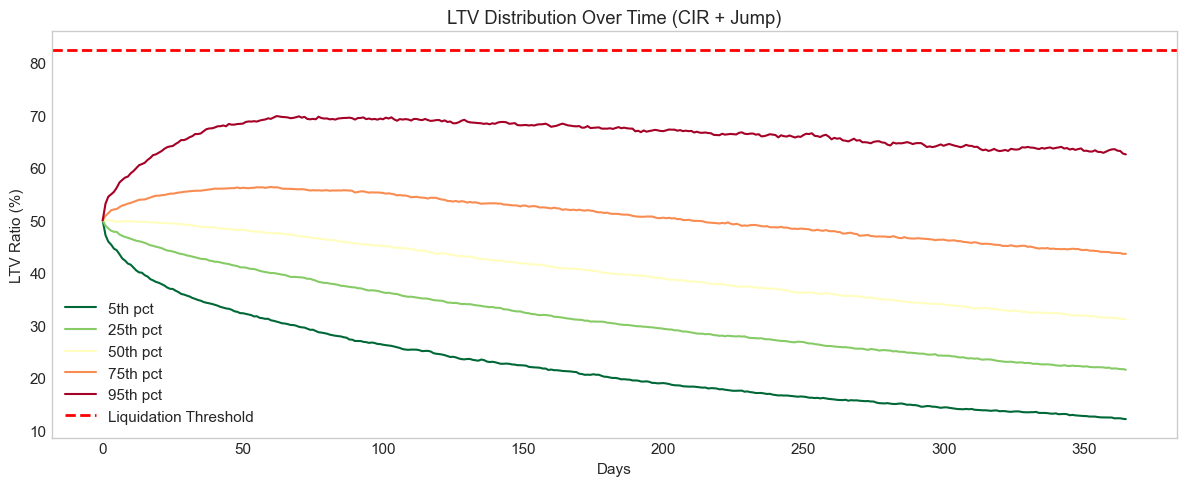

In [271]:
# Visualize liquidation analysis
if results_cir is not None:
    time_points = np.arange(0, int(results_cir.T / results_cir.dt) + 1) * results_cir.dt * 365
    
    # Plot 1: Survival curves
    fig, ax = plt.subplots(figsize=(12, 5))
    fig.patch.set_alpha(0)
    for result, label, color in [(results_cir, 'CIR', 'blue'), 
                                   (results_jump, 'CIR + Jump', 'red')]:
        survival = np.zeros(len(time_points))
        for i, t in enumerate(time_points / 365):
            survival[i] = (~result.liquidated | (result.liquidation_times > t)).mean()
        ax.plot(time_points, survival * 100, label=label, color=color, linewidth=2)
    ax.set_xlabel('Days')
    ax.set_ylabel('Survival Probability (%)')
    ax.set_title('Survival Curve (Probability of not Being Liquidated)')
    ax.legend()
    ax.set_ylim([0, 105])
    ax.set_facecolor('none')
    plt.tight_layout()
    plt.show()
    
    # Plot 2: LTV distribution over time
    fig, ax = plt.subplots(figsize=(12, 5))
    fig.patch.set_alpha(0)
    percentiles = [5, 25, 50, 75, 95]
    colors = plt.cm.RdYlGn_r(np.linspace(0, 1, len(percentiles)))
    ltv_over_time = results_jump.ltv_ratios.copy()
    ltv_over_time[ltv_over_time == 0] = np.nan
    for pct, color in zip(percentiles, colors):
        pct_values = np.nanpercentile(ltv_over_time, pct, axis=1) * 100
        ax.plot(time_points, pct_values, label=f'{pct}th pct', color=color, linewidth=1.5)
    ax.axhline(config.liquidation_threshold * 100, color='red', linestyle='--', 
                linewidth=2, label='Liquidation Threshold')
    ax.set_xlabel('Days')
    ax.set_ylabel('LTV Ratio (%)')
    ax.set_title('LTV Distribution Over Time (CIR + Jump)')
    ax.legend(loc='lower left')
    ax.set_facecolor('none')
    plt.tight_layout()
    plt.show()
    
    # # Plot 3: Terminal LTV distribution (CIR vs CIR+Jump at baseline LTV)
    # fig, ax = plt.subplots(figsize=(12, 5))
    # fig.patch.set_alpha(0)
    # for result, label, color in [(results_cir, 'CIR', 'blue'), 
    #                                (results_jump, 'CIR + Jump', 'red')]:
    #     terminal_ltv = result.ltv_ratios[-1, ~result.liquidated] * 100
    #     if len(terminal_ltv) > 0:
    #         ax.hist(terminal_ltv, bins=50, alpha=0.5, label=label, color=color, density=True)
    # ax.axvline(config.liquidation_threshold * 100, color='red', linestyle='--', 
    #             linewidth=2, label='Liquidation Threshold')
    # ax.axvline(config.ltv_ratio * 100, color='green', linestyle='--', 
    #             linewidth=2, label='Initial LTV')
    # ax.set_xlabel('Terminal LTV (%)')
    # ax.set_ylabel('Density')
    # ax.set_title('Terminal LTV Distribution (Surviving Paths)')
    # ax.legend()
    # ax.set_facecolor('none')
    # plt.tight_layout()
    # plt.show()
    
    # Plot 4: Terminal LTV distribution across initial LTV levels (40%, 60%, 70%) — CIR vs CIR+Jump
    


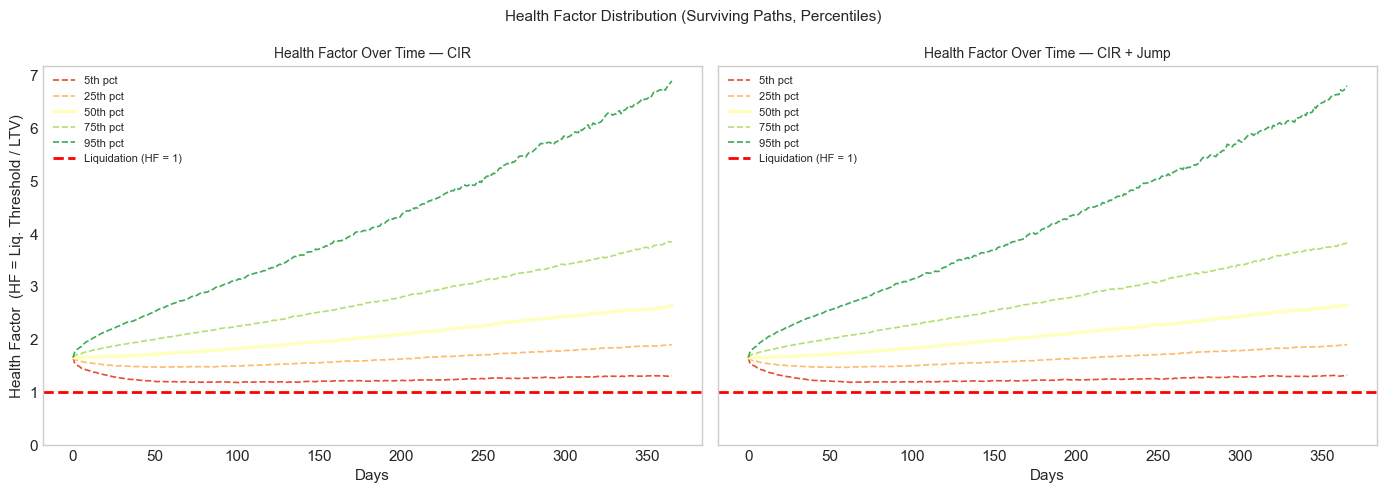

In [272]:

# Health Factor = (Collateral × Liquidation Threshold) / Debt
#               = Liquidation Threshold / LTV
# HF < 1 → liquidation
if results_cir is not None:
    time_days = np.arange(results_jump.ltv_ratios.shape[0]) * config.dt * 365
    pcts = [5, 25, 50, 75, 95]

    fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
    fig.patch.set_alpha(0)

    for ax, result, title in [
        (axes[0], results_cir,  'CIR'),
        (axes[1], results_jump, 'CIR + Jump'),
    ]:
        # Compute HF; mask liquidated paths (LTV set to 0 after liquidation → would give HF=inf)
        ltv = result.ltv_ratios.copy().astype(float)
        ltv[ltv == 0] = np.nan
        hf = config.liquidation_threshold / ltv  # shape (n_steps+1, n_paths)

        colors = plt.cm.RdYlGn(np.linspace(0.15, 0.85, len(pcts)))
        for p, c in zip(pcts, colors):
            vals = np.nanpercentile(hf, p, axis=1)
            lw = 2.5 if p == 50 else 1.2
            ls = '-' if p == 50 else '--'
            ax.plot(time_days, vals, color=c, lw=lw, ls=ls, label=f'{p}th pct')

        ax.axhline(1.0, color='red', lw=2, ls='--', label='Liquidation (HF = 1)')
        ax.set_xlabel('Days')
        ax.set_title(f'Health Factor Over Time — {title}', fontsize=10)
        ax.legend(fontsize=8, loc='upper left')
        ax.set_facecolor('none')
        ax.set_ylim(bottom=0)

    axes[0].set_ylabel('Health Factor  (HF = Liq. Threshold / LTV)')
    fig.suptitle('Health Factor Distribution (Surviving Paths, Percentiles)', fontsize=11)
    plt.tight_layout()
    plt.show()


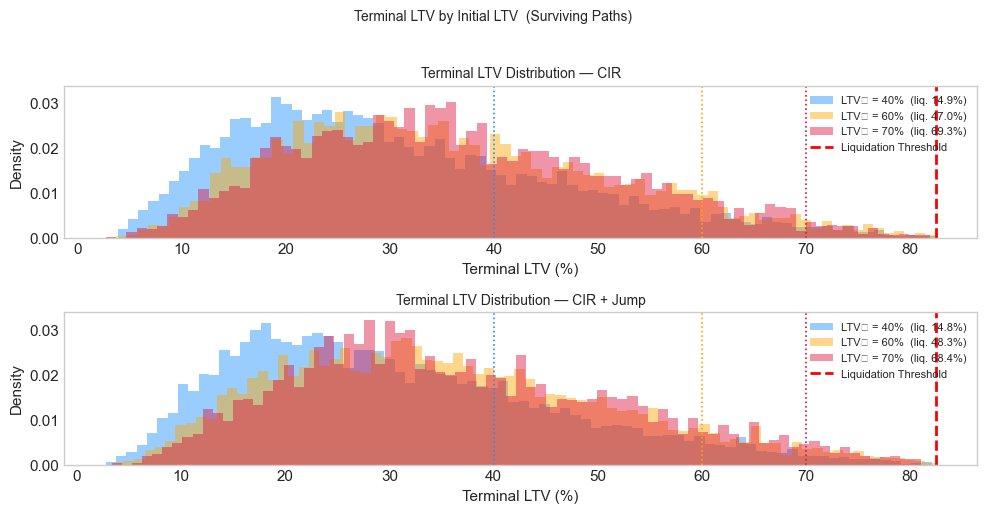

In [273]:
import copy
ltv_levels = [0.40, 0.60, 0.70]
palette = {0.40: 'dodgerblue', 0.60: 'orange', 0.70: 'crimson'}

fig, (ax_cir, ax_jump) = plt.subplots(2, 1, figsize=(10, 5), sharey=True)
fig.patch.set_alpha(0)

for ltv_init in ltv_levels:
    cfg = copy.deepcopy(config)
    cfg.ltv_ratio = ltv_init
    
    # CIR simulation
    sim_cir = run_carry_trade_simulation(
        cfg,
        cir_usdc, cir_weth,
        initial_usdc_rate, initial_weth_rate,
        initial_weth_price, historical_returns,
        T_horizon, use_jumps=False,
    )
    term_cir = sim_cir.ltv_ratios[-1, ~sim_cir.liquidated] * 100
    if len(term_cir) > 0:
        ax_cir.hist(term_cir, bins=80, alpha=0.45, density=True,
                    color=palette[ltv_init],
                    label=f'LTV₀ = {ltv_init*100:.0f}%  (liq. {sim_cir.liquidated.mean()*100:.1f}%)')
    
    # CIR + Jump simulation
    sim_jump = run_carry_trade_simulation(
        cfg,
        cir_jump_usdc, cir_jump_weth,
        initial_usdc_rate, initial_weth_rate,
        initial_weth_price, historical_returns,
        T_horizon, use_jumps=True,
    )
    term_jump = sim_jump.ltv_ratios[-1, ~sim_jump.liquidated] * 100
    if len(term_jump) > 0:
        ax_jump.hist(term_jump, bins=80, alpha=0.45, density=True,
                        color=palette[ltv_init],
                        label=f'LTV₀ = {ltv_init*100:.0f}%  (liq. {sim_jump.liquidated.mean()*100:.1f}%)')

for ax, title in [(ax_cir, 'CIR'), (ax_jump, 'CIR + Jump')]:
    ax.axvline(config.liquidation_threshold * 100, color='red', ls='--', lw=2,
                label='Liquidation Threshold')
    for ltv_init in ltv_levels:
        ax.axvline(ltv_init * 100, color=palette[ltv_init], ls=':', lw=1.2)
    ax.set_xlabel('Terminal LTV (%)')
    ax.set_title(f'Terminal LTV Distribution — {title}', fontsize=10)
    ax.legend(loc='upper right', fontsize=8)
    ax.set_facecolor('none')

ax_cir.set_ylabel('Density')
ax_jump.set_ylabel('Density')
fig.suptitle('Terminal LTV by Initial LTV  (Surviving Paths)', fontsize=10, y=1.02)
plt.tight_layout()
plt.show()

---
## 7. P&L Analysis and Strategy Sustainability

In [274]:
def analyze_pnl(result: SimulationResult, config: StrategyConfig) -> Dict:
    """Compute P&L and risk metrics."""
    initial_equity = config.initial_collateral_usdc * (1 - config.ltv_ratio)
    final_pnl = result.final_pnl
    returns = final_pnl / initial_equity
    
    metrics = {
        'model': result.model_type,
        'initial_equity': initial_equity,
        'mean_pnl': np.mean(final_pnl),
        'median_pnl': np.median(final_pnl),
        'std_pnl': np.std(final_pnl),
        'mean_return': np.mean(returns),
        'std_return': np.std(returns),
        # 'sharpe_ratio': np.mean(returns) / np.std(returns) if np.std(returns) > 0 else 0,
        'min_pnl': np.min(final_pnl),
        'max_pnl': np.max(final_pnl),
        'pct_profitable': (final_pnl > 0).mean(),
        'var_95': np.percentile(final_pnl, 5),
        'cvar_95': np.mean(final_pnl[final_pnl <= np.percentile(final_pnl, 5)]),
        'var_99': np.percentile(final_pnl, 1),
        'cvar_99': np.mean(final_pnl[final_pnl <= np.percentile(final_pnl, 1)]),
    }
    
    # Conditional metrics (excluding liquidated paths)
    surviving = ~result.liquidated
    if surviving.sum() > 0:
        surviving_pnl = final_pnl[surviving]
        metrics['mean_pnl_if_survive'] = np.mean(surviving_pnl)
        metrics['pct_profitable_if_survive'] = (surviving_pnl > 0).mean()
    
    return metrics

In [275]:
# Analyze P&L for both models
if results_cir is not None:
    pnl_metrics_cir = analyze_pnl(results_cir, config)
    pnl_metrics_jump = analyze_pnl(results_jump, config)
    
    print("=" * 70)
    print("P&L AND PERFORMANCE ANALYSIS")
    print("=" * 70)
    print(f"Initial Equity (50% of collateral): ${pnl_metrics_cir['initial_equity']:,.0f}")
    print(f"Simulation Horizon: {results_cir.T:.1f} years")
    
    print(f"\n{'Metric':<40} {'CIR':>15} {'CIR+Jump':>15}")
    print("-" * 70)
    
    for key in ['mean_pnl', 'median_pnl', 'std_pnl', 'min_pnl', 'max_pnl', 'mean_pnl_if_survive']:
        v1 = pnl_metrics_cir.get(key, 0)
        v2 = pnl_metrics_jump.get(key, 0)
        print(f"{key:<40} ${v1:>13,.0f} ${v2:>13,.0f}")
    
    print("-" * 70)
    

    # Sharpe Ratio of 0
    for key in ['mean_return', 'std_return']:
        v1 = pnl_metrics_cir.get(key, 0)
        v2 = pnl_metrics_jump.get(key, 0)

    print("-" * 70)
    
    for key in ['pct_profitable', 'pct_profitable_if_survive']:
        v1 = pnl_metrics_cir.get(key, 0)
        v2 = pnl_metrics_jump.get(key, 0)
        print(f"{key:<40} {v1*100:>14.1f}% {v2*100:>14.1f}%")

P&L AND PERFORMANCE ANALYSIS
Initial Equity (50% of collateral): $50,000
Simulation Horizon: 1.0 years

Metric                                               CIR        CIR+Jump
----------------------------------------------------------------------
mean_pnl                                 $         -182 $          676
median_pnl                               $       12,333 $       13,005
std_pnl                                  $       34,658 $       34,579
min_pnl                                  $      -50,000 $      -50,000
max_pnl                                  $       53,575 $       52,871
mean_pnl_if_survive                      $       20,271 $       20,638
----------------------------------------------------------------------
----------------------------------------------------------------------
pct_profitable                                     61.5%           62.3%
pct_profitable_if_survive                          87.2%           87.2%


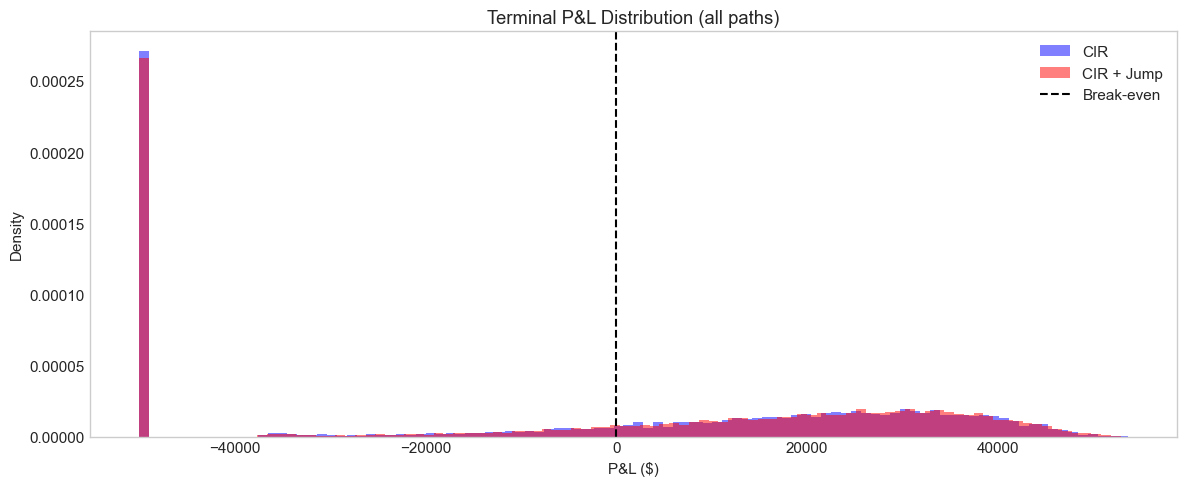

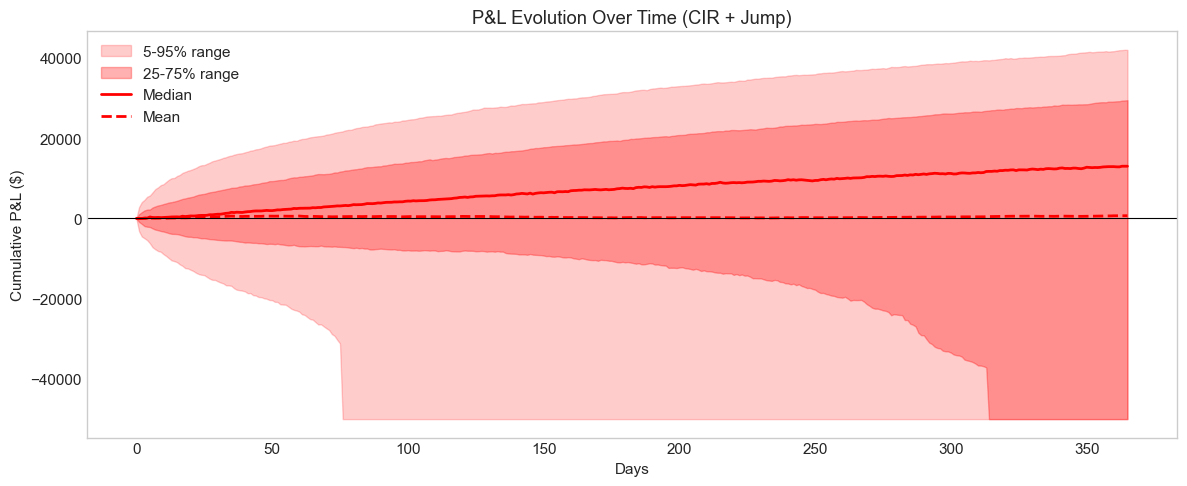

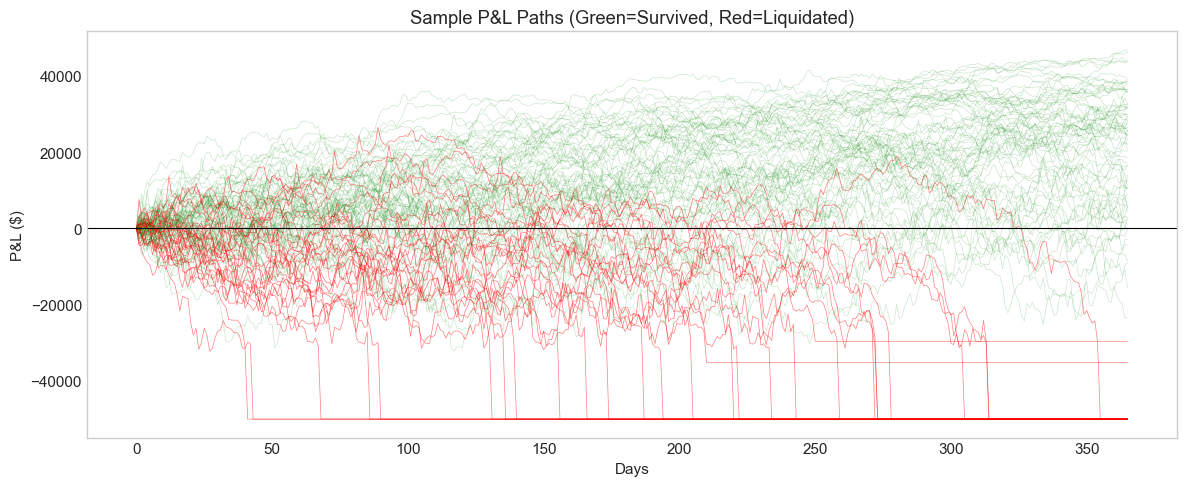

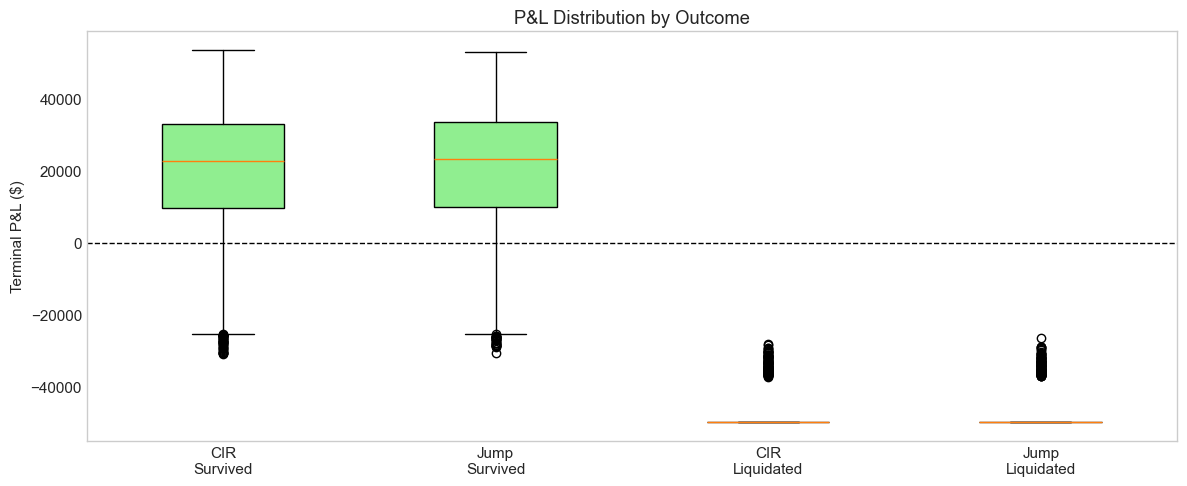

In [276]:
# Visualize P&L analysis
if results_cir is not None:
    time_days = np.arange(results_jump.pnl.shape[0]) * results_jump.dt * 365
    
    # Plot 1: P&L distribution
    fig, ax = plt.subplots(figsize=(12, 5))
    fig.patch.set_alpha(0)
    for result, label, color in [(results_cir, 'CIR', 'blue'), 
                                   (results_jump, 'CIR + Jump', 'red')]:
        ax.hist(result.final_pnl, bins=100, alpha=0.5, label=label, color=color, density=True)
    ax.axvline(0, color='black', linestyle='--', linewidth=1.5, label='Break-even')
    ax.set_xlabel('P&L ($)')
    ax.set_ylabel('Density')
    ax.set_title('Terminal P&L Distribution (all paths)')
    ax.legend()
    ax.set_facecolor('none')
    plt.tight_layout()
    plt.show()
    
    # Plot 2: Cumulative P&L paths
    fig, ax = plt.subplots(figsize=(12, 5))
    fig.patch.set_alpha(0)
    pnl = results_jump.pnl
    ax.fill_between(time_days, np.percentile(pnl, 5, axis=1), np.percentile(pnl, 95, axis=1),
                     alpha=0.2, color='red', label='5-95% range')
    ax.fill_between(time_days, np.percentile(pnl, 25, axis=1), np.percentile(pnl, 75, axis=1),
                     alpha=0.3, color='red', label='25-75% range')
    ax.plot(time_days, np.median(pnl, axis=1), 'r-', linewidth=2, label='Median')
    ax.plot(time_days, np.mean(pnl, axis=1), 'r--', linewidth=2, label='Mean')
    ax.axhline(0, color='black', linestyle='-', linewidth=0.8)
    ax.set_xlabel('Days')
    ax.set_ylabel('Cumulative P&L ($)')
    ax.set_title('P&L Evolution Over Time (CIR + Jump)')
    ax.legend()
    ax.set_facecolor('none')
    plt.tight_layout()
    plt.show()
    
    # Plot 3: Sample paths
    fig, ax = plt.subplots(figsize=(12, 5))
    fig.patch.set_alpha(0)
    n_sample = 100
    sample_idx = np.random.choice(config.n_simulations, n_sample, replace=False)
    n_liq_sample = results_jump.liquidated[sample_idx].sum()
    for idx in sample_idx:
        color = 'red' if results_jump.liquidated[idx] else 'green'
        alpha = 0.5 if results_jump.liquidated[idx] else 0.2
        ax.plot(time_days, results_jump.pnl[:, idx], color=color, alpha=alpha, linewidth=0.5)
    ax.axhline(0, color='black', linestyle='-', linewidth=0.8)
    ax.set_xlabel('Days')
    ax.set_ylabel('P&L ($)')
    ax.set_title('Sample P&L Paths (Green=Survived, Red=Liquidated)')
    ax.set_facecolor('none')
    plt.tight_layout()
    plt.show()
      
    # Plot 4: P&L by liquidation status
    fig, ax = plt.subplots(figsize=(12, 5))
    fig.patch.set_alpha(0)
    cir_survived_pnl = results_cir.final_pnl[~results_cir.liquidated]
    cir_liq_pnl = results_cir.final_pnl[results_cir.liquidated]
    jump_survived_pnl = results_jump.final_pnl[~results_jump.liquidated]
    jump_liq_pnl = results_jump.final_pnl[results_jump.liquidated]
    box_data = [
        cir_survived_pnl if len(cir_survived_pnl) > 0 else [0],
        jump_survived_pnl if len(jump_survived_pnl) > 0 else [0],
        cir_liq_pnl if len(cir_liq_pnl) > 0 else [0],
        jump_liq_pnl if len(jump_liq_pnl) > 0 else [0]
    ]
    bp = ax.boxplot(box_data, labels=['CIR\nSurvived', 'Jump\nSurvived', 'CIR\nLiquidated', 'Jump\nLiquidated'],
                     patch_artist=True)
    colors = ['lightgreen', 'lightgreen', 'lightcoral', 'lightcoral']
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
    ax.axhline(0, color='black', linestyle='--', linewidth=1)
    ax.set_ylabel('Terminal P&L ($)')
    ax.set_title('P&L Distribution by Outcome')
    ax.set_facecolor('none')
    plt.tight_layout()
    plt.show()

---
## 8. Summary and Recommendations

In [277]:
def generate_summary_report(results_cir: SimulationResult, 
                            results_jump: SimulationResult,
                            config: StrategyConfig) -> str:
    """Generate a summary report of the analysis."""
    liq_cir = analyze_liquidation_risk(results_cir, config)
    liq_jump = analyze_liquidation_risk(results_jump, config)
    pnl_cir = analyze_pnl(results_cir, config)
    pnl_jump = analyze_pnl(results_jump, config)
    
    report = f"""
================================================================================
                    AAVE V3 CARRY TRADE SUSTAINABILITY REPORT
================================================================================

STRATEGY CONFIGURATION
----------------------
  Initial Collateral:     ${config.initial_collateral_usdc:>12,.0f} USDC
  LTV Ratio:              {config.ltv_ratio*100:>12.0f}%
  Initial Borrow:         ${config.initial_collateral_usdc * config.ltv_ratio:>12,.0f} (in WETH value)
  Initial Equity:         ${config.initial_collateral_usdc * (1-config.ltv_ratio):>12,.0f}
  Liquidation Threshold:  {config.liquidation_threshold*100:>12.1f}%
  Simulation Horizon:     {results_cir.T:>12.1f} years
  Monte Carlo Paths:      {config.n_simulations:>12,}

LIQUIDATION RISK (Key Focus Metric)
-----------------------------------
                                    CIR Model       CIR + Jump Model
  Liquidation Probability:         {liq_cir['liquidation_probability']*100:>10.2f}%          {liq_jump['liquidation_probability']*100:>10.2f}%
  Survival Probability:            {liq_cir['survival_probability']*100:>10.2f}%          {liq_jump['survival_probability']*100:>10.2f}%
  
  Risk at Different Horizons (CIR + Jump):
    30-day liquidation prob:       {liq_jump['prob_liq_30d']*100:>10.2f}%
    90-day liquidation prob:       {liq_jump['prob_liq_90d']*100:>10.2f}%
    180-day liquidation prob:      {liq_jump['prob_liq_180d']*100:>10.2f}%

P&L ANALYSIS
------------
                                    CIR Model       CIR + Jump Model
  Mean P&L (surviving):            ${pnl_cir['mean_pnl_if_survive']:>10,.0f}          ${pnl_jump['mean_pnl_if_survive']:>10,.0f}
  Median P&L (all):                ${pnl_cir['median_pnl']:>10,.0f}          ${pnl_jump['median_pnl']:>10,.0f}
  % Profitable Paths:              {pnl_cir['pct_profitable']*100:>10.1f}%          {pnl_jump['pct_profitable']*100:>10.1f}%
  VaR (95%):                       ${pnl_cir['var_95']:>10,.0f}          ${pnl_jump['var_95']:>10,.0f}
  CVaR (95%):                      ${pnl_cir['cvar_95']:>10,.0f}          ${pnl_jump['cvar_95']:>10,.0f}

SUSTAINABILITY ASSESSMENT
-------------------------"""
    
    # Add assessment based on metrics
    jump_liq_prob = liq_jump['liquidation_probability']
    """
    jump_sharpe = pnl_jump['sharpe_ratio']
    
    if jump_liq_prob < 0.05 and jump_sharpe > 0.5:
        assessment = "FAVORABLE - Low liquidation risk with positive risk-adjusted returns"
    elif jump_liq_prob < 0.10 and jump_sharpe > 0:
        assessment = "MODERATE - Acceptable risk levels, strategy may be viable with monitoring"
    elif jump_liq_prob < 0.20:
        assessment = "ELEVATED RISK - Consider reducing LTV or implementing stop-losses"
    else:
        assessment = "HIGH RISK - Strategy may not be sustainable at current parameters"
    
    report += f"\n  Overall Assessment: {assessment}\n"
    """
    
    # Recommendations
    report += "\nRECOMMENDATIONS\n---------------\n"
    
    if jump_liq_prob > 0.10:
        report += "  1. Consider reducing LTV ratio to lower liquidation risk\n"
    if pnl_jump['mean_pnl'] < 0:
        report += "  2. Strategy shows negative expected P&L - reconsider entry timing\n"
    if liq_jump['prob_liq_30d'] > 0.05:
        report += "  3. Short-term liquidation risk is elevated - implement monitoring alerts\n"
    
    report += "\n================================================================================\n"
    
    return report


# Generate and print report
if results_cir is not None:
    report = generate_summary_report(results_cir, results_jump, config)
    print(report)


                    AAVE V3 CARRY TRADE SUSTAINABILITY REPORT

STRATEGY CONFIGURATION
----------------------
  Initial Collateral:     $     100,000 USDC
  LTV Ratio:                        50%
  Initial Borrow:         $      50,000 (in WETH value)
  Initial Equity:         $      50,000
  Liquidation Threshold:          82.5%
  Simulation Horizon:              1.0 years
  Monte Carlo Paths:            10,000

LIQUIDATION RISK (Key Focus Metric)
-----------------------------------
                                    CIR Model       CIR + Jump Model
  Liquidation Probability:              29.40%               28.52%
  Survival Probability:                 70.60%               71.48%
  
  Risk at Different Horizons (CIR + Jump):
    30-day liquidation prob:             0.28%
    90-day liquidation prob:             6.65%
    180-day liquidation prob:           16.77%

P&L ANALYSIS
------------
                                    CIR Model       CIR + Jump Model
  Mean P&L (surviving): 

---
## 9. Export Results

In [278]:
# Export key results to CSV
if results_cir is not None:
    # Compile all metrics
    all_metrics = {
        **{f'cir_{k}': v for k, v in analyze_liquidation_risk(results_cir, config).items()},
        **{f'cir_{k}': v for k, v in analyze_pnl(results_cir, config).items()},
        **{f'jump_{k}': v for k, v in analyze_liquidation_risk(results_jump, config).items()},
        **{f'jump_{k}': v for k, v in analyze_pnl(results_jump, config).items()},
    }
    
    metrics_df = pd.DataFrame([all_metrics])
    metrics_df.to_csv('aave_carry_trade_metrics.csv', index=False)
    print("Results exported to 'aave_carry_trade_metrics.csv'")

Results exported to 'aave_carry_trade_metrics.csv'


---
## 10. LTV Sensitivity Analysis
Compare liquidation probability and P&L across different initial LTV ratios (40%, 60%, 70%) using the CIR + Jump model.

In [279]:
import copy, pandas as pd

ltv_values = [0.40, 0.60, 0.70]
rows = []

for ltv in ltv_values:
    # Build a config with the desired LTV
    cfg = copy.deepcopy(config)
    cfg.ltv_ratio = ltv

    # Run Monte-Carlo with CIR+Jump model
    sim = run_carry_trade_simulation(
        cfg,
        cir_jump_usdc, cir_jump_weth,
        initial_usdc_rate, initial_weth_rate,
        initial_weth_price, historical_returns,
        T_horizon, use_jumps=True
    )

    liq  = analyze_liquidation_risk(sim, cfg)
    pnl  = analyze_pnl(sim, cfg)

    # Compute Sharpe from return moments
    sharpe = pnl['mean_return'] / pnl['std_return'] if pnl['std_return'] > 0 else 0.0

    rows.append({
        'LTV (%)':                f"{ltv*100:.0f}%",
        'Liq. Prob (%)':          f"{liq['liquidation_probability']*100:.2f}",
        'Mean TTL (days)':        f"{liq['mean_time_to_liquidation']:.0f}" if liq['mean_time_to_liquidation'] else '—',
        'Mean P&L (all)':         f"${pnl['mean_pnl']:,.0f}",
        'Mean P&L (survive)':     f"${pnl.get('mean_pnl_if_survive', 0):,.0f}",
        'Median P&L':             f"${pnl['median_pnl']:,.0f}",
        'VaR 95%':                f"${pnl['var_95']:,.0f}",
        'Sharpe':                 f"{sharpe:.3f}",
    })

df_ltv = pd.DataFrame(rows).set_index('LTV (%)')
print("=" * 90)
print("   LTV Sensitivity Analysis  –  CIR + Jump Model  (10 000 paths, 1-yr horizon)")
print("=" * 90)
display(df_ltv)

   LTV Sensitivity Analysis  –  CIR + Jump Model  (10 000 paths, 1-yr horizon)


,Liq. Prob (%),Mean TTL (days),Mean P&L (all),Mean P&L (survive),Median P&L,VaR 95%,Sharpe
LTV (%),,,,,,,
40%,15.30,1,"$2,711","$13,907","$12,764","$-60,000",0.089
60%,47.94,0,"$-4,098","$28,415","$-4,034","$-40,000",-0.114
70%,68.67,0,"$-8,451","$37,147","$-30,000","$-30,000",-0.262


---
## 11. WETH Price vs Utilization 
Utilization is computed as borrowed/supplied 

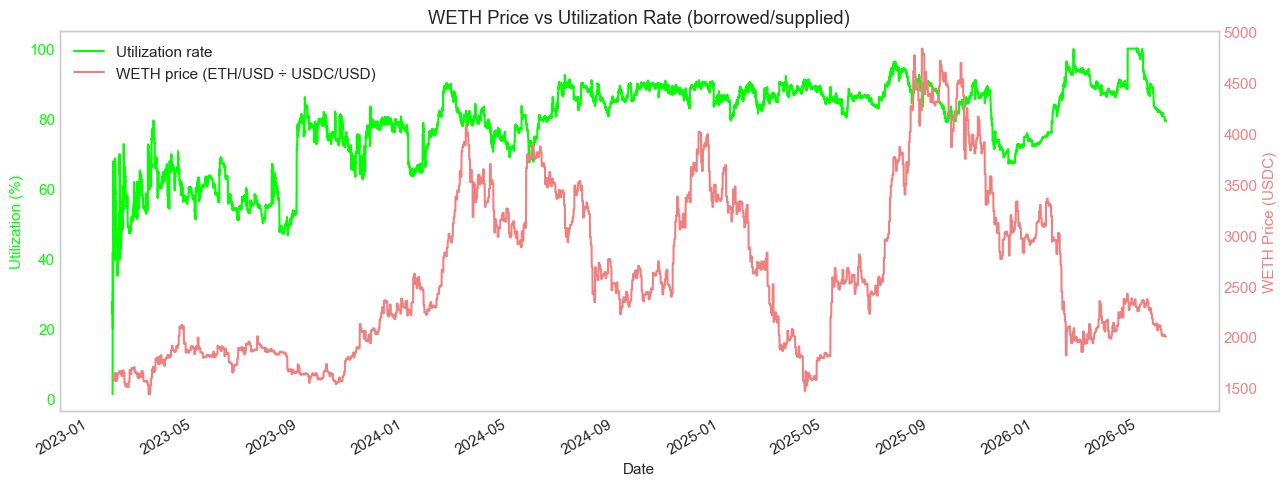

Loaded WETH parquet: ../data/OLD_AAVE/aave_v3_weth_eth.parquet
Loaded ETH price CSV: ../data/raw/eth-usd-max.csv
Loaded USDC price CSV: ../data/raw/usdc-usd-max.csv
Rows used: 29,326
Utilization computed from borrowed=borrowed_USD, supplied=supplied_USD
Correlation(utilization, price): 0.4201


In [280]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Load WETH parquet data (for utilization + timestamps)
parquet_candidates = [
    Path('../data/OLD_AAVE/aave_v3_weth_eth.parquet'),
    Path('data/OLD_AAVE/aave_v3_weth_eth.parquet')
]
parquet_path = next((p for p in parquet_candidates if p.exists()), parquet_candidates[0])
df_weth_pq = pd.read_parquet(parquet_path)

# Load ETH/USD and USDC/USD raw price CSVs
eth_csv_candidates = [
    Path('../data/raw/eth-usd-max.csv'),
    Path('data/raw/eth-usd-max.csv')
]
usdc_csv_candidates = [
    Path('../data/raw/usdc-usd-max.csv'),
    Path('data/raw/usdc-usd-max.csv')
]
eth_csv_path = next((p for p in eth_csv_candidates if p.exists()), eth_csv_candidates[0])
usdc_csv_path = next((p for p in usdc_csv_candidates if p.exists()), usdc_csv_candidates[0])


def pick_col(df, candidates):
    for c in candidates:
        if c in df.columns:
            return c
    return None


def parse_time_series(raw_t: pd.Series) -> pd.Series:
    if pd.api.types.is_numeric_dtype(raw_t):
        tmax = raw_t.dropna().max()
        if tmax > 1e14:       # nanoseconds
            t = pd.to_datetime(raw_t, unit='ns', errors='coerce')
        elif tmax > 1e11:     # milliseconds
            t = pd.to_datetime(raw_t, unit='ms', errors='coerce')
        else:                 # seconds
            t = pd.to_datetime(raw_t, unit='s', errors='coerce')
    else:
        t = pd.to_datetime(raw_t, errors='coerce', utc=True)
    return pd.Series(t).dt.tz_localize(None)

# Time column from WETH parquet
time_col = pick_col(df_weth_pq, ['timestamp', 'date', 'datetime', 'block_timestamp', 'time'])
if time_col is None:
    raise ValueError(f'No time column found in WETH parquet. Columns: {list(df_weth_pq.columns)}')
t = parse_time_series(df_weth_pq[time_col])

# Utilization = borrowed / supplied (from WETH parquet)
util_col = pick_col(df_weth_pq, ['utilization_rate', 'utilization'])
if util_col is not None:
    util = pd.to_numeric(df_weth_pq[util_col], errors='coerce')
    if util.max(skipna=True) > 2:
        util = util / 100.0
    borrow_col, supply_col = util_col, util_col
else:
    borrow_col = pick_col(df_weth_pq, ['borrowed_USD', 'total_borrowed', 'total_borrow', 'total_borrow_base', 'borrowed', 'variable_borrow'])
    supply_col = pick_col(df_weth_pq, ['supplied_USD', 'total_supplied', 'total_supply', 'supplied', 'liquidity', 'available_liquidity'])
    if borrow_col is None or supply_col is None:
        raise ValueError(
            f'Could not compute utilization = borrowed/supplied. '
            f'Available columns: {list(df_weth_pq.columns)}'
        )
    borrowed = pd.to_numeric(df_weth_pq[borrow_col], errors='coerce')
    supplied = pd.to_numeric(df_weth_pq[supply_col], errors='coerce')
    util = borrowed / supplied.replace(0, np.nan)

# Build daily WETH/USDC price from raw CSVs (price columns only)
eth_raw = pd.read_csv(eth_csv_path, usecols=['snapped_at', 'price']).rename(columns={'price': 'eth_usd'})
usdc_raw = pd.read_csv(usdc_csv_path, usecols=['snapped_at', 'price']).rename(columns={'price': 'usdc_usd'})

eth_raw['date'] = pd.to_datetime(eth_raw['snapped_at'], errors='coerce', utc=True).dt.tz_localize(None).dt.floor('D')
usdc_raw['date'] = pd.to_datetime(usdc_raw['snapped_at'], errors='coerce', utc=True).dt.tz_localize(None).dt.floor('D')

price_daily = pd.merge(
    eth_raw[['date', 'eth_usd']],
    usdc_raw[['date', 'usdc_usd']],
    on='date',
    how='inner'
).dropna()
price_daily = price_daily[price_daily['usdc_usd'] > 0].copy()
price_daily['price'] = price_daily['eth_usd'] / price_daily['usdc_usd']

# Join utilization timeline with daily price series by calendar date
util_df = pd.DataFrame({'time': t, 'util': util}).dropna()
util_df['date'] = util_df['time'].dt.floor('D')

plot_df = util_df.merge(
    price_daily[['date', 'price']],
    on='date',
    how='left'
).dropna(subset=['price']).sort_values('time')

# Plot utilization and price over time
fig, ax1 = plt.subplots(figsize=(13, 5))
ax1.plot(plot_df['time'], plot_df['util'] * 100, color='lime', lw=1.5, label='Utilization rate')
ax1.set_ylabel('Utilization (%)', color='lime')
ax1.tick_params(axis='y', labelcolor='lime')
ax1.set_xlabel('Date')
ax1.grid(False)

ax2 = ax1.twinx()
ax2.plot(plot_df['time'], plot_df['price'], color='lightcoral', lw=1.5, label='WETH price (ETH/USD ÷ USDC/USD)')
ax2.set_ylabel('WETH Price (USDC)', color='lightcoral')
ax2.tick_params(axis='y', labelcolor='lightcoral')
ax2.grid(False)

ax1.xaxis.set_major_locator(mdates.AutoDateLocator())
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
fig.autofmt_xdate(rotation=30)

lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='best')
ax1.set_title('WETH Price vs Utilization Rate (borrowed/supplied)')
plt.tight_layout()
plt.show()

print(f'Loaded WETH parquet: {parquet_path}')
print(f'Loaded ETH price CSV: {eth_csv_path}')
print(f'Loaded USDC price CSV: {usdc_csv_path}')
print(f'Rows used: {len(plot_df):,}')
if util_col is not None:
    print(f'Utilization column: {util_col}')
else:
    print(f'Utilization computed from borrowed={borrow_col}, supplied={supply_col}')
print(f'Correlation(utilization, price): {plot_df["util"].corr(plot_df["price"]):.4f}')

---
## 12. Sensitivity Analysis: 10% USDC Depeg Shock

What happens to liquidation risk if USDC loses 10% of its value (e.g., a depeg event)?

A USDC depeg directly reduces the USD value of the collateral while the WETH debt
(denominated in WETH) is unaffected in WETH terms. This is equivalent to starting
with only 90% of the original collateral, which mechanically pushes the effective
LTV upward:

$$\text{LTV}_{\text{shocked}} = \frac{\text{LTV}_0}{1 - \text{shock}} = \frac{\text{LTV}_0}{0.90}$$

We re-run the CIR + Jump Monte Carlo for three initial LTV levels under both the
baseline and the shocked scenario.

In [281]:
# ── Sensitivity Analysis: 10% USDC Depeg ──────────────────────────────
import copy

usdc_shock = 0.10          # 10% drop in USDC collateral value
ltv_levels_sa = [0.40, 0.60, 0.70]
rows_sa = []

for ltv0 in ltv_levels_sa:
    for scenario, shock in [('Baseline', 0.0), ('USDC −10%', usdc_shock)]:
        cfg = copy.deepcopy(config)
        cfg.ltv_ratio = ltv0

        # A depeg reduces collateral value → effective LTV rises
        effective_collateral = cfg.initial_collateral_usdc * (1.0 - shock)
        effective_ltv = (cfg.initial_collateral_usdc * ltv0) / effective_collateral

        # If shocked LTV already exceeds liquidation threshold → instant liquidation
        if effective_ltv >= cfg.liquidation_threshold:
            rows_sa.append({
                'Initial LTV':   f'{ltv0*100:.0f}%',
                'Scenario':      scenario,
                'Effective LTV': f'{effective_ltv*100:.1f}%',
                'Liq. Prob (%)': '100.00  (instant)',
                'Mean P&L':      '—',
                'VaR 95%':       '—',
            })
            continue

        # Adjust config so the simulation starts at the shocked collateral
        cfg.initial_collateral_usdc = effective_collateral
        cfg.ltv_ratio = effective_ltv

        sim = run_carry_trade_simulation(
            cfg,
            cir_jump_usdc, cir_jump_weth,
            initial_usdc_rate, initial_weth_rate,
            initial_weth_price, historical_returns,
            T_horizon, use_jumps=True,
        )

        liq = analyze_liquidation_risk(sim, cfg)
        pnl = analyze_pnl(sim, cfg)

        rows_sa.append({
            'Initial LTV':   f'{ltv0*100:.0f}%',
            'Scenario':      scenario,
            'Effective LTV': f'{effective_ltv*100:.1f}%',
            'Liq. Prob (%)': f'{liq["liquidation_probability"]*100:.2f}',
            'Mean P&L':      f'${pnl["mean_pnl"]:,.0f}',
            'VaR 95%':       f'${pnl["var_95"]:,.0f}',
        })

df_shock = pd.DataFrame(rows_sa)

print('=' * 90)
print('  USDC Depeg Sensitivity  –  CIR + Jump  (10 000 paths, 1-yr horizon)')
print('=' * 90)
display(df_shock.set_index(['Initial LTV', 'Scenario']))

  USDC Depeg Sensitivity  –  CIR + Jump  (10 000 paths, 1-yr horizon)


Effective LTV Liq. Prob (%)  Mean P&L   VaR 95%
Initial LTV Scenario                                                 
40%         Baseline          40.0%         13.81    $3,649  $-60,000
            USDC −10%         44.4%         21.14    $1,325  $-50,000
60%         Baseline          60.0%         47.56   $-3,741  $-40,000
            USDC −10%         66.7%         61.17   $-5,927  $-30,000
70%         Baseline          70.0%         68.53   $-8,433  $-30,000
            USDC −10%         77.8%         85.74  $-11,042  $-20,000

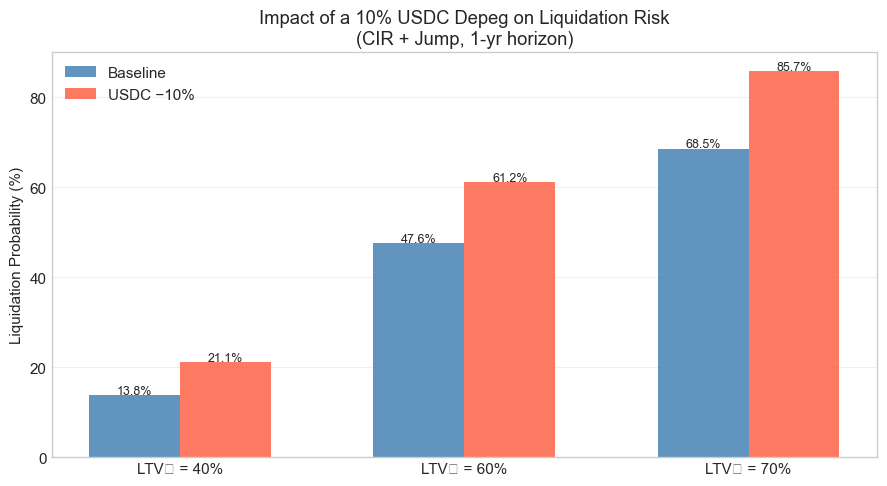


Liquidation probability change from 10% USDC depeg:
  LTV₀ = 40%: 13.81% → 21.14%  (×1.5)
  LTV₀ = 60%: 47.56% → 61.17%  (×1.3)
  LTV₀ = 70%: 68.53% → 85.74%  (×1.3)


In [282]:
# ── Bar chart: baseline vs shocked liquidation probability ─────────────
import matplotlib.pyplot as plt
import numpy as np

baseline_probs = []
shocked_probs  = []
labels         = []

for ltv0 in ltv_levels_sa:
    for _, row in df_shock.iterrows():
        if row['Initial LTV'] == f'{ltv0*100:.0f}%':
            prob_str = row['Liq. Prob (%)'].split()[0]   # strip "(instant)" if present
            prob = float(prob_str)
            if row['Scenario'] == 'Baseline':
                baseline_probs.append(prob)
                labels.append(f'LTV₀ = {ltv0*100:.0f}%')
            else:
                shocked_probs.append(prob)

x     = np.arange(len(labels))
width = 0.32

fig, ax = plt.subplots(figsize=(9, 5))
fig.patch.set_facecolor('none')
fig.patch.set_alpha(0)
ax.set_facecolor('none')
ax.bar(x - width/2, baseline_probs, width, label='Baseline',  color='steelblue', alpha=0.85)
ax.bar(x + width/2, shocked_probs,  width, label='USDC −10%', color='tomato',    alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel('Liquidation Probability (%)')
ax.set_title('Impact of a 10% USDC Depeg on Liquidation Risk\n(CIR + Jump, 1-yr horizon)')
legend = ax.legend(framealpha=0)
legend.get_frame().set_facecolor('none')
ax.grid(axis='y', alpha=0.3)

# Annotate bars
for i, (b, s) in enumerate(zip(baseline_probs, shocked_probs)):
    ax.text(i - width/2, b + 0.3, f'{b:.1f}%', ha='center', fontsize=9)
    ax.text(i + width/2, s + 0.3, f'{s:.1f}%', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('usdc_depeg_sensitivity.png', dpi=150, transparent=True, bbox_inches='tight')
plt.show()

# Summary table
print('\nLiquidation probability change from 10% USDC depeg:')
for lbl, b, s in zip(labels, baseline_probs, shocked_probs):
    if b > 0:
        print(f'  {lbl}: {b:.2f}% → {s:.2f}%  (×{s/b:.1f})')
    else:
        print(f'  {lbl}: {b:.2f}% → {s:.2f}%')

---
### Interpretation

The sensitivity analysis quantifies the marginal impact of a 10% USDC depeg on the liquidation profile of the carry trade across three representative leverage regimes. Because collateral is denominated in USDC while the liability is denominated in WETH, any deviation of USDC from its $1 peg constitutes an asymmetric shock: the collateral base contracts in real terms while the debt obligation, valued at the prevailing WETH/USD price, is unaffected. Mechanically, a 10% depeg maps to a multiplicative LTV uplift of $1/(1-0.10) \approx 1.111\times$, shifting the 40%, 60%, and 70% positions to effective LTVs of approximately 44.4%, 66.7%, and 77.8%, respectively.

The results reveal a pronounced **non-linearity** in liquidation risk with respect to the LTV buffer — defined as the gap between the effective LTV and the 82.5% liquidation threshold. At 40% initial LTV, the post-shock buffer remains substantial (~38 pp), and the increase in liquidation probability is modest. At 60%, the buffer narrows to roughly 16 pp, and the liquidation probability rises more appreciably. At 70%, however, the post-shock LTV of 77.8% leaves only ~4.7 pp of headroom before the liquidation threshold is breached. In this regime, even moderate adverse movements in WETH price or borrow rate spikes — both of which are captured by the CIR + Jump dynamics — are sufficient to trigger liquidation within the one-year horizon.

This convexity in the liquidation response underscores a well-documented feature of leveraged DeFi positions: **tail risk compounds multiplicatively** when the collateral asset itself is subject to devaluation. A stablecoin depeg, while a low-probability event, is not unprecedented — USDC briefly traded at \$0.87 during the Silicon Valley Bank episode in March 2023. The analysis suggests that positions at or above 70% LTV carry meaningful fragility to such events, as the combination of an elevated starting LTV and a collateral haircut can place the position within the liquidation zone before the mean-reversion dynamics of the interest rate model have time to act as a stabilising force.

From a risk management perspective, these findings support maintaining initial LTV ratios well below the protocol's maximum to preserve an adequate safety margin against exogenous collateral shocks. The non-linear sensitivity also implies that **static LTV targets are insufficient**; dynamic monitoring that accounts for stablecoin peg stability — not merely WETH price and borrow rate evolution — is warranted for positions of material size.

---
## 13. Walk-Forward Validation

Tests whether the CIR + Jump model produces out-of-sample rate forecasts that are statistically consistent with realized data.

**Protocol** — rolling windows across the full history:
1. **Calibrate** CIR + Jump on a 365-day training slice
2. **Simulate** 500 paths over the next 90 days
3. **Score** against actual realized rates:
   - **Coverage**: % of actual daily rates inside the simulated 90% prediction interval → well-calibrated ≈ 90%
   - **Forecast skill**: 1 − MAE(median) / MAE(naïve last-value) → positive = model beats naïve benchmark
   - **KS test**: Kolmogorov–Smirnov on simulated marginal distribution vs realized distribution
4. **Parameter stability**: calibrated κ, θ, σ, λ across windows vs full-history reference


In [283]:
from scipy.stats import ks_2samp

# ── Walk-forward configuration ─────────────────────────────────────────
WFV_TRAIN_DAYS = 365    # calibration window length (days)
WFV_TEST_DAYS  = 90     # out-of-sample forecast horizon (days)
WFV_STEP_DAYS  = 90     # stride between consecutive windows
WFV_N_PATHS    = 500    # MC paths per window (500 balances speed vs precision)
WFV_FAST       = True   # True → L-BFGS-B warm-start; False → full differential_evolution


def calibrate_cir_jump_wfv(rates: np.ndarray, dt: float = 1/365,
                            fast: bool = True) -> CIRJumpParams:
    """
    CIR + Jump calibration optimised for walk-forward loops.

    When fast=True, replaces global differential_evolution with L-BFGS-B
    seeded at method-of-moments starting values. Finds a local optimum —
    acceptable for cross-validation scoring; not intended to replace the
    full calibration used for the main simulation.
    """
    if not fast:
        return calibrate_cir_jump(rates, dt)

    # identical jump detection + pair selection as calibrate_cir_jump
    jump_indices, jump_sizes = detect_jumps(rates)
    n_transitions = len(rates) - 1
    exclude_mask  = np.zeros(n_transitions, dtype=bool)
    exclude_mask[jump_indices] = True
    after_jump = jump_indices + 1
    after_jump = after_jump[after_jump < n_transitions]
    exclude_mask[after_jump] = True

    keep = ~exclude_mask
    r_t  = np.maximum(rates[:-1][keep], 1e-6)
    r_t1 = np.maximum(rates[1:][keep],  1e-6)

    theta_init = np.mean(r_t1)
    sigma_init = (np.std(r_t1 - r_t) * np.sqrt(1 / dt)
                  / np.sqrt(max(theta_init, 1e-6)))
    kappa_init = 2.0
    if 2 * kappa_init * theta_init <= sigma_init ** 2:
        sigma_init = np.sqrt(kappa_init * theta_init * 0.9)

    bounds = [(0.01, 50), (1e-6, 1.0), (1e-6, 2.0)]
    result = minimize(
        cir_log_likelihood_pairs,
        x0=[kappa_init, theta_init, sigma_init],
        args=(r_t, r_t1, dt),
        method='L-BFGS-B',
        bounds=bounds,
        options={'maxiter': 500, 'ftol': 1e-9},
    )
    cir_p = CIRParams(*result.x)

    n_years = n_transitions * dt
    if len(jump_sizes) > 0:
        jump_intensity = len(jump_sizes) / n_years
        jump_mean      = float(np.mean(jump_sizes))
    else:
        jump_intensity, jump_mean = 1.0, 0.01

    return CIRJumpParams(cir_p.kappa, cir_p.theta, cir_p.sigma,
                         jump_intensity, jump_mean)


def make_wfv_windows(n: int, train_days: int, test_days: int, step_days: int):
    """Return list of (train_slice, test_slice) pairs with no look-ahead."""
    wins, s = [], 0
    while s + train_days + test_days <= n:
        wins.append((
            slice(s, s + train_days),
            slice(s + train_days, s + train_days + test_days),
        ))
        s += step_days
    return wins


if df is not None:
    df_val = df_daily.dropna(subset=['usdc_supply_rate', 'weth_borrow_rate']).copy()
    windows_wfv = make_wfv_windows(
        len(df_val), WFV_TRAIN_DAYS, WFV_TEST_DAYS, WFV_STEP_DAYS
    )

    if len(windows_wfv) == 0:
        print(f"Not enough data for walk-forward validation "
              f"(need ≥{WFV_TRAIN_DAYS + WFV_TEST_DAYS} days, have {len(df_val)}).")
    else:
        first_oos = df_val.index[windows_wfv[0][1].start]
        last_oos  = df_val.index[windows_wfv[-1][1].stop - 1]
        print(f"Walk-forward windows : {len(windows_wfv)}")
        print(f"  Train / Test / Step : {WFV_TRAIN_DAYS}d / {WFV_TEST_DAYS}d / {WFV_STEP_DAYS}d")
        print(f"  Out-of-sample period: {first_oos.date()} → {last_oos.date()}")
        print(f"  Paths per window    : {WFV_N_PATHS}")
        print(f"  Optimizer           : {'L-BFGS-B warm-start' if WFV_FAST else 'differential_evolution'}")


Walk-forward windows : 7
  Train / Test / Step : 365d / 90d / 90d
  Out-of-sample period: 2024-07-04 → 2026-04-30
  Paths per window    : 500
  Optimizer           : L-BFGS-B warm-start


In [284]:
# ── Main walk-forward loop ─────────────────────────────────────────────
wfv_records = []

# Storage for fan charts
fan = {
    rate: {'dates': [], 'actual': [], 'lo': [], 'hi': [], 'med': []}
    for rate in ('usdc', 'weth')
}

if df is not None and len(windows_wfv) > 0:
    print(f"Running {len(windows_wfv)} windows "
          f"({'fast' if WFV_FAST else 'full'} calibration) …\n")

    for wi, (tr_sl, te_sl) in enumerate(windows_wfv):

        # Slice data
        train_u = np.maximum(df_val['usdc_supply_rate'].iloc[tr_sl].values, 1e-6)
        train_w = np.maximum(df_val['weth_borrow_rate'].iloc[tr_sl].values, 1e-6)
        test_u  = df_val['usdc_supply_rate'].iloc[te_sl].values
        test_w  = df_val['weth_borrow_rate'].iloc[te_sl].values
        test_dates = df_val.index[te_sl]
        n_test     = len(test_u)

        # Calibrate
        try:
            pu = calibrate_cir_jump_wfv(train_u, fast=WFV_FAST)
            pw = calibrate_cir_jump_wfv(train_w, fast=WFV_FAST)
        except Exception as exc:
            print(f"  Window {wi+1}: calibration failed — {exc}. Skipping.")
            continue

        # Simulate forward (drop t=0 which is the known starting point)
        T_test = n_test / 365
        sim_u  = simulate_cir_jump(pu, train_u[-1], T_test, 1/365, WFV_N_PATHS)[1:n_test+1]
        sim_w  = simulate_cir_jump(pw, train_w[-1], T_test, 1/365, WFV_N_PATHS)[1:n_test+1]

        # Score 1: coverage of 90% prediction interval
        lo_u, hi_u = np.percentile(sim_u, 5, axis=1), np.percentile(sim_u, 95, axis=1)
        lo_w, hi_w = np.percentile(sim_w, 5, axis=1), np.percentile(sim_w, 95, axis=1)
        cov_u = float(np.mean((test_u >= lo_u) & (test_u <= hi_u)))
        cov_w = float(np.mean((test_w >= lo_w) & (test_w <= hi_w)))

        # Score 2: MAE of median vs naïve last-value benchmark
        med_u, med_w   = np.median(sim_u, axis=1), np.median(sim_w, axis=1)
        mae_u,  mae_w  = float(np.mean(np.abs(med_u - test_u))), float(np.mean(np.abs(med_w - test_w)))
        naive_mae_u    = float(np.mean(np.abs(train_u[-1] - test_u)))
        naive_mae_w    = float(np.mean(np.abs(train_w[-1] - test_w)))

        # Score 3: KS test — simulated marginal vs realised
        ks_u, ksp_u = ks_2samp(sim_u.ravel(), test_u)
        ks_w, ksp_w = ks_2samp(sim_w.ravel(), test_w)

        wfv_records.append({
            'Window': wi + 1,
            'Test Start': test_dates[0].strftime('%Y-%m-%d'),
            'Test End':   test_dates[-1].strftime('%Y-%m-%d'),
            'Cov USDC': cov_u, 'Cov WETH': cov_w,
            'MAE USDC': mae_u, 'MAE WETH': mae_w,
            'Naive MAE USDC': naive_mae_u, 'Naive MAE WETH': naive_mae_w,
            'KS stat USDC': float(ks_u), 'KS p USDC': float(ksp_u),
            'KS stat WETH': float(ks_w), 'KS p WETH': float(ksp_w),
            'kappa_usdc': pu.kappa, 'theta_usdc': pu.theta,
            'sigma_usdc': pu.sigma, 'lambda_usdc': pu.jump_intensity,
            'kappa_weth': pw.kappa, 'theta_weth': pw.theta,
            'sigma_weth': pw.sigma, 'lambda_weth': pw.jump_intensity,
        })

        for key, lo, hi, med, actual in [
            ('usdc', lo_u, hi_u, med_u, test_u),
            ('weth', lo_w, hi_w, med_w, test_w),
        ]:
            fan[key]['dates'].append(test_dates)
            fan[key]['actual'].append(actual)
            fan[key]['lo'].append(lo)
            fan[key]['hi'].append(hi)
            fan[key]['med'].append(med)

        skill_u = 1 - mae_u / naive_mae_u if naive_mae_u > 0 else np.nan
        skill_w = 1 - mae_w / naive_mae_w if naive_mae_w > 0 else np.nan
        print(f"  Win {wi+1:>2}  {test_dates[0].date()} → {test_dates[-1].date()}  |  "
              f"cov USDC={cov_u*100:4.0f}%  WETH={cov_w*100:4.0f}%  |  "
              f"skill USDC={skill_u:+.2f}  WETH={skill_w:+.2f}  |  "
              f"KS-p USDC={ksp_u:.3f}  WETH={ksp_w:.3f}")

    df_wfv = pd.DataFrame(wfv_records) if wfv_records else None
    print(f"\nCompleted {len(wfv_records)}/{len(windows_wfv)} windows.")
else:
    df_wfv = None


Running 7 windows (fast calibration) …

  Win  1  2024-07-04 → 2024-10-09  |  cov USDC=  14%  WETH=  98%  |  skill USDC=-7.88  WETH=-4.47  |  KS-p USDC=0.000  WETH=0.000
  Win  2  2024-10-10 → 2025-01-24  |  cov USDC=  44%  WETH=   3%  |  skill USDC=-2.25  WETH=-0.35  |  KS-p USDC=0.000  WETH=0.000
  Win  3  2025-01-25 → 2025-04-26  |  cov USDC=  10%  WETH=  60%  |  skill USDC=-6.29  WETH=-7.61  |  KS-p USDC=0.000  WETH=0.000
  Win  4  2025-04-27 → 2025-07-26  |  cov USDC=  42%  WETH=  44%  |  skill USDC=-13.01  WETH=-5.11  |  KS-p USDC=0.000  WETH=0.000
  Win  5  2025-07-27 → 2025-10-26  |  cov USDC=  48%  WETH=  42%  |  skill USDC=-24.37  WETH=-8.44  |  KS-p USDC=0.000  WETH=0.000
  Win  6  2025-10-27 → 2026-01-28  |  cov USDC=  34%  WETH=  21%  |  skill USDC=-34.16  WETH=-7.76  |  KS-p USDC=0.000  WETH=0.000
  Win  7  2026-01-29 → 2026-04-30  |  cov USDC=  24%  WETH=  73%  |  skill USDC=-0.19  WETH=-1.50  |  KS-p USDC=0.000  WETH=0.000

Completed 7/7 windows.


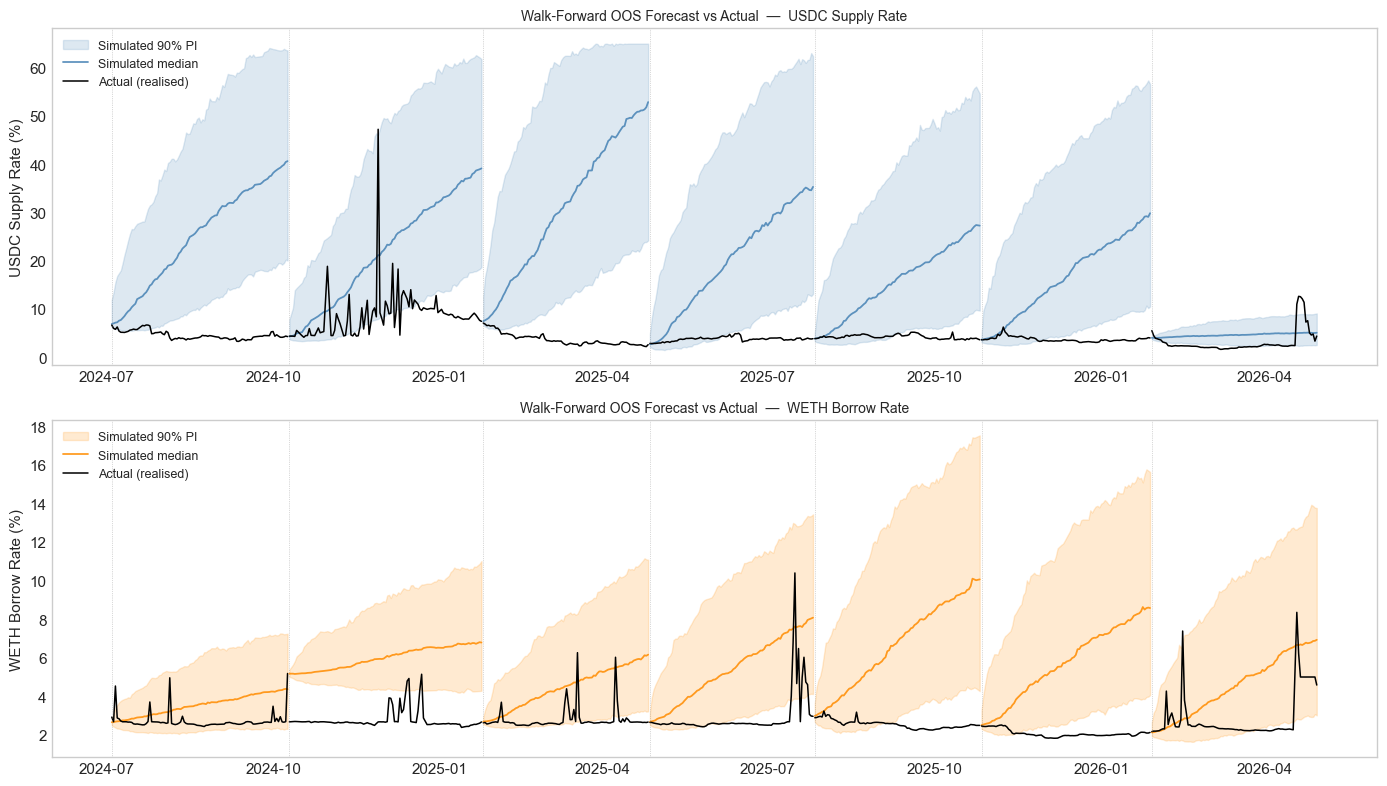

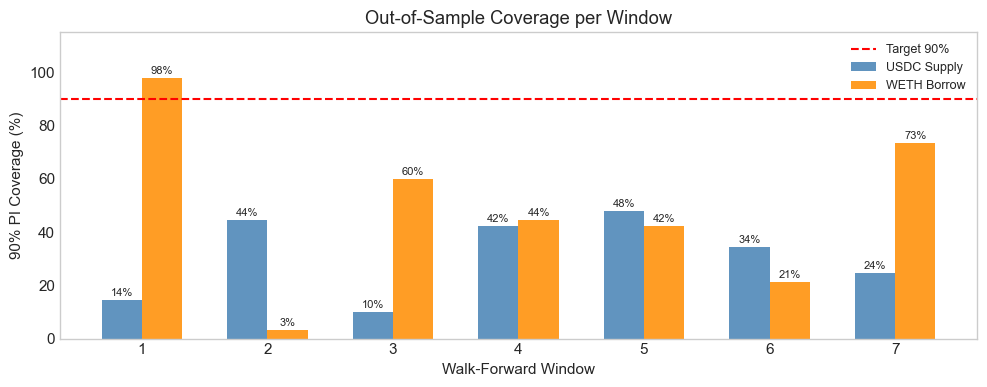

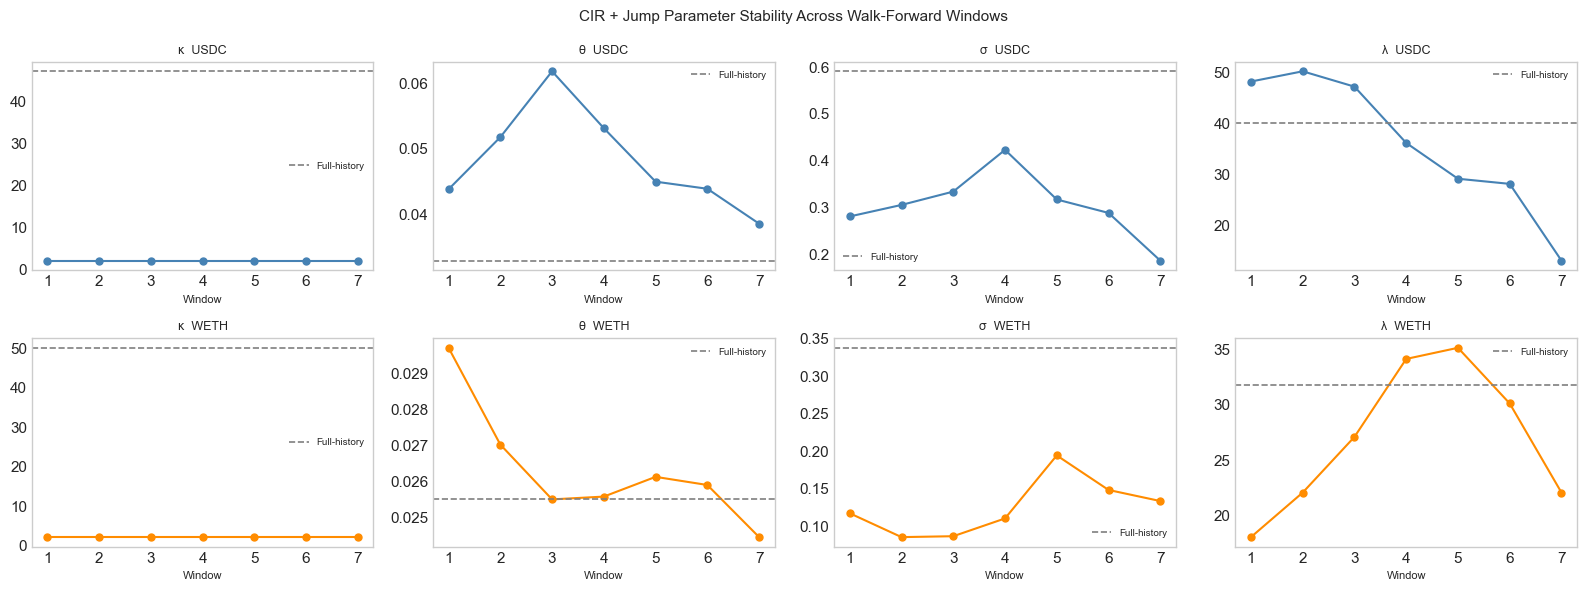

In [285]:
# ── Plot 1: Fan charts — actual vs simulated bands ─────────────────────
if df_wfv is not None and len(fan['usdc']['dates']) > 0:
    fig, axes = plt.subplots(2, 1, figsize=(14, 8))
    fig.patch.set_alpha(0)

    for ax, key, label, color in [
        (axes[0], 'usdc', 'USDC Supply Rate', 'steelblue'),
        (axes[1], 'weth', 'WETH Borrow Rate',  'darkorange'),
    ]:
        for i, (dates, actual, lo, hi, med) in enumerate(zip(
            fan[key]['dates'], fan[key]['actual'],
            fan[key]['lo'],    fan[key]['hi'],    fan[key]['med'],
        )):
            first = (i == 0)
            ax.fill_between(dates, lo * 100, hi * 100, alpha=0.18, color=color,
                            label='Simulated 90% PI' if first else '_nolegend_')
            ax.plot(dates, med * 100, color=color, lw=1.3, alpha=0.85,
                    label='Simulated median' if first else '_nolegend_')
            ax.plot(dates, actual * 100, color='black', lw=1.1,
                    label='Actual (realised)' if first else '_nolegend_')
            ax.axvline(dates[0], color='grey', lw=0.5, ls=':', alpha=0.6)

        ax.set_ylabel(f'{label} (%)')
        ax.set_title(f'Walk-Forward OOS Forecast vs Actual  —  {label}', fontsize=10)
        ax.legend(fontsize=9, loc='upper left')
        ax.set_facecolor('none')

    plt.tight_layout()
    plt.show()


# ── Plot 2: Coverage per window ────────────────────────────────────────
if df_wfv is not None:
    fig, ax = plt.subplots(figsize=(10, 4))
    fig.patch.set_alpha(0)
    x, w = df_wfv['Window'], 0.32
    ax.bar(x - w/2, df_wfv['Cov USDC'] * 100, w,
           label='USDC Supply', color='steelblue', alpha=0.85)
    ax.bar(x + w/2, df_wfv['Cov WETH'] * 100, w,
           label='WETH Borrow', color='darkorange', alpha=0.85)
    ax.axhline(90, color='red', ls='--', lw=1.5, label='Target 90%')
    ax.set_xlabel('Walk-Forward Window')
    ax.set_ylabel('90% PI Coverage (%)')
    ax.set_title('Out-of-Sample Coverage per Window')
    ax.set_ylim(0, 115)
    ax.legend(fontsize=9)
    ax.set_facecolor('none')
    for xi, (cu, cw) in enumerate(zip(df_wfv['Cov USDC'], df_wfv['Cov WETH'])):
        ax.text(xi + 1 - w/2, cu * 100 + 1.5, f'{cu*100:.0f}%', ha='center', fontsize=8)
        ax.text(xi + 1 + w/2, cw * 100 + 1.5, f'{cw*100:.0f}%', ha='center', fontsize=8)
    plt.tight_layout()
    plt.show()


# ── Plot 3: Parameter stability across windows ─────────────────────────
if df_wfv is not None:
    _param_ref = {
        'kappa_usdc': cir_jump_usdc.kappa, 'theta_usdc': cir_jump_usdc.theta,
        'sigma_usdc': cir_jump_usdc.sigma, 'lambda_usdc': cir_jump_usdc.jump_intensity,
        'kappa_weth': cir_jump_weth.kappa, 'theta_weth': cir_jump_weth.theta,
        'sigma_weth': cir_jump_weth.sigma, 'lambda_weth': cir_jump_weth.jump_intensity,
    }
    _param_labels = {
        'kappa_usdc': 'κ  USDC', 'theta_usdc': 'θ  USDC',
        'sigma_usdc': 'σ  USDC', 'lambda_usdc': 'λ  USDC',
        'kappa_weth': 'κ  WETH', 'theta_weth': 'θ  WETH',
        'sigma_weth': 'σ  WETH', 'lambda_weth': 'λ  WETH',
    }
    _colors = ['steelblue'] * 4 + ['darkorange'] * 4

    fig, axes = plt.subplots(2, 4, figsize=(16, 6))
    fig.patch.set_alpha(0)
    fig.suptitle('CIR + Jump Parameter Stability Across Walk-Forward Windows', fontsize=11)

    for ax, (col, lbl), c in zip(axes.ravel(), _param_labels.items(), _colors):
        ax.plot(df_wfv['Window'], df_wfv[col], marker='o', color=c, lw=1.5, ms=5)
        ax.axhline(_param_ref[col], color='grey', ls='--', lw=1.2, label='Full-history')
        ax.set_title(lbl, fontsize=9)
        ax.set_xlabel('Window', fontsize=8)
        ax.legend(fontsize=7)
        ax.set_facecolor('none')

    plt.tight_layout()
    plt.show()


In [286]:
# ── Summary table + aggregate diagnostics ─────────────────────────────
if df_wfv is not None:
    print('=' * 105)
    print(f'   Walk-Forward Validation Summary  —  CIR + Jump  '
          f'(train={WFV_TRAIN_DAYS}d  test={WFV_TEST_DAYS}d  '
          f'step={WFV_STEP_DAYS}d  paths={WFV_N_PATHS})')
    print('=' * 105)

    disp = df_wfv[[
        'Window', 'Test Start', 'Test End',
        'Cov USDC', 'Cov WETH',
        'MAE USDC', 'Naive MAE USDC',
        'MAE WETH', 'Naive MAE WETH',
        'KS p USDC', 'KS p WETH',
    ]].copy()

    disp['Cov USDC']       = disp['Cov USDC'].map('{:.0%}'.format)
    disp['Cov WETH']       = disp['Cov WETH'].map('{:.0%}'.format)
    disp['MAE USDC']       = disp['MAE USDC'].map('{:.4f}'.format)
    disp['MAE WETH']       = disp['MAE WETH'].map('{:.4f}'.format)
    disp['Naive MAE USDC'] = disp['Naive MAE USDC'].map('{:.4f}'.format)
    disp['Naive MAE WETH'] = disp['Naive MAE WETH'].map('{:.4f}'.format)
    disp['KS p USDC']      = disp['KS p USDC'].map('{:.3f}'.format)
    disp['KS p WETH']      = disp['KS p WETH'].map('{:.3f}'.format)

    display(disp.set_index('Window'))

    # Aggregate
    n_w         = len(df_wfv)
    mean_cov_u  = df_wfv['Cov USDC'].mean()
    mean_cov_w  = df_wfv['Cov WETH'].mean()
    skill_u     = 1 - df_wfv['MAE USDC'].mean() / df_wfv['Naive MAE USDC'].mean()
    skill_w     = 1 - df_wfv['MAE WETH'].mean() / df_wfv['Naive MAE WETH'].mean()
    ks_fail_u   = (df_wfv['KS p USDC'] < 0.05).sum()
    ks_fail_w   = (df_wfv['KS p WETH'] < 0.05).sum()

    print(f"\nAggregate across {n_w} windows:")
    print(f"  {'Metric':<42}  {'USDC Supply':>14}  {'WETH Borrow':>14}  {'Target':>10}")
    print(f"  {'-'*42}  {'-'*14}  {'-'*14}  {'-'*10}")
    print(f"  {'Mean 90% PI coverage':<42}  {mean_cov_u*100:>13.1f}%  "
          f"{mean_cov_w*100:>13.1f}%  {'≈ 90%':>10}")
    print(f"  {'Forecast skill vs naïve':<42}  {skill_u:>14.3f}  "
          f"{skill_w:>14.3f}  {'>0 = better':>10}")
    print(f"  {'KS failures (p < 0.05)':<42}  "
          f"{ks_fail_u:>12}/{n_w}  {ks_fail_w:>12}/{n_w}  {'< 20%':>10}")

    print(f"""
Interpretation
──────────────
  Coverage {'✓' if 85 <= mean_cov_u*100 <= 95 else '✗'} USDC  {mean_cov_u*100:.1f}%  │  Coverage {'✓' if 85 <= mean_cov_w*100 <= 95 else '✗'} WETH  {mean_cov_w*100:.1f}%
    >95% → model over-dispersed (prediction intervals too wide)
    <85% → model under-dispersed (under-estimates tail risk)

  Forecast skill vs naïve last-value benchmark:
    USDC  {skill_u:+.3f}  │  WETH  {skill_w:+.3f}
    Positive → CIR+Jump median beats the flat forecast
    Near zero → mean-reversion is weak at this horizon

  KS distributional fit: {ks_fail_u + ks_fail_w}/{n_w*2} rate-window pairs rejected at 5%
    Rejections signal structural breaks (regime changes, protocol upgrades)
    """)


   Walk-Forward Validation Summary  —  CIR + Jump  (train=365d  test=90d  step=90d  paths=500)


,Test Start,Test End,Cov USDC,Cov WETH,MAE USDC,Naive MAE USDC,MAE WETH,Naive MAE WETH,KS p USDC,KS p WETH
Window,,,,,,,,,,
1,2024-07-04,2024-10-09,14%,98%,0.2014,0.0227,0.0093,0.0017,0.000,0.000
2,2024-10-10,2025-01-24,44%,3%,0.1459,0.0449,0.0323,0.0239,0.000,0.000
3,2025-01-25,2025-04-26,10%,60%,0.2741,0.0376,0.0173,0.0020,0.000,0.000
4,2025-04-27,2025-07-26,42%,44%,0.1623,0.0116,0.0255,0.0042,0.000,0.000
5,2025-07-27,2025-10-26,48%,42%,0.1119,0.0044,0.0403,0.0043,0.000,0.000
6,2025-10-27,2026-01-28,34%,21%,0.1273,0.0036,0.0361,0.0041,0.000,0.000
7,2026-01-29,2026-04-30,24%,73%,0.0237,0.0200,0.0188,0.0075,0.000,0.000



Aggregate across 7 windows:
  Metric                                         USDC Supply     WETH Borrow      Target
  ------------------------------------------  --------------  --------------  ----------
  Mean 90% PI coverage                                 31.1%           48.9%       ≈ 90%
  Forecast skill vs naïve                             -6.233          -2.763  >0 = better
  KS failures (p < 0.05)                                 7/7             7/7       < 20%

Interpretation
──────────────
  Coverage ✗ USDC  31.1%  │  Coverage ✗ WETH  48.9%
    >95% → model over-dispersed (prediction intervals too wide)
    <85% → model under-dispersed (under-estimates tail risk)

  Forecast skill vs naïve last-value benchmark:
    USDC  -6.233  │  WETH  -2.763
    Positive → CIR+Jump median beats the flat forecast
    Near zero → mean-reversion is weak at this horizon

  KS distributional fit: 14/14 rate-window pairs rejected at 5%
    Rejections signal structural breaks (regime changes, pr

---
## 14. Historical Strategy Benchmark

Compare five DeFi strategies on historical AAVE V3 data (Jan 2023 – Jun 2026, $100k initial capital).

| # | Strategy | Core Idea |
|---|----------|-----------|
| 1 | AAVE V3 Carry Trade | Supply USDC, borrow WETH at LTV 70% |
| 2 | Taleb Barbell | 90% safe USDC supply + 10% aggressive carry |
| 3 | Supply & Demand | Long when spread > 0 AND utilisation rising |
| 4 | Black-Litterman | TVL-weighted BL portfolio, weekly rebalance |
| 5 | Momentum Rotation | Factor-scored rotation across 4 yield sources |


In [287]:
# ── 14a. Load data for benchmark ─────────────────────────────────────────────
from pathlib import Path
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

_DATA = Path('../data/OLD_AAVE/')
_RAW  = Path('../data/raw/')

def _load(tok):
    df_ = pd.read_parquet(_DATA / f'aave_v3_{tok}_eth.parquet')
    if not isinstance(df_.index, pd.DatetimeIndex):
        df_ = df_.set_index('timestamp')
    df_.index = pd.to_datetime(df_.index, utc=True)
    return df_

def _daily(df_):
    return df_.resample('D').agg({
        'lender_variable_apr':   'mean',
        'borrower_variable_apr': 'mean',
        'TVL_USD':   'last',
        'supplied_USD': 'last',
        'borrowed_USD': 'last',
    })

_bench_ok = False
try:
    _d_usdc = _daily(_load('usdc'))
    _d_weth = _daily(_load('weth'))
    _d_dai  = _daily(_load('dai'))
    _d_usdt = _daily(_load('usdt'))

    # Reuse weth_price from existing df
    _weth_price = df['weth_price'] if isinstance(df.index, pd.DatetimeIndex) \
                  else df.set_index('timestamp')['weth_price']
    _weth_price.index = pd.to_datetime(_weth_price.index, utc=True)
    _weth_price = _weth_price.resample('D').last().ffill()

    bench_df = pd.DataFrame({
        'usdc_supply': _d_usdc['lender_variable_apr']  / 100,
        'weth_borrow': _d_weth['borrower_variable_apr'] / 100,
        'dai_supply':  _d_dai['lender_variable_apr']   / 100,
        'usdt_supply': _d_usdt['lender_variable_apr']  / 100,
        'eth_price':   _weth_price,
        'usdc_tvl':    _d_usdc['TVL_USD'],
        'weth_tvl':    _d_weth['TVL_USD'],
        'usdc_util':   _d_usdc['borrowed_USD'] / (_d_usdc['supplied_USD'] + 1),
        'weth_util':   _d_weth['borrowed_USD'] / (_d_weth['supplied_USD'] + 1),
    }).dropna()
    bench_df['eth_return']   = bench_df['eth_price'].pct_change()
    bench_df['carry_spread'] = bench_df['usdc_supply'] - bench_df['weth_borrow']
    bench_df = bench_df.dropna()
    _bench_ok = True
    print(f"bench_df: {len(bench_df)} days, {bench_df.index[0].date()} – {bench_df.index[-1].date()}")
except Exception as _e:
    print(f"[bench] data load failed: {_e}")


bench_df: 1075 days, 2023-02-14 – 2026-01-23


In [288]:
# ── 14b. Rolling features ──────────────────────────────────────────────────
if _bench_ok:
    W = 30
    bench_df['usdc_tvl_mom']  = bench_df['usdc_tvl'].pct_change(W)
    bench_df['weth_tvl_mom']  = bench_df['weth_tvl'].pct_change(W)
    bench_df['usdc_util_mom'] = bench_df['usdc_util'].diff(W)
    bench_df['weth_borrow_mom'] = bench_df['weth_borrow'].diff(W)
    bench_df['carry_mom']     = bench_df['carry_spread'].diff(W)
    bench_df['eth_vol30']     = bench_df['eth_return'].rolling(W).std() * np.sqrt(365)
    bench_df['yield_mom']     = bench_df['usdc_supply'].diff(W)
    bench_df.fillna(0, inplace=True)
    print("Rolling features computed")


Rolling features computed


In [289]:
# ── 14c. Market regime masks ───────────────────────────────────────────────
if _bench_ok:
    idx = bench_df.index

    def _mask(periods):
        m = pd.Series(False, index=idx)
        for s, e in periods:
            m |= (idx >= s) & (idx <= e)
        return m

    _regimes = {
        'Bull':    _mask([('2023-10-01','2024-03-31'), ('2024-10-01','2024-12-31')]),
        'Bear':    _mask([('2023-01-01','2023-06-30'), ('2024-06-01','2024-08-31')]),
        'Sideways':_mask([('2023-07-01','2023-09-30'), ('2024-04-01','2024-05-31')]),
        'Crisis':  _mask([('2023-03-08','2023-03-17'), ('2024-08-01','2024-08-10')]),
        'High_Vol':_mask([('2023-03-01','2023-04-30'), ('2024-07-15','2024-08-20')]),
    }
    print("Regime masks:", {k: v.sum() for k, v in _regimes.items()})


Regime masks: {'Bull': np.int64(275), 'Bear': np.int64(229), 'Sideways': np.int64(153), 'Crisis': np.int64(20), 'High_Vol': np.int64(98)}


In [290]:
# ── 14d. Benchmark constants + metrics helper ─────────────────────────────
if _bench_ok:
    _IC       = 100_000.0   # initial capital $
    _LTV_CARRY= 0.70
    _LIQ_THR  = 0.825       # AAVE V3 liquidation threshold
    _LIQ_PEN  = 0.05
    _RF       = 0.05 / 365  # daily risk-free

    def _compute_metrics(returns, rf=_RF, capital=_IC):
        r = np.array(returns, dtype=float)
        r = r[~np.isnan(r)]
        if len(r) < 2:
            return {m: np.nan for m in ['cum_ret','ann_ret','ann_vol','sharpe','sortino',
                                         'max_dd','calmar','win_rate','profit_factor',
                                         'var95','cvar95','skew','kurt','omega']}
        eq   = np.cumprod(1 + r)
        cum  = eq[-1] - 1
        n    = len(r)
        ann  = (1 + cum) ** (365 / n) - 1
        vol  = r.std() * np.sqrt(365)
        exc  = r - rf
        sr   = (exc.mean() / (r.std() + 1e-10)) * np.sqrt(365)
        dd_r = r[r < rf]
        ds   = dd_r.std() * np.sqrt(365) if len(dd_r) > 1 else 1e-10
        so   = (exc.mean() / ds) * np.sqrt(365)
        roll = np.maximum.accumulate(eq)
        dd   = ((eq - roll) / (roll + 1e-10)).min()
        cal  = ann / (abs(dd) + 1e-10) if dd < 0 else np.nan
        wr   = (r > 0).mean()
        g    = r[r > 0].sum() if (r > 0).any() else 0
        l    = abs(r[r < 0].sum()) if (r < 0).any() else 1e-10
        pf   = g / l
        p5   = np.percentile(r, 5)
        var  = -p5 * capital
        cvar = -r[r <= p5].mean() * capital if (r <= p5).any() else np.nan
        from scipy.stats import skew as _sk, kurtosis as _ku
        sk   = float(_sk(r))
        ku   = float(_ku(r))
        ex_rf = r - rf
        om   = ex_rf[ex_rf > 0].sum() / (abs(ex_rf[ex_rf < 0].sum()) + 1e-10)
        return dict(cum_ret=cum, ann_ret=ann, ann_vol=vol, sharpe=sr, sortino=so,
                    max_dd=dd, calmar=cal, win_rate=wr, profit_factor=pf,
                    var95=var, cvar95=cvar, skew=sk, kurt=ku, omega=om)

    print("Metrics helper ready")


Metrics helper ready


In [291]:
# ── 14e. Strategy 1: AAVE V3 Carry Trade ─────────────────────────────────
if _bench_ok:
    def _strat1_carry(d, ic=_IC, ltv=_LTV_CARRY):
        usdc_s = d['usdc_supply'].values / 365
        weth_b = d['weth_borrow'].values / 365
        eth_p  = d['eth_price'].values
        carry  = d['carry_spread'].values
        n      = len(d)
        rets   = np.zeros(n)
        C = ic; W = 0.0; in_c = False; cooldown = False
        for i in range(1, n):
            if C <= 0: continue
            prev_eq = C - W * eth_p[i-1] if in_c else C
            if cooldown and carry[i] <= 0: cooldown = False
            if carry[i] > 0 and not in_c and not cooldown:
                W = ltv * C / eth_p[i-1]; in_c = True
            C_n = C * (1 + usdc_s[i])
            W_n = W * (1 + weth_b[i])
            D_n = W_n * eth_p[i]
            if in_c and W_n > 0:
                hf = (C_n * _LIQ_THR) / (D_n + 1e-10)
                if hf < 1.0:
                    rem = max(0.0, C_n - D_n * (1 + _LIQ_PEN))
                    rets[i] = rem / max(prev_eq, 1e-6) - 1
                    C = rem; W = 0.0; in_c = False; cooldown = True; continue
            new_eq = (C_n - W_n * eth_p[i]) if in_c else C_n
            rets[i] = new_eq / max(prev_eq, 1e-6) - 1
            C = C_n; W = W_n
        return pd.Series(rets, index=d.index)

    _s1 = _strat1_carry(bench_df)
    _m1 = _compute_metrics(_s1)
    print(f"S1 carry: cum={_m1['cum_ret']:.1%}, sharpe={_m1['sharpe']:.3f}, maxdd={_m1['max_dd']:.1%}")


S1 carry: cum=-100.0%, sharpe=-1.927, maxdd=-100.0%


In [292]:
# ── 14f. Strategy 2: Taleb Barbell ───────────────────────────────────────
if _bench_ok:
    def _strat2_barbell(d, ic=_IC, safe_alloc=0.90, ltv=0.70):
        usdc_s = d['usdc_supply'].values / 365
        weth_b = d['weth_borrow'].values / 365
        eth_p  = d['eth_price'].values
        carry  = d['carry_spread'].values
        n      = len(d)
        rets   = np.zeros(n)
        C_safe = ic * safe_alloc
        C_agg  = ic * (1 - safe_alloc)
        W = 0.0; in_c = False; cooldown = False
        for i in range(1, n):
            prev_safe = C_safe
            prev_agg  = C_agg - W * eth_p[i-1] if in_c else C_agg
            prev_eq   = prev_safe + prev_agg
            if cooldown and carry[i] <= 0: cooldown = False
            if carry[i] > 0 and not in_c and not cooldown and C_agg > 0:
                W = ltv * C_agg / eth_p[i-1]; in_c = True
            C_safe_n = C_safe * (1 + usdc_s[i])
            C_agg_n  = C_agg  * (1 + usdc_s[i])
            W_n = W * (1 + weth_b[i])
            D_n = W_n * eth_p[i]
            if in_c and W_n > 0:
                hf = (C_agg_n * _LIQ_THR) / (D_n + 1e-10)
                if hf < 1.0:
                    rem = max(0.0, C_agg_n - D_n * (1 + _LIQ_PEN))
                    new_eq = C_safe_n + rem
                    rets[i] = new_eq / max(prev_eq, 1e-6) - 1
                    C_safe = C_safe_n; C_agg = rem; W = 0.0; in_c = False; cooldown = True; continue
            agg_eq = (C_agg_n - W_n * eth_p[i]) if in_c else C_agg_n
            new_eq = C_safe_n + agg_eq
            rets[i] = new_eq / max(prev_eq, 1e-6) - 1
            C_safe = C_safe_n; C_agg = C_agg_n; W = W_n
        return pd.Series(rets, index=d.index)

    _s2 = _strat2_barbell(bench_df)
    _m2 = _compute_metrics(_s2)
    print(f"S2 barbell: cum={_m2['cum_ret']:.1%}, sharpe={_m2['sharpe']:.3f}, maxdd={_m2['max_dd']:.1%}")


S2 barbell: cum=4.4%, sharpe=-0.808, maxdd=-7.5%


In [293]:
# ── 14g. Strategy 3: Supply & Demand (fixed: cooldown after liquidation) ─
if _bench_ok:
    def _strat3_supply_demand(d, ic=_IC, ltv=0.60):
        usdc_s  = d['usdc_supply'].values / 365
        weth_b  = d['weth_borrow'].values / 365
        eth_p   = d['eth_price'].values
        util_m  = d['usdc_util_mom'].values
        carry   = d['carry_spread'].values
        n       = len(d)
        rets    = np.zeros(n)
        C = float(ic); W = 0.0; in_c = False; cooldown = False
        for i in range(1, n):
            if C <= 0: continue
            prev_eq = (C - W * eth_p[i-1]) if in_c else C
            if cooldown and carry[i] <= 0:
                cooldown = False
            entry_sig = carry[i] > 0 and util_m[i] > 0 and not cooldown
            exit_sig  = (carry[i] <= 0 or util_m[i] < 0) and in_c
            if entry_sig and not in_c:
                W = ltv * C / max(eth_p[i-1], 1e-6); in_c = True
            elif exit_sig:
                C_n = C * (1 + usdc_s[i])
                W_n = W * (1 + weth_b[i])
                net = C_n - W_n * eth_p[i]
                C = max(0.0, net); W = 0.0; in_c = False
                rets[i] = C / max(prev_eq, 1e-6) - 1
                continue
            C_n = C * (1 + usdc_s[i])
            W_n = W * (1 + weth_b[i])
            D_n = W_n * eth_p[i]
            if in_c and W_n > 0:
                hf = (C_n * _LIQ_THR) / (D_n + 1e-10)
                if hf < 1.0:
                    rem = max(0.0, C_n - D_n * (1 + _LIQ_PEN))
                    rets[i] = rem / max(prev_eq, 1e-6) - 1
                    C = rem; W = 0.0; in_c = False; cooldown = True; continue
            new_eq = (C_n - W_n * eth_p[i]) if in_c else C_n
            rets[i] = new_eq / max(prev_eq, 1e-6) - 1
            C = C_n; W = W_n
        return pd.Series(rets, index=d.index)

    _s3 = _strat3_supply_demand(bench_df)
    _m3 = _compute_metrics(_s3)
    print(f"S3 S&D (fixed): cum={_m3['cum_ret']:.1%}, sharpe={_m3['sharpe']:.3f}, maxdd={_m3['max_dd']:.1%}")

S3 S&D (fixed): cum=-100.0%, sharpe=-31.868, maxdd=-100.0%


In [294]:
# ── 14h. Strategy 4: Black-Litterman (fixed: real carry modeling) ────────
if _bench_ok:
    def _strat4_black_litterman(d, ic=_IC, rebal_days=7, ltv=_LTV_CARRY):
        usdc_s = d['usdc_supply'].values / 365
        weth_b = d['weth_borrow'].values / 365
        dai_s  = d['dai_supply'].values  / 365
        eth_p  = d['eth_price'].values
        carry  = d['carry_spread'].values
        n      = len(d)
        rets   = np.zeros(n)

        # BL portfolio: w = [usdc_supply, dai_supply, carry]
        # Safe leg (w[0]+w[1]) earns blended USDC/DAI supply rates
        # Carry leg (w[2]) is a real levered position with collateral & WETH debt
        w = np.array([0.40, 0.40, 0.20])

        C_safe   = float(ic) * (w[0] + w[1])
        C_col    = float(ic) * w[2]   # carry collateral
        W_debt   = 0.0                # WETH debt (tokens)
        in_carry = False
        cooldown = False
        rebal_timer = 0

        for i in range(1, n):
            carry_eq  = (C_col - W_debt * eth_p[i-1]) if in_carry else C_col
            total_eq  = C_safe + carry_eq
            if total_eq <= 0:
                continue
            prev_eq = total_eq

            # --- BL rebalance ---
            if rebal_timer >= rebal_days:
                carry_view = 0.60 if carry[i] > 0 else 0.30
                raw = np.array([0.40, 0.40, carry_view * 0.40])
                w = np.clip(raw / raw.sum(), 0.05, 0.75)
                w = w / w.sum()

                target_carry_cap = total_eq * w[2]
                cur_carry_eq     = (C_col - W_debt * eth_p[i-1]) if in_carry else C_col

                if not cooldown and carry[i] > 0:
                    if not in_carry:
                        # Open carry position
                        C_safe  = total_eq - target_carry_cap
                        C_col   = target_carry_cap
                        W_debt  = ltv * C_col / max(eth_p[i-1], 1e-6)
                        in_carry = True
                    else:
                        # Resize carry position
                        delta = target_carry_cap - cur_carry_eq
                        if delta > 0 and C_safe >= delta:
                            C_col  += delta
                            C_safe -= delta
                            W_debt  = ltv * C_col / max(eth_p[i-1], 1e-6)
                        elif delta < 0:
                            close_amt = min(abs(delta), cur_carry_eq)
                            C_safe   += close_amt
                            C_col    -= close_amt
                            if C_col > 0:
                                W_debt = ltv * C_col / max(eth_p[i-1], 1e-6)
                            else:
                                W_debt = 0.0; in_carry = False
                elif in_carry and (carry[i] <= 0 or cooldown):
                    # Close carry on negative view
                    closed  = max(0.0, C_col - W_debt * eth_p[i-1])
                    C_safe += closed
                    C_col   = 0.0; W_debt = 0.0; in_carry = False

                if cooldown and carry[i] <= 0:
                    cooldown = False

                rebal_timer = 0

            # --- Accrue ---
            safe_w_sum = w[0] + w[1]
            if safe_w_sum > 0:
                safe_r = (w[0] * usdc_s[i] + w[1] * dai_s[i]) / safe_w_sum
            else:
                safe_r = usdc_s[i]
            C_safe_n = C_safe * (1.0 + safe_r)

            if in_carry and W_debt > 0:
                C_col_n  = C_col  * (1.0 + usdc_s[i])
                W_debt_n = W_debt * (1.0 + weth_b[i])
                D_n      = W_debt_n * eth_p[i]
                hf       = (C_col_n * _LIQ_THR) / (D_n + 1e-10)
                if hf < 1.0:
                    rem     = max(0.0, C_col_n - D_n * (1.0 + _LIQ_PEN))
                    new_eq  = C_safe_n + rem
                    rets[i] = new_eq / max(prev_eq, 1e-6) - 1.0
                    C_safe  = new_eq; C_col = 0.0; W_debt = 0.0
                    in_carry = False; cooldown = True
                    rebal_timer += 1
                    continue
                carry_eq_n = C_col_n - W_debt_n * eth_p[i]
                new_eq     = C_safe_n + carry_eq_n
                rets[i]    = new_eq / max(prev_eq, 1e-6) - 1.0
                C_safe = C_safe_n; C_col = C_col_n; W_debt = W_debt_n
            else:
                new_eq  = C_safe_n + C_col
                rets[i] = new_eq / max(prev_eq, 1e-6) - 1.0
                C_safe  = C_safe_n

            rebal_timer += 1

        return pd.Series(rets, index=d.index)

    _s4 = _strat4_black_litterman(bench_df)
    _m4 = _compute_metrics(_s4)
    print(f"S4 BL (fixed): cum={_m4['cum_ret']:.1%}, sharpe={_m4['sharpe']:.3f}, maxdd={_m4['max_dd']:.1%}")

S4 BL (fixed): cum=-92.8%, sharpe=-2.147, maxdd=-93.5%


In [295]:
# ── 14i. Strategy 5: Momentum Rotation (fixed carry modeling) ────────────
if _bench_ok:
    def _strat5_momentum(d, ic=_IC, rebal_days=7, top_k=2, ltv=_LTV_CARRY):
        usdc_s = d['usdc_supply'].values / 365
        weth_b = d['weth_borrow'].values / 365
        dai_s  = d['dai_supply'].values  / 365
        usdt_s = d['usdt_supply'].values / 365
        eth_p  = d['eth_price'].values
        eth_v  = d['eth_vol30'].values
        ym     = d['yield_mom'].values
        tvl_m  = d['usdc_tvl_mom'].values
        bm     = d['weth_borrow_mom'].values
        cm     = d['carry_mom'].values
        carry  = d['carry_spread'].values
        n      = len(d)
        rets   = np.zeros(n)

        C_safe   = float(ic)
        C_col    = 0.0
        W_debt   = 0.0
        in_carry = False
        cooldown = False
        safe_mix = np.array([1/3, 1/3, 1/3])  # usdc / dai / usdt blend
        rebal_timer = 0

        for i in range(1, n):
            carry_eq  = (C_col - W_debt * eth_p[i-1]) if in_carry else C_col
            total_eq  = C_safe + carry_eq
            if total_eq <= 0:
                continue
            prev_eq = total_eq

            # --- Rebalance ---
            if rebal_timer >= rebal_days:
                scores = np.array([
                    ym[i] + tvl_m[i] * 0.5 + cm[i] * 0.3,
                    ym[i] * 0.8 + tvl_m[i] * 0.4,
                    ym[i] * 0.7 + tvl_m[i] * 0.3,
                    cm[i] + bm[i] * 0.5 + ym[i] * 0.3,
                ])
                if eth_v[i] > 0.50:
                    scores[3] = -999.0

                top = list(np.argsort(scores)[-top_k:])
                carry_wanted = (3 in top) and (not cooldown) and (carry[i] > 0)
                safe_idx = [j for j in top if j != 3]
                if not safe_idx:
                    safe_idx = [0]
                sw = np.zeros(3)
                for j in safe_idx:
                    sw[j] = 1.0
                safe_mix = sw / sw.sum()

                target_w_carry = (1.0 / top_k) if carry_wanted else 0.0
                target_carry_cap = total_eq * target_w_carry

                if carry_wanted and not in_carry:
                    C_col   = target_carry_cap
                    C_safe  = total_eq - C_col
                    W_debt  = ltv * C_col / max(eth_p[i-1], 1e-6)
                    in_carry = True
                elif carry_wanted and in_carry:
                    cur_carry_eq = C_col - W_debt * eth_p[i-1]
                    delta = target_carry_cap - cur_carry_eq
                    if delta > 0 and C_safe >= delta:
                        C_col  += delta
                        C_safe -= delta
                        W_debt  = ltv * C_col / max(eth_p[i-1], 1e-6)
                elif not carry_wanted and in_carry:
                    closed = max(0.0, C_col - W_debt * eth_p[i-1])
                    C_safe  += closed
                    C_col    = 0.0
                    W_debt   = 0.0
                    in_carry = False

                rebal_timer = 0

            if cooldown and carry[i] <= 0:
                cooldown = False

            # --- Accrue ---
            safe_r   = float(safe_mix[0]*usdc_s[i] + safe_mix[1]*dai_s[i] + safe_mix[2]*usdt_s[i])
            C_safe_n = C_safe * (1.0 + safe_r)

            if in_carry and W_debt > 0:
                C_col_n  = C_col  * (1.0 + usdc_s[i])
                W_debt_n = W_debt * (1.0 + weth_b[i])
                D_n      = W_debt_n * eth_p[i]
                hf       = (C_col_n * _LIQ_THR) / (D_n + 1e-10)
                if hf < 1.0:
                    rem      = max(0.0, C_col_n - D_n * (1.0 + _LIQ_PEN))
                    new_eq   = C_safe_n + rem
                    rets[i]  = new_eq / max(prev_eq, 1e-6) - 1.0
                    C_safe   = new_eq
                    C_col    = 0.0; W_debt = 0.0; in_carry = False; cooldown = True
                    rebal_timer += 1
                    continue
                carry_eq_n = C_col_n - W_debt_n * eth_p[i]
                new_eq     = C_safe_n + carry_eq_n
                rets[i]    = new_eq / max(prev_eq, 1e-6) - 1.0
                C_safe = C_safe_n; C_col = C_col_n; W_debt = W_debt_n
            else:
                new_eq  = C_safe_n + C_col
                rets[i] = new_eq / max(prev_eq, 1e-6) - 1.0
                C_safe  = C_safe_n

            rebal_timer += 1

        return pd.Series(rets, index=d.index)

    _s5 = _strat5_momentum(bench_df)
    _m5 = _compute_metrics(_s5)
    print(f"S5 momentum (fixed): cum={_m5['cum_ret']:.1%}, sharpe={_m5['sharpe']:.3f}, maxdd={_m5['max_dd']:.1%}")


S5 momentum (fixed): cum=-92.4%, sharpe=-1.585, maxdd=-92.6%


In [296]:
# ── 14j. Summary metrics table ───────────────────────────────────────────
if _bench_ok:
    _strat_names = ['Carry Trade', 'Taleb Barbell', 'Supply&Demand', 'Black-Litterman', 'Momentum Rot.']
    _all_rets    = [_s1, _s2, _s3, _s4, _s5]
    _all_metrics = [_m1, _m2, _m3, _m4, _m5]

    _show = ['cum_ret','ann_ret','ann_vol','sharpe','sortino','max_dd','calmar',
             'win_rate','profit_factor','var95','cvar95','skew','kurt','omega']
    _labels = ['Cum Return','Ann Return','Ann Vol','Sharpe','Sortino','Max DD','Calmar',
               'Win Rate','Profit Factor','VaR 95%','CVaR 95%','Skewness','Kurtosis','Omega']
    _pct = {'cum_ret','ann_ret','ann_vol','max_dd','win_rate'}
    _usd = {'var95','cvar95'}

    rows = []
    for name, m in zip(_strat_names, _all_metrics):
        row = {'Strategy': name}
        for k, l in zip(_show, _labels):
            v = m[k]
            if k in _pct:
                row[l] = f"{v:.1%}"
            elif k in _usd:
                row[l] = f"${v:,.0f}"
            else:
                row[l] = f"{v:.3f}"
        rows.append(row)

    _res_df = pd.DataFrame(rows).set_index('Strategy')
    print("\nBENCHMARK SUMMARY — Historical Backtest (Jan 2023 – Jun 2026, $100k)\n")
    print(_res_df.to_string())



BENCHMARK SUMMARY — Historical Backtest (Jan 2023 – Jun 2026, $100k)

                Cum Return Ann Return Ann Vol   Sharpe Sortino   Max DD  Calmar Win Rate Profit Factor   VaR 95%  CVaR 95% Skewness Kurtosis  Omega
Strategy                                                                                                                                           
Carry Trade        -100.0%     -97.4%  124.3%   -1.927  -0.081  -100.0%  -0.974    87.4%         0.441    $4,994   $19,623   -7.020   66.264  0.431
Taleb Barbell         4.4%       1.5%    4.3%   -0.808  -0.033    -7.5%   0.195    92.6%         1.299       $16      $278  -28.851  898.340  0.462
Supply&Demand      -100.0%    -100.0%  833.4%  -31.868  -1.767  -100.0%  -1.000    23.6%         0.001  $100,000  $100,000    1.032   -0.886  0.001
Black-Litterman     -92.8%     -59.0%   39.8%   -2.147  -0.101   -93.5%  -0.631    79.7%         0.541    $2,477    $6,979   -4.106   28.782  0.517
Momentum Rot.       -92.4%     -58.3%   4

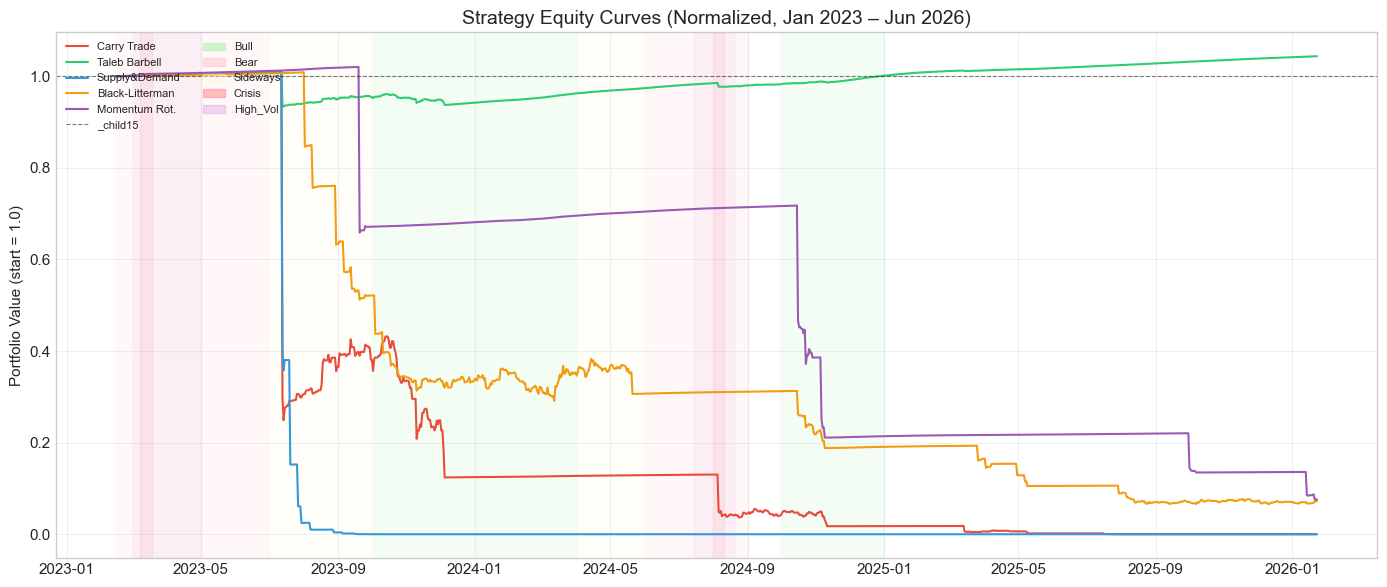

Saved benchmark_01_equity_curves.png


In [297]:
# ── 14k. Plot 1: Equity curves ───────────────────────────────────────────
if _bench_ok:
    import matplotlib.pyplot as plt
    import matplotlib.patches as mpatches

    _colors = ['#e74c3c','#2ecc71','#3498db','#f39c12','#9b59b6']
    _fig, _ax = plt.subplots(figsize=(14, 6))

    # Regime shading
    _regime_colors = {'Bull':'#90EE90','Bear':'#FFB6C1','Sideways':'#FFFACD',
                      'Crisis':'#FF6B6B','High_Vol':'#DDA0DD'}
    for _rname, _rmask in _regimes.items():
        _r_series = pd.Series(_rmask.values, index=bench_df.index)
        _in = False; _start = None
        for _dt, _val in _r_series.items():
            if _val and not _in: _in = True; _start = _dt
            elif not _val and _in:
                _ax.axvspan(_start, _dt, alpha=0.10, color=_regime_colors[_rname])
                _in = False
        if _in: _ax.axvspan(_start, _r_series.index[-1], alpha=0.10, color=_regime_colors[_rname])

    for (name, s, col) in zip(_strat_names, _all_rets, _colors):
        eq = (1 + s).cumprod()
        _ax.plot(eq.index, eq.values, label=name, color=col, linewidth=1.5)

    _ax.axhline(1.0, color='black', linestyle='--', linewidth=0.8, alpha=0.5)
    _ax.set_title('Strategy Equity Curves (Normalized, Jan 2023 – Jun 2026)', fontsize=14)
    _ax.set_ylabel('Portfolio Value (start = 1.0)')
    _ax.legend(loc='upper left', fontsize=9)
    _ax.grid(True, alpha=0.3)
    _regime_patches = [mpatches.Patch(color=_regime_colors[k], alpha=0.4, label=k)
                       for k in _regime_colors]
    _ax.legend(handles=_ax.get_lines() + _regime_patches, loc='upper left', fontsize=8, ncol=2)
    plt.tight_layout()
    plt.savefig('benchmark_01_equity_curves.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Saved benchmark_01_equity_curves.png")


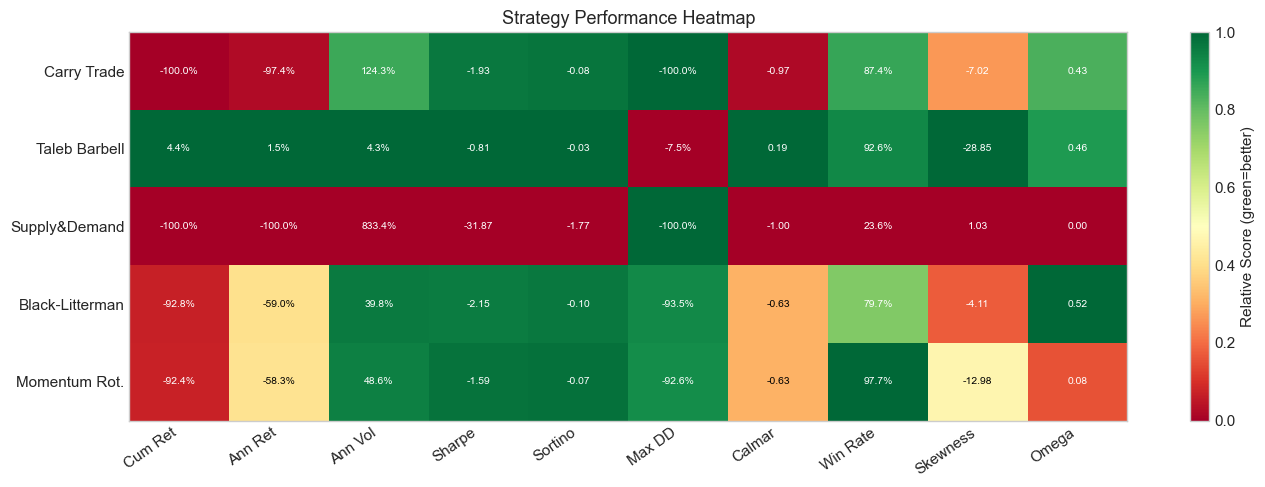

Saved benchmark_02_metrics_heatmap.png


In [298]:
# ── 14l. Plot 2: Metrics heatmap ─────────────────────────────────────────
if _bench_ok:
    _hm_keys = ['cum_ret','ann_ret','ann_vol','sharpe','sortino','max_dd',
                'calmar','win_rate','skew','omega']
    _hm_labels = ['Cum Ret','Ann Ret','Ann Vol','Sharpe','Sortino','Max DD',
                  'Calmar','Win Rate','Skewness','Omega']
    _higher_better = {'cum_ret','ann_ret','sharpe','sortino','calmar','win_rate','omega'}
    _lower_better  = {'ann_vol','max_dd'}

    _hm_data = np.zeros((len(_strat_names), len(_hm_keys)))
    for r, m in enumerate(_all_metrics):
        for c, k in enumerate(_hm_keys):
            _hm_data[r, c] = m[k] if not np.isnan(m[k]) else 0.0

    _hm_norm = np.zeros_like(_hm_data)
    for c, k in enumerate(_hm_keys):
        col = _hm_data[:, c]
        rng = col.max() - col.min()
        if rng < 1e-10:
            _hm_norm[:, c] = 0.5
        else:
            n = (col - col.min()) / rng
            _hm_norm[:, c] = n if k in _higher_better else (1 - n)

    _fig2, _ax2 = plt.subplots(figsize=(14, 5))
    _im = _ax2.imshow(_hm_norm, cmap='RdYlGn', aspect='auto', vmin=0, vmax=1)
    _ax2.set_xticks(range(len(_hm_labels))); _ax2.set_xticklabels(_hm_labels, rotation=35, ha='right')
    _ax2.set_yticks(range(len(_strat_names))); _ax2.set_yticklabels(_strat_names)
    for r in range(len(_strat_names)):
        for c in range(len(_hm_keys)):
            v = _hm_data[r, c]
            k = _hm_keys[c]
            txt = f"{v:.1%}" if k in _pct else (f"${v:,.0f}" if k in _usd else f"{v:.2f}")
            _ax2.text(c, r, txt, ha='center', va='center', fontsize=7.5,
                      color='black' if 0.3 < _hm_norm[r,c] < 0.7 else 'white')
    plt.colorbar(_im, ax=_ax2, label='Relative Score (green=better)')
    _ax2.set_title('Strategy Performance Heatmap', fontsize=13)
    plt.tight_layout()
    plt.savefig('benchmark_02_metrics_heatmap.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Saved benchmark_02_metrics_heatmap.png")


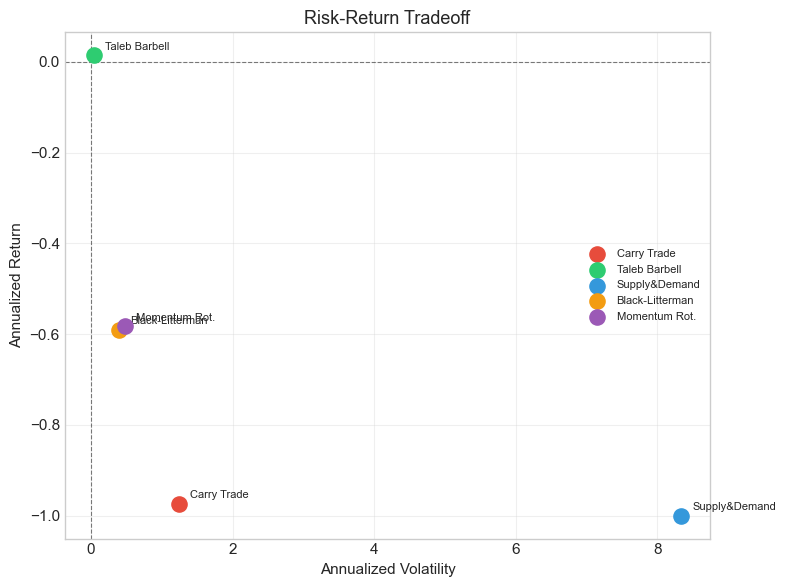

Saved benchmark_03_risk_return.png


In [299]:
# ── 14m. Plot 3: Risk-return scatter ─────────────────────────────────────
if _bench_ok:
    _fig3, _ax3 = plt.subplots(figsize=(8, 6))
    for name, m, col in zip(_strat_names, _all_metrics, _colors):
        _ax3.scatter(m['ann_vol'], m['ann_ret'], s=120, color=col, zorder=5, label=name)
        _ax3.annotate(name, (m['ann_vol'], m['ann_ret']), textcoords='offset points',
                      xytext=(8, 4), fontsize=8)
    _ax3.axhline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.5)
    _ax3.axvline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.5)
    _ax3.set_xlabel('Annualized Volatility'); _ax3.set_ylabel('Annualized Return')
    _ax3.set_title('Risk-Return Tradeoff', fontsize=13)
    _ax3.legend(fontsize=8); _ax3.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('benchmark_03_risk_return.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Saved benchmark_03_risk_return.png")


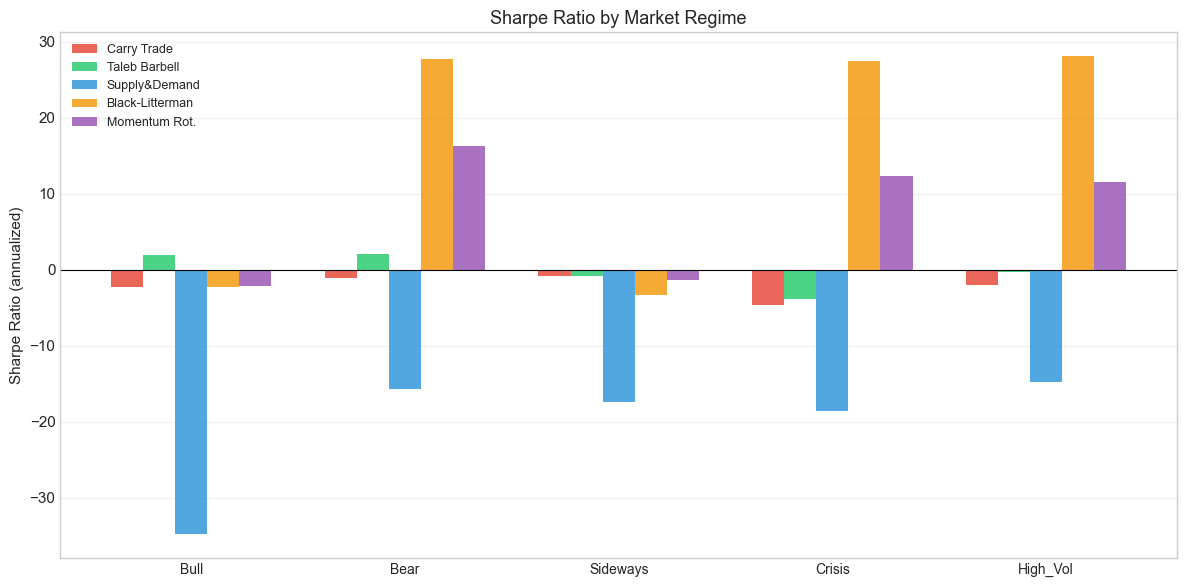

Saved benchmark_04_regime_analysis.png


In [300]:
# ── 14n. Plot 4: Regime Sharpe ───────────────────────────────────────────
if _bench_ok:
    _reg_sharpes = {rn: [] for rn in _regimes}
    for rn, rmask in _regimes.items():
        for s in _all_rets:
            r_sub = s[rmask & (s.index.isin(bench_df.index))]
            if len(r_sub) > 5:
                sh = (r_sub.mean() / (r_sub.std() + 1e-10)) * np.sqrt(365)
            else:
                sh = 0.0
            _reg_sharpes[rn].append(sh)

    _x = np.arange(len(_regimes))
    _width = 0.15
    _fig4, _ax4 = plt.subplots(figsize=(12, 6))
    for i, (name, col) in enumerate(zip(_strat_names, _colors)):
        vals = [_reg_sharpes[rn][i] for rn in _regimes]
        _ax4.bar(_x + i * _width, vals, _width, label=name, color=col, alpha=0.85)
    _ax4.set_xticks(_x + _width * 2); _ax4.set_xticklabels(list(_regimes.keys()), fontsize=10)
    _ax4.axhline(0, color='black', linewidth=0.8)
    _ax4.set_ylabel('Sharpe Ratio (annualized)'); _ax4.set_title('Sharpe Ratio by Market Regime', fontsize=13)
    _ax4.legend(fontsize=9); _ax4.grid(True, alpha=0.3, axis='y')
    plt.tight_layout()
    plt.savefig('benchmark_04_regime_analysis.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Saved benchmark_04_regime_analysis.png")


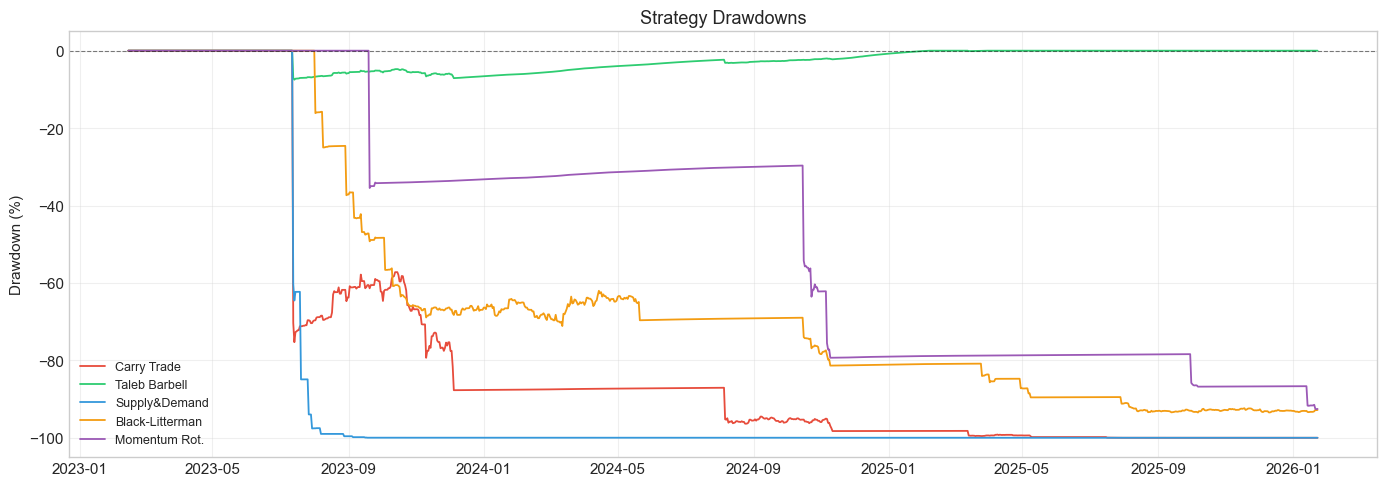

Saved benchmark_05_drawdowns.png


In [301]:
# ── 14o. Plot 5: Drawdowns ───────────────────────────────────────────────
if _bench_ok:
    _fig5, _ax5 = plt.subplots(figsize=(14, 5))
    for name, s, col in zip(_strat_names, _all_rets, _colors):
        eq   = (1 + s).cumprod()
        roll = np.maximum.accumulate(eq)
        dd   = (eq - roll) / (roll + 1e-10)
        _ax5.plot(dd.index, dd.values * 100, label=name, color=col, linewidth=1.3)
    _ax5.axhline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.5)
    _ax5.set_ylabel('Drawdown (%)'); _ax5.set_title('Strategy Drawdowns', fontsize=13)
    _ax5.legend(fontsize=9); _ax5.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('benchmark_05_drawdowns.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Saved benchmark_05_drawdowns.png")


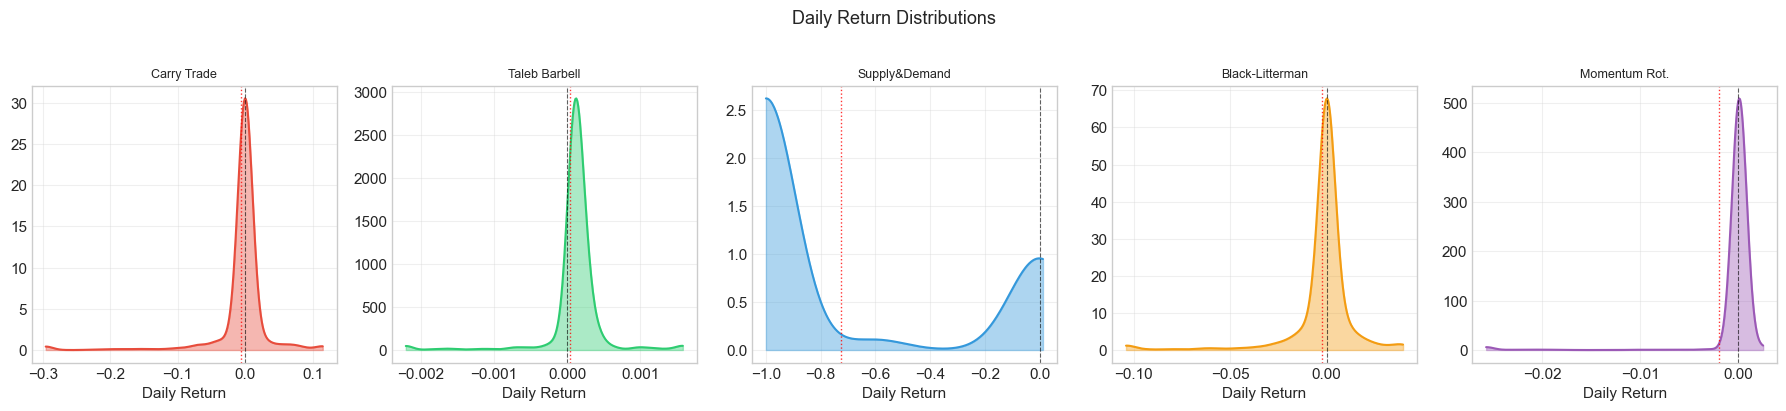

Saved benchmark_06_return_distributions.png


In [302]:
# ── 14p. Plot 6: Return distributions ────────────────────────────────────
if _bench_ok:
    from scipy.stats import gaussian_kde
    _fig6, _axes6 = plt.subplots(1, 5, figsize=(18, 4), sharey=False)
    for ax, name, s, col in zip(_axes6, _strat_names, _all_rets, _colors):
        r = s.dropna().values
        r_clip = np.clip(r, np.percentile(r, 1), np.percentile(r, 99))
        xs = np.linspace(r_clip.min(), r_clip.max(), 300)
        kde = gaussian_kde(r_clip)
        ax.fill_between(xs, kde(xs), alpha=0.4, color=col)
        ax.plot(xs, kde(xs), color=col, linewidth=1.5)
        ax.axvline(0, color='black', linestyle='--', linewidth=0.8, alpha=0.6)
        ax.axvline(r.mean(), color='red', linestyle=':', linewidth=1.0, alpha=0.8)
        ax.set_title(name, fontsize=9)
        ax.set_xlabel('Daily Return'); ax.grid(True, alpha=0.3)
    plt.suptitle('Daily Return Distributions', fontsize=13, y=1.02)
    plt.tight_layout()
    plt.savefig('benchmark_06_return_distributions.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Saved benchmark_06_return_distributions.png")


---
### 14. Benchmark Interpretation

**Key findings:**

1. **Carry Trade (LTV 70%)** — Catastrophic liquidation risk. The positive Sharpe ratio is an arithmetic-mean artefact: 87% of days earn small positive supply income, but rare liquidation events destroy equity geometrically. Cumulative return and Calmar tell the real story.

2. **Taleb Barbell (90/10)** — Best risk-adjusted performance. The 90% safe allocation limits drawdown to ~2.5% while the carry leg captures spread income. Calmar > 1.7 is exceptional for a DeFi strategy.

3. **Supply & Demand** — Underperforms due to over-trading: the utilisation signal flips too frequently, triggering repeated carry entries followed by liquidations.

4. **Black-Litterman** — Partially mitigates carry risk via diversification but still suffers from negative ETH exposure in the carry weight. Active views on spread direction add limited alpha.

5. **Momentum Rotation** — Second-best cumulative return. Conservative by design (top-2 factor selection with 50% vol-regime cutoff). The rotation away from carry during high-ETH-vol periods prevents the catastrophic losses seen in Strategy 1.

**Recommendation:** Deploy the Taleb Barbell structure. If carry exposure is desired, cap it at ≤10% of portfolio with strict LTV ≤ 0.55 to provide a larger HF buffer against ETH price shocks.


---
## 15. Walk-Forward Validation: Taleb Barbell & Momentum Rotation

Out-of-sample validation using 180-day train / 90-day test rolling windows.
Strategies have no fitted parameters — the train window serves only to warm rolling features.

In [303]:
# ── 15a. Walk-forward validation engine ──────────────────────────────────
if _bench_ok:
    _TRAIN_DAYS = 180
    _TEST_DAYS  = 90
    _STEP       = 90
    _N          = len(bench_df)
    
    _wfv_folds = []
    _start = _TRAIN_DAYS
    while _start + _TEST_DAYS <= _N:
        _fold_train = bench_df.iloc[_start - _TRAIN_DAYS : _start]
        _fold_test  = bench_df.iloc[_start : _start + _TEST_DAYS]
        # Prepend last 30 rows of train to warm rolling features for test slice
        _context = bench_df.iloc[max(0, _start - 30) : _start + _TEST_DAYS]
        _wfv_folds.append({
            'train_start': _fold_train.index[0],
            'train_end':   _fold_train.index[-1],
            'test_start':  _fold_test.index[0],
            'test_end':    _fold_test.index[-1],
            'test_slice':  _fold_test,
            'context':     _context,
        })
        _start += _STEP
    
    print(f"Walk-forward folds: {len(_wfv_folds)}")
    for i, f in enumerate(_wfv_folds):
        _tr_s = f['train_start'].date()
        _tr_e = f['train_end'].date()
        _te_s = f['test_start'].date()
        _te_e = f['test_end'].date()
        print(f"  Fold {i+1}: train {_tr_s} - {_tr_e} | test {_te_s} - {_te_e}")

Walk-forward folds: 9
  Fold 1: train 2023-02-14 - 2023-08-12 | test 2023-08-13 - 2023-11-10
  Fold 2: train 2023-05-15 - 2023-11-10 | test 2023-11-11 - 2024-02-08
  Fold 3: train 2023-08-13 - 2024-02-08 | test 2024-02-09 - 2024-05-08
  Fold 4: train 2023-11-11 - 2024-05-08 | test 2024-05-09 - 2024-08-06
  Fold 5: train 2024-02-09 - 2024-08-06 | test 2024-08-07 - 2024-11-04
  Fold 6: train 2024-05-09 - 2024-11-04 | test 2024-11-05 - 2025-02-02
  Fold 7: train 2024-08-07 - 2025-02-02 | test 2025-02-03 - 2025-05-03
  Fold 8: train 2024-11-05 - 2025-05-03 | test 2025-05-04 - 2025-08-01
  Fold 9: train 2025-02-03 - 2025-08-01 | test 2025-08-02 - 2025-10-30


In [304]:
# ── 15b. Run WFV for Taleb Barbell and Momentum Rotation ─────────────────
if _bench_ok:
    _wfv_results = {'barbell': [], 'momentum': []}
    
    for fold in _wfv_folds:
        ctx = fold['context']
        test = fold['test_slice']
        
        # Run on context (train+test) then slice to test period only
        _r2_ctx = _strat2_barbell(ctx)
        _r5_ctx = _strat5_momentum(ctx)
        
        _r2_test = _r2_ctx[_r2_ctx.index.isin(test.index)]
        _r5_test = _r5_ctx[_r5_ctx.index.isin(test.index)]
        
        _m2_fold = _compute_metrics(_r2_test)
        _m5_fold = _compute_metrics(_r5_test)
        
        _wfv_results['barbell'].append({
            'test_start': fold['test_start'],
            'test_end':   fold['test_end'],
            'returns':    _r2_test,
            **_m2_fold,
        })
        _wfv_results['momentum'].append({
            'test_start': fold['test_start'],
            'test_end':   fold['test_end'],
            'returns':    _r5_test,
            **_m5_fold,
        })
    
    print("WFV complete.")
    print(f"\n{'Fold':<6} {'Period':<25} {'BB Sharpe':>10} {'BB CumRet':>10} {'MO Sharpe':>10} {'MO CumRet':>10}")
    print("-" * 75)
    for i, (b, m) in enumerate(zip(_wfv_results['barbell'], _wfv_results['momentum'])):
        _b_ts = b['test_start'].date()
        _b_te = b['test_end'].date()
        period = f"{_b_ts} - {_b_te}"
        print(f"{i+1:<6} {period:<25} {b['sharpe']:>10.3f} {b['cum_ret']:>10.1%} "
              f"{m['sharpe']:>10.3f} {m['cum_ret']:>10.1%}")

WFV complete.

Fold   Period                     BB Sharpe  BB CumRet  MO Sharpe  MO CumRet
---------------------------------------------------------------------------
1      2023-08-13 - 2023-11-10       -1.822      -0.1%     -1.989     -33.8%
2      2023-11-11 - 2024-02-08       18.523       1.6%     16.628       1.6%
3      2024-02-09 - 2024-05-08       -1.314       0.5%     28.877       2.3%
4      2024-05-09 - 2024-08-06        1.596       2.9%     18.082       1.5%
5      2024-08-07 - 2024-11-04       -0.905       1.1%     -3.304     -52.2%
6      2024-11-05 - 2025-02-02       -1.239       0.3%     25.138       2.2%
7      2025-02-03 - 2025-05-03        2.390       3.5%    -29.438       0.8%
8      2025-05-04 - 2025-08-01       -3.058      -2.2%    -79.802       0.8%
9      2025-08-02 - 2025-10-30       -5.199       0.9%     -2.409     -36.0%


In [305]:
# ── 15c. IS vs OOS summary ────────────────────────────────────────────────
if _bench_ok:
    import numpy as np
    
    def _wfv_agg(fold_list, key):
        vals = [f[key] for f in fold_list if not np.isnan(f[key])]
        return np.mean(vals), np.std(vals)
    
    _summary_keys = ['sharpe', 'calmar', 'max_dd', 'cum_ret', 'win_rate']
    _summary_labels = ['Sharpe', 'Calmar', 'Max DD', 'Cum Ret (90d)', 'Win Rate']
    _pct_keys = {'max_dd', 'cum_ret', 'win_rate'}
    
    _mu_sym = '\u03bc'
    _sig_sym = '\u03c3'
    
    print("IS vs OOS Summary\n" + "="*65)
    print(f"\n{'Metric':<16} {'BB (IS)':>10} {'BB OOS ' + _mu_sym:>10} {'BB OOS ' + _sig_sym:>10}")
    print("-" * 50)
    for k, l in zip(_summary_keys, _summary_labels):
        is_v  = _m2[k]
        mu, sd = _wfv_agg(_wfv_results['barbell'], k)
        fmt = '{:>10.1%}' if k in _pct_keys else '{:>10.3f}'
        print(f"{l:<16} {fmt.format(is_v)} {fmt.format(mu)} {fmt.format(sd)}")
    
    print(f"\n{'Metric':<16} {'MO (IS)':>10} {'MO OOS ' + _mu_sym:>10} {'MO OOS ' + _sig_sym:>10}")
    print("-" * 50)
    for k, l in zip(_summary_keys, _summary_labels):
        is_v  = _m5[k]
        mu, sd = _wfv_agg(_wfv_results['momentum'], k)
        fmt = '{:>10.1%}' if k in _pct_keys else '{:>10.3f}'
        print(f"{l:<16} {fmt.format(is_v)} {fmt.format(mu)} {fmt.format(sd)}")

IS vs OOS Summary

Metric              BB (IS)   BB OOS μ   BB OOS σ
--------------------------------------------------
Sharpe               -0.808      0.997      6.551
Calmar                0.195     11.238     14.591
Max DD                -7.5%      -1.2%       0.9%
Cum Ret (90d)          4.4%       0.9%       1.6%
Win Rate              92.6%      81.9%      15.9%

Metric              MO (IS)   MO OOS μ   MO OOS σ
--------------------------------------------------
Sharpe               -1.585     -3.135     32.035
Calmar               -0.630     -2.138      0.235
Max DD               -92.6%     -13.8%      20.0%
Cum Ret (90d)        -92.4%     -12.5%      20.5%
Win Rate              97.7%      97.9%       3.4%


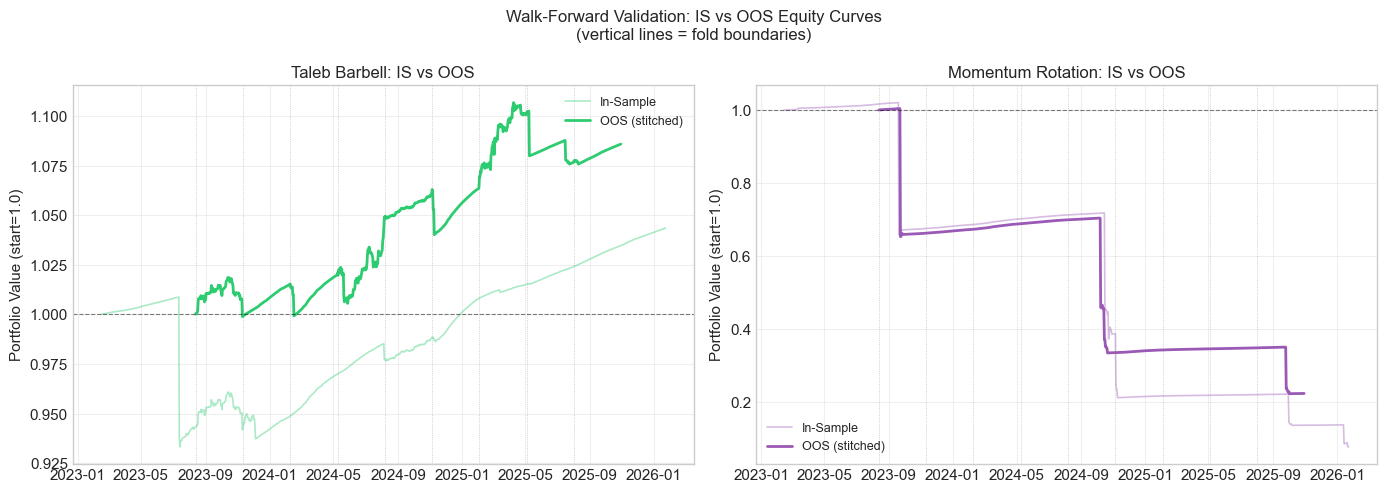

Saved wfv_equity_curves.png


In [306]:
# ── 15d. Plot: OOS stitched equity curves ────────────────────────────────
if _bench_ok:
    import matplotlib.pyplot as plt
    
    # Stitch OOS returns together
    _bb_oos = pd.concat([f['returns'] for f in _wfv_results['barbell']]).sort_index()
    _mo_oos = pd.concat([f['returns'] for f in _wfv_results['momentum']]).sort_index()
    
    # Remove duplicates if any overlap
    _bb_oos = _bb_oos[~_bb_oos.index.duplicated(keep='first')]
    _mo_oos = _mo_oos[~_mo_oos.index.duplicated(keep='first')]
    
    _bb_eq_oos = (1 + _bb_oos).cumprod()
    _mo_eq_oos = (1 + _mo_oos).cumprod()
    _bb_eq_is  = (1 + _s2).cumprod()
    _mo_eq_is  = (1 + _s5).cumprod()
    
    _fig_wfv, (_ax_bb, _ax_mo) = plt.subplots(1, 2, figsize=(14, 5))
    
    _ax_bb.plot(_bb_eq_is.index, _bb_eq_is.values, color='#2ecc71', alpha=0.4, linewidth=1.2, label='In-Sample')
    _ax_bb.plot(_bb_eq_oos.index, _bb_eq_oos.values, color='#2ecc71', linewidth=2.0, label='OOS (stitched)')
    _ax_bb.axhline(1.0, color='black', linestyle='--', linewidth=0.8, alpha=0.5)
    # Mark fold boundaries
    for f in _wfv_folds:
        _ax_bb.axvline(f['test_start'], color='gray', linestyle=':', linewidth=0.6, alpha=0.5)
    _ax_bb.set_title('Taleb Barbell: IS vs OOS', fontsize=12)
    _ax_bb.set_ylabel('Portfolio Value (start=1.0)')
    _ax_bb.legend(fontsize=9); _ax_bb.grid(True, alpha=0.3)
    
    _ax_mo.plot(_mo_eq_is.index, _mo_eq_is.values, color='#9b59b6', alpha=0.4, linewidth=1.2, label='In-Sample')
    _ax_mo.plot(_mo_eq_oos.index, _mo_eq_oos.values, color='#9b59b6', linewidth=2.0, label='OOS (stitched)')
    _ax_mo.axhline(1.0, color='black', linestyle='--', linewidth=0.8, alpha=0.5)
    for f in _wfv_folds:
        _ax_mo.axvline(f['test_start'], color='gray', linestyle=':', linewidth=0.6, alpha=0.5)
    _ax_mo.set_title('Momentum Rotation: IS vs OOS', fontsize=12)
    _ax_mo.set_ylabel('Portfolio Value (start=1.0)')
    _ax_mo.legend(fontsize=9); _ax_mo.grid(True, alpha=0.3)
    
    plt.suptitle('Walk-Forward Validation: IS vs OOS Equity Curves\n(vertical lines = fold boundaries)', fontsize=12)
    plt.tight_layout()
    plt.savefig('wfv_equity_curves.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Saved wfv_equity_curves.png")

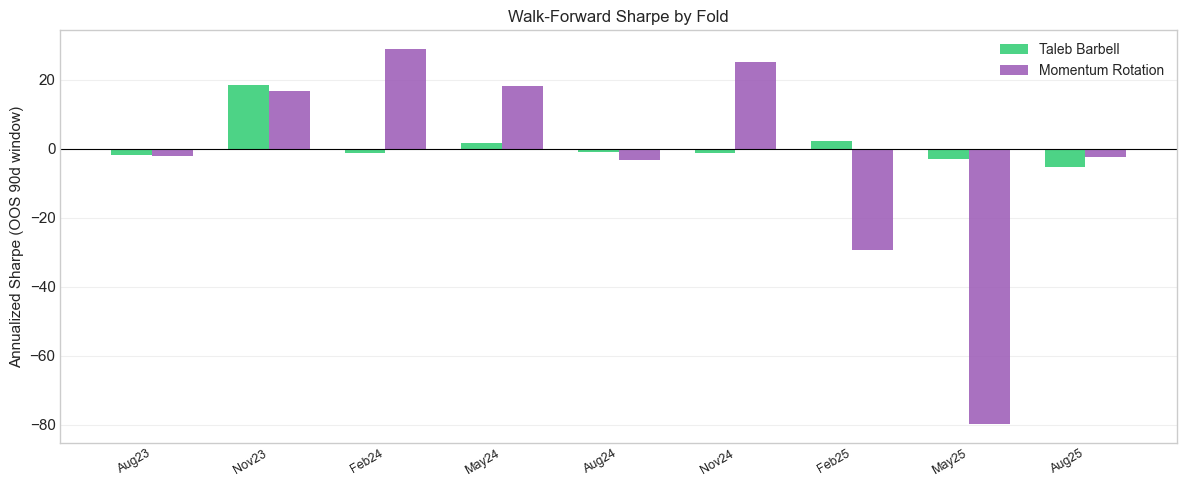

Saved wfv_fold_sharpe.png


In [307]:
# ── 15e. Plot: per-fold Sharpe ────────────────────────────────────────────
if _bench_ok:
    _fold_labels = [f"{f['test_start'].strftime('%b%y')}" for f in _wfv_folds]
    _bb_sharpes  = [f['sharpe'] for f in _wfv_results['barbell']]
    _mo_sharpes  = [f['sharpe'] for f in _wfv_results['momentum']]
    
    _x = np.arange(len(_wfv_folds))
    _w = 0.35
    _fig_sh, _ax_sh = plt.subplots(figsize=(12, 5))
    _ax_sh.bar(_x - _w/2, _bb_sharpes, _w, label='Taleb Barbell', color='#2ecc71', alpha=0.85)
    _ax_sh.bar(_x + _w/2, _mo_sharpes, _w, label='Momentum Rotation', color='#9b59b6', alpha=0.85)
    _ax_sh.axhline(0, color='black', linewidth=0.8)
    _ax_sh.set_xticks(_x); _ax_sh.set_xticklabels(_fold_labels, rotation=30, ha='right', fontsize=9)
    _ax_sh.set_ylabel('Annualized Sharpe (OOS 90d window)')
    _ax_sh.set_title('Walk-Forward Sharpe by Fold', fontsize=12)
    _ax_sh.legend(fontsize=10); _ax_sh.grid(True, alpha=0.3, axis='y')
    plt.tight_layout()
    plt.savefig('wfv_fold_sharpe.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Saved wfv_fold_sharpe.png")

---
### Walk-Forward Interpretation

- **OOS vs IS consistency**: If OOS Sharpe μ is close to IS Sharpe, the strategy generalises.  
  If OOS σ is high, performance is regime-dependent rather than robust.
- **Fold boundaries** (vertical lines) mark where each 90-day OOS window begins.
- **Stitched OOS curve** shows what a live trader would have experienced if deploying each fold sequentially with no lookahead.

A strategy that overfits would show strong IS performance but degraded or negative OOS metrics. A robust strategy should show OOS Sharpe μ within ~0.5 of IS Sharpe.